# Eigen Times History Math — OCaml teaching notebook

Alexy Khrabrov · Notebook edition 1.1.0 · Companion text 1.1.0

This notebook includes **the complete companion text**, its figures as embedded
attachments, and executable lessons after the corresponding explanations. Read
from top to bottom. Use **Restart Kernel and Run All** for a clean run; then edit
the small input arrays and rerun a lesson to explore what changes. Later cells
depend on earlier ones. Outputs saved here show a verified run, but rerunning is
the way to check your own edits.

Examples use synthetic or explicitly frozen numerical inputs. Dated catalog
counts, archive-wide measurements, model labels, and live-site journeys in the
original text are historical evidence, not claims that this notebook recreates
or refreshes the production archive. No credentials, remote API calls, paid news
access, or live network connection are needed to execute the lessons.

The companion's original diagrams remain embedded reference figures. Lesson
outputs recompute the arithmetic from editable inputs. Exercise suggestions
accompany the examples; assertions check mathematical identities and reference
results. When deliberately changing a fixture, examine and update its expected
results as part of the exercise.

The setup cell defines reusable numerical helpers. Their operations are
introduced in the relevant chapters; you may run it now and return to its code
later. The OCaml edition computes in OCaml and does not call Python. The Python
edition uses NumPy and, where needed, SciPy/Matplotlib.

For environment installation and verification commands, see the included
`README.txt`. Python needs the `math-companion-python` kernel from the teaching environment;
OCaml needs the `ocaml-jupyter` kernel (an installed differently named OCaml
kernel can be selected in Jupyter). Both notebooks retain the same full text.


Manuscript revision: `99aa176a`. Notebook source revision:
`99aa176a`. The manuscript and lesson SHA-256 hashes are in notebook metadata.

HTML reading copies use MathJax from a CDN for mathematical rendering; notebook computations run offline.


In [1]:
#print_length 100000;;
(* Small dense educational linear algebra. Arrays store rows; no Python bridge.
   Jacobi diagonalizes symmetric matrices; Gram SVD is for tiny teaching inputs,
   not a numerically preferred replacement for a production direct SVD. *)
type vector = float array;;
type matrix = float array array;;
let rows a = Array.length a;;
let cols a = if rows a = 0 then 0 else Array.length a.(0);;
let zeros n p = Array.make_matrix n p 0.;;
let eye n = Array.init n (fun i -> Array.init n (fun j -> if i=j then 1. else 0.));;
let dot x y = if Array.length x <> Array.length y then invalid_arg "dot shape"; Array.fold_left (+.) 0. (Array.mapi (fun i x -> x *. y.(i)) x);;
let norm x = sqrt (dot x x);;
let normalize x = let n=norm x in if n=0. then invalid_arg "zero direction" else Array.map (fun a -> a /. n) x;;
let transpose a = Array.init (cols a) (fun j -> Array.init (rows a) (fun i -> a.(i).(j)));;
let matvec a x = Array.map (fun row -> dot row x) a;;
let matmul a b = if cols a <> rows b then invalid_arg "matmul shape"; let bt=transpose b in Array.map (fun row -> Array.map (dot row) bt) a;;
let map2 f a b = Array.mapi (fun i row -> Array.mapi (fun j x -> f x b.(i).(j)) row) a;;
let add a b = map2 (+.) a b;;
let sub a b = map2 (-.) a b;;
let scale s a = Array.map (Array.map (( *.) s)) a;;
let outer a b = Array.map (fun x -> Array.map (fun y -> x*.y) b) a;;
let frob a = sqrt (Array.fold_left (fun s row -> s +. dot row row) 0. a);;
let col a j = Array.map (fun row -> row.(j)) a;;
let take_cols a k = Array.map (fun row -> Array.sub row 0 k) a;;
let mean_rows a = Array.map (fun column -> Array.fold_left (+.) 0. column /. float_of_int (rows a)) (transpose a);;
let center a mu = Array.map (fun row -> Array.mapi (fun j x -> x -. mu.(j)) row) a;;
let diag values = Array.mapi (fun i x -> Array.init (Array.length values) (fun j -> if i=j then x else 0.)) values;;
let close ?(tol=1e-9) x y = abs_float (x-.y) <= tol *. (1. +. max (abs_float x) (abs_float y));;
let assert_close ?(tol=1e-9) x y = if not (close ~tol x y) then failwith (Printf.sprintf "Expected %.12g; got %.12g" y x);;
let assert_matrix ?(tol=1e-9) a b = assert (rows a=rows b && cols a=cols b); if frob (sub a b) > tol *. (1. +. frob b) then failwith "matrix mismatch";;
let cosine a b = dot a b /. (norm a *. norm b);;
let print_vector label v = Printf.sprintf "%s: [%s]" label (String.concat "; " (Array.to_list (Array.map (Printf.sprintf "%.6g") v)));;
let print_matrix label a = Printf.sprintf "%s (%d x %d)\n%s" label (rows a) (cols a) (String.concat "\n" (Array.to_list(Array.map(print_vector " ")a)));;
let eig_sym input =
  let n=rows input in assert(n=cols input);
  let a=Array.map Array.copy input and v=eye n in
  let iteration=ref 0 and running=ref true in
  while !running && !iteration < 100*n*n do
    incr iteration;
    let p=ref 0 and q=ref 0 and largest=ref 0. in
    for i=0 to n-1 do for j=i+1 to n-1 do
      if abs_float a.(i).(j) > !largest then (largest:=abs_float a.(i).(j);p:=i;q:=j)
    done done;
    if !largest = 0. || !largest < 1e-13 *. frob a then running:=false else (
      let p= !p and q= !q in
      let apq=a.(p).(q) and app=a.(p).(p) and aqq=a.(q).(q) in
      let tau=(aqq-.app)/.(2.*.apq) in
      let t=(if tau>=0. then 1. else -1.)/.(abs_float tau +. sqrt(1.+.tau*.tau)) in
      let c=1./.sqrt(1.+.t*.t) in let s=t*.c in
      for i=0 to n-1 do if i<>p && i<>q then (
        let aip=a.(i).(p) and aiq=a.(i).(q) in
        a.(i).(p)<-c*.aip-.s*.aiq; a.(p).(i)<-a.(i).(p);
        a.(i).(q)<-s*.aip+.c*.aiq; a.(q).(i)<-a.(i).(q))
      done;
      a.(p).(p)<-app-.t*.apq; a.(q).(q)<-aqq+.t*.apq;
      a.(p).(q)<-0.;a.(q).(p)<-0.;
      for i=0 to n-1 do let vip=v.(i).(p) and viq=v.(i).(q) in
        v.(i).(p)<-c*.vip-.s*.viq;v.(i).(q)<-s*.vip+.c*.viq done)
  done;
  if !running then failwith "Jacobi iteration limit";
  let order=Array.init n Fun.id in Array.sort (fun i j -> compare a.(j).(j) a.(i).(i)) order;
  let values=Array.map (fun j -> a.(j).(j)) order in
  let vectors=Array.init n (fun i -> Array.map (fun j -> v.(i).(j)) order) in
  for j=0 to n-1 do
    let pivot=ref 0 in for i=1 to n-1 do if abs_float vectors.(i).(j)>abs_float vectors.(!pivot).(j) then pivot:=i done;
    if vectors.(!pivot).(j)<0. then for i=0 to n-1 do vectors.(i).(j)<- -.vectors.(i).(j) done
  done;
  values,vectors;;
let thin_svd x =
  let values,vfull=eig_sym (matmul (transpose x) x) in
  let r=min (rows x) (cols x) in
  (* Gram diagonalization cannot resolve squared scales below roundoff.
     This tolerance is relative to input scale, not an absolute singular cutoff. *)
  let cutoff=64.*.epsilon_float*.(if Array.length values=0 then 0. else max 0. values.(0)) in
  let s=Array.init r (fun i -> if values.(i)>cutoff then sqrt values.(i) else 0.) in
  let v=take_cols vfull r in let xv=matmul x v in
  let u=zeros (rows x) r in
  let orthogonalize candidate j =
    let a=Array.copy candidate in
    for _=1 to 2 do for k=0 to j-1 do
      let q=col u k in let projection=dot a q in
      Array.iteri(fun i qi->a.(i)<-a.(i)-.projection*.qi)q
    done done; a in
  for j=0 to r-1 do
    let candidate=if s.(j)>0. then Array.map(fun z->z/.s.(j))(col xv j) else (
      let chosen=ref None and i=ref 0 in
      while !chosen=None && !i<rows x do
        let e=Array.init(rows x)(fun k->if k= !i then 1. else 0.) in
        let a=orthogonalize e j in if norm a>1e-10 then chosen:=Some a;incr i
      done;
      match !chosen with Some a->a | None->failwith "orthonormal completion failed") in
    let q=normalize(orthogonalize candidate j) in
    Array.iteri(fun i value->u.(i).(j)<-value)q
  done; u,s,v;;
let reconstruct_svd u s v k = matmul (matmul (take_cols u k) (diag (Array.sub s 0 k))) (transpose (take_cols v k));;
let solve a b =
  let n=rows a in assert(n=cols a && Array.length b=n);
  let m=Array.init n (fun i -> Array.append a.(i) [|b.(i)|]) in
  for j=0 to n-1 do
    let pivot=ref j in for i=j+1 to n-1 do if abs_float m.(i).(j)>abs_float m.(!pivot).(j) then pivot:=i done;
    if abs_float m.(!pivot).(j)<1e-13 then invalid_arg "singular solve";
    let tmp=m.(j) in m.(j)<-m.(!pivot);m.(!pivot)<-tmp;
    let d=m.(j).(j) in for k=j to n do m.(j).(k)<-m.(j).(k)/.d done;
    for i=0 to n-1 do if i<>j then (let c=m.(i).(j) in for k=j to n do m.(i).(k)<-m.(i).(k)-.c*.m.(j).(k) done) done
  done; Array.init n (fun i -> m.(i).(n));;
let inverse a = transpose (Array.map (solve a) (eye (rows a)));;
let qr x =
  let basis=ref [] in
  Array.iter (fun input -> let v=Array.copy input in
    List.iter (fun q -> let projection=dot v q in Array.iteri(fun i qi -> v.(i)<-v.(i)-.projection*.qi) q) !basis;
    (* Reorthogonalize to reduce cancellation in the teaching power iteration. *)
    List.iter (fun q -> let projection=dot v q in Array.iteri(fun i qi -> v.(i)<-v.(i)-.projection*.qi) q) !basis;
    if norm v > 1e-10 then basis:= !basis @ [normalize v]) (transpose x);
  if !basis=[] then zeros (rows x) 0 else transpose (Array.of_list !basis);;
let procrustes a b = let u,_,v=thin_svd (matmul (transpose a) b) in matmul u (transpose v);;
let covariance x weights =
  let z=Array.fold_left (+.) 0. weights in assert(z>0. && rows x=Array.length weights && Array.for_all(fun w->w>=0.)weights);
  let mu=Array.init (cols x) (fun j -> dot (col x j) weights /. z) in
  let xc=center x mu in
  let weighted=Array.mapi (fun i row -> Array.map (fun value -> value*.weights.(i)) row) xc in
  mu,scale (1./.z) (matmul (transpose xc) weighted);;
let results : (string,float) Hashtbl.t = Hashtbl.create 60;;
let record_result key value = Hashtbl.replace results key value;Printf.sprintf "%s = %.12g" key value;;
let result_json () =
  let items=Hashtbl.fold (fun key value acc -> (key,value)::acc) results [] |> List.sort compare in
  "{" ^ String.concat "," (List.map (fun (key,value)->Printf.sprintf "%S:%.15g" key value) items) ^ "}";;

type vector = float array


type matrix = float array array


val rows : 'a array -> int = <fun>


val cols : 'a array array -> int = <fun>


val zeros : int -> int -> float array array = <fun>


...

val procrustes : float array array -> float array array -> float array array =
  <fun>


val covariance :
  float array array -> float array -> float array * float array array = <fun>


val results : (string, float) Hashtbl.t = <abstr>


val record_result : string -> float -> string = <fun>


val result_json : unit -> string = <fun>


<a id="reading-guide"></a>

# How to use this companion

*Eigen Times History Math* teaches techniques that the earlier *Mathematics of
Eigen Times* and *Mathematics of Anthropology* do not yet develop as complete
executable lessons. Its parent, *Eigen Times Math History*, explains the
historical arc and original publications. Here the emphasis is on learning how
to perform a calculation, understanding why it works, and discovering when its
answer should not be trusted.

The five editions share one text: PDF, EPUB, HTML, a Python notebook, and a native
OCaml notebook. The notebooks contain the explanations, definitions, examples,
exercises, glossary, references, and index. Code cells follow the relevant
explanations. Each numerical example starts from declared inputs and is
computed in both languages. Saved outputs are a record of a checked run; changing
an input and running the cells again is how to investigate a new question.

This is a complement to the other two companions. A covariance calculation is
not repeated merely because it occurs in another historical chapter. Conversely,
calling a library routine is not the same as explaining the algorithm inside
it. For example, the earlier OCaml setup already diagonalizes matrices and
orthogonalizes columns. The new lessons expose the rotations, projections,
reflections, and conditioning questions that a learner could otherwise miss.

<a id="learning-route"></a>

## A route through the three companions

Begin with the [Eigen Times Math reader](https://firstpair.org/read/eigentimes-math/)
if vectors, matrix multiplication, covariance, or singular values are unfamiliar.
Principal component analysis (PCA) finds orthogonal directions of variation in
centered observations; its construction is taught there.
Use the [Anthropology Math reader](https://firstpair.org/read/anthropology-math/)
for person profiles, people directions, reciprocal navigation, and proposed
ontology predictors. The [prerequisite catalog](#prerequisite-catalog) names
exact lessons and the Python and OCaml cells that compute them. The delivered
study bundle includes unchanged copies and reading versions of those four
notebooks from their frozen 1.0.0 baselines, preserving the exact lesson and cell
references used by this prerequisite catalog. This companion is the expanded
1.1.0 edition; separately delivered expanded companions provide their current
teaching. The baseline citations are not silently repinned to changed cells.
The [public study repository](https://github.com/querygraph/eigenmath) provides
a study landing page; the local bundle does not require access to a private
repository.

The new companion has two connected routes. The numerical route moves from
fitting observations to reliable matrix calculations, graphs, and retrieval.
The information and learning route moves from uncertainty and forecast quality
to formal concepts, derivatives, predictive embeddings, attention, and
calibration. Read each route in order on a first pass. Later, the subject index
can take you directly to a method.

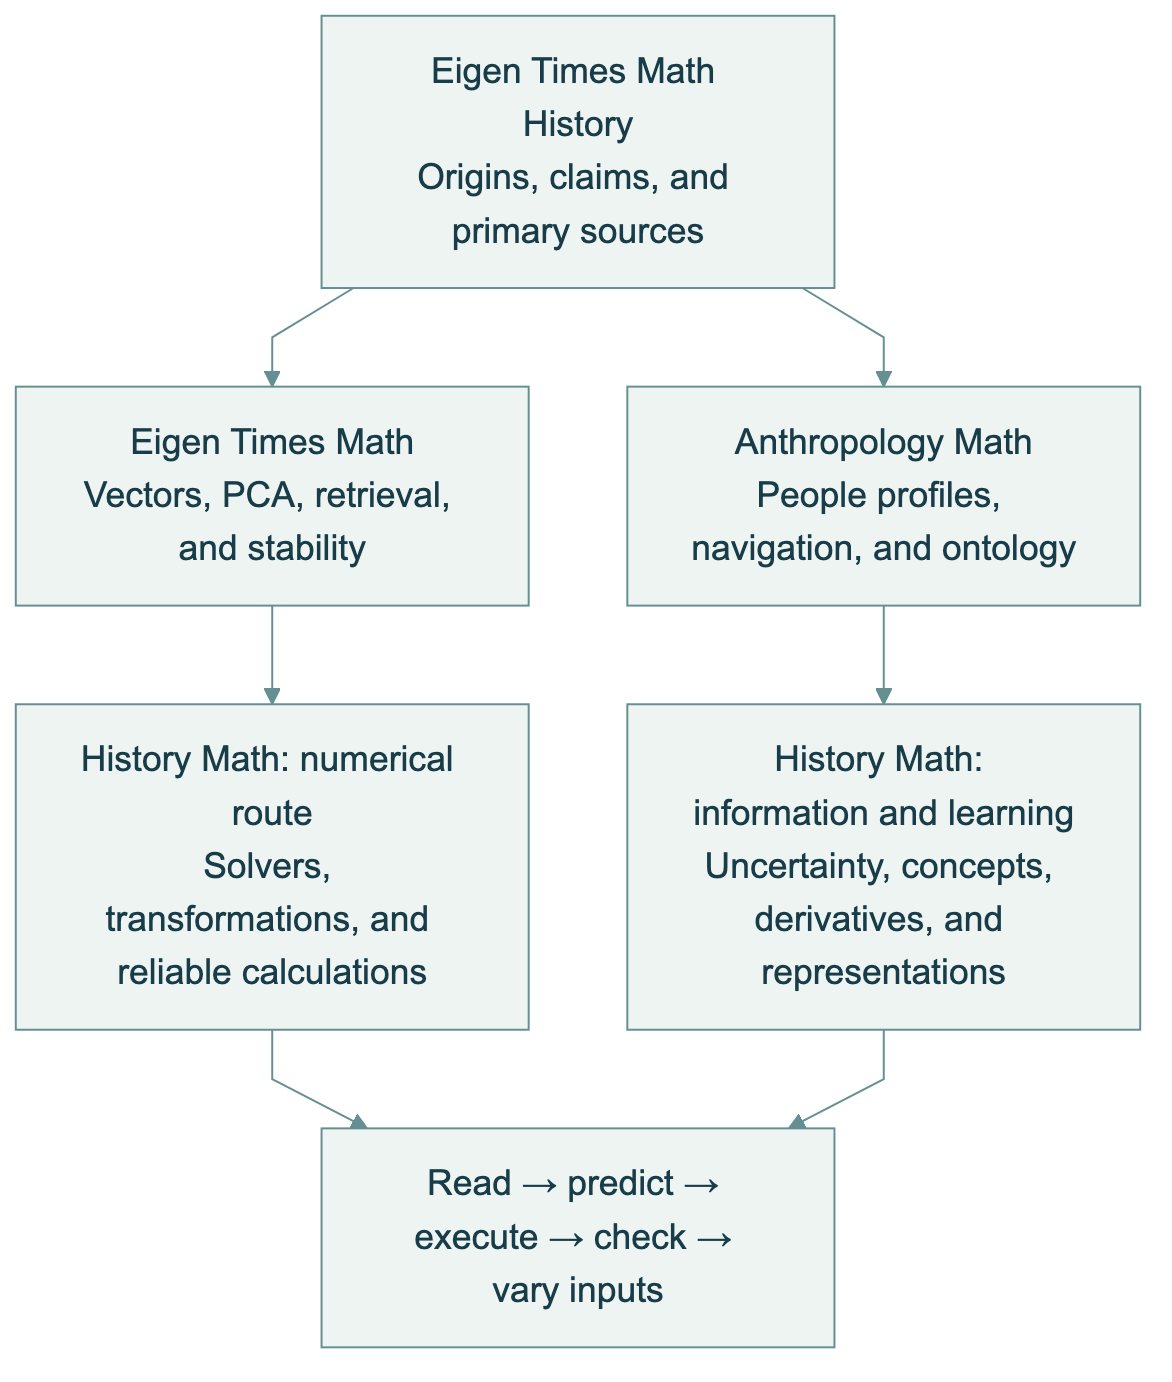

*The three companions form connected study routes. The history paper supplies the literature and chronology; each companion supplies calculations.*

A useful teaching rhythm is to read the definitions, predict the output, run the
cell, inspect the invariant being tested, and change one input. An **invariant**
is a property that the stated operation should preserve, such as an orthogonal
transformation preserving squared length. A reference assertion about a fixed
toy answer may need changing after a deliberate edit; an invariant should still
hold whenever its assumptions hold. Cross-language agreement is an additional
check, not a replacement for such mathematical reasoning.

<a id="teaching-contract"></a>

## What a teaching computation establishes

All new arrays and graphs in this book are synthetic. They are small enough to
inspect and require no credentials, newspaper archive, model download, or live
service. A two-layer derivative exercise does not train BERT. A scaled-attention
calculation does not reproduce the BGE embedding model. A limited triple-rule
closure is not an implementation of an OWL reasoner. Quantizing a handful of
numbers illustrates rounding and error; it does not reproduce a production
model's complete quantization procedure.

These distinctions matter because the three sites combine mathematics with
choices about data, identities, timestamps, and evidence. A cosine or learned
representation can suggest related coverage. It cannot establish an employment
relationship, an investment, or the reliability of a source. Likewise, a score
between zero and one is not automatically a calibrated probability. The new
lessons explain the computations while keeping those evidential boundaries.

Numerical examples are computed with ordinary finite-precision arithmetic.
**Rounding error** is the discrepancy introduced when a mathematical number or
operation cannot be represented exactly by the machine. **Approximation error**
is the loss intentionally accepted by a model or truncation. A stable algorithm
can reduce the first while leaving the second unchanged. Neither is the same
as an incorrect identity match or an unsupported factual claim.

The notebooks execute without network access after their runtimes and packages
are installed. Optional reading links and the browser's mathematics renderer
may need a connection. Use a fresh kernel and run all cells from the beginning;
later lessons can reuse helpers defined earlier. The setup code is a toolbox,
not a prerequisite vocabulary test: its operations are introduced in the
corresponding lessons. Python uses NumPy where a library operation helps make a
comparison; OCaml performs the calculations natively.

<a id="notation"></a>

# Notation and prerequisites before calculation

An **observation** is one measured item. A **scalar** is one number. A **vector**
is an ordered list of numbers, and a **matrix** is a rectangular table of them.
Observation vectors are rows in this companion; projection directions are
columns. A matrix with $u$ rows and $v$ columns has shape $u\times v$, where
$u$ and $v$ here are positive integer dimensions. Multiplying a $u\times v$
matrix by a $v\times k$ matrix gives a $u\times k$ matrix, with $k$ another
positive dimension. Each product entry is a sum of coordinatewise products.

The symbol $\mathbb R$ denotes the real numbers. Superscript $\mathsf T$ means
transpose, which exchanges rows and columns. For a vector $x$, its Euclidean
norm $\lVert x\rVert$ is the square root of the sum of squared coordinates.
For a matrix $M$, the Frobenius norm $\lVert M\rVert_F$ is the square root of
the sum of squared entries. Its operator norm $\lVert M\rVert_2$ is the largest
length of $Mx$ over column vectors $x$ of length one. The identity matrix
$I_k$ leaves every $k$-coordinate column unchanged; $\mathbf1_n$ is a column
of $n$ ones. The symbol $\operatorname{diag}$ forms a diagonal matrix from the
listed numbers, and $\operatorname{tr}$ sums a square matrix's diagonal entries.

A **linear combination** multiplies vectors by scalars and adds the results. A
**span** is the set of all such combinations. A list is **linearly independent**
when none of its vectors is a combination of the others. A **basis** is an
independent list spanning a space. Its number of members is the space's
**dimension**. A matrix's **rank** is the dimension of its column span, equal
to the dimension of its row span. A **nullspace** consists of inputs the matrix
maps to zero. These ideas explain both uniqueness and ambiguity in fitting.

The **dot product** of two equally sized vectors is the sum of their
coordinatewise products. Two vectors are **orthogonal** when their dot product is zero. A set is
**orthonormal** when its members are orthogonal and have length one. An
**orthogonal matrix** is a square matrix whose transpose is its inverse. An
**eigenvector** of a square matrix is a nonzero column whose image is a scalar
multiple of that column; the multiplier is its **eigenvalue**. The earlier
Eigen Times companion calculates these objects; the new lessons explain more
of the numerical machinery for constructing them.

The natural logarithm is written $\ln$ or $\log$; $\log_2$ has base two.
The exponential function is $\exp$, with $e=\exp(1)$. A sum sign $\sum$ adds
terms over its stated index. A hat denotes an estimate or reconstruction, and
a bar denotes a mean. The notation $\arg\min$ asks which argument makes an
objective smallest. A **derivative** measures local change of a function with
respect to one input; the neural lesson develops its use from an explicit
calculation. A **gradient** is the vector of derivatives with respect to several
inputs. Local auxiliary symbols are defined before the formula using them.

<a id="reading-calculations"></a>

### Reading a calculation without skipping its operations

A subscript names an entry rather than multiplying: $e_a$ is entry $a$ of a
residual column $e$. If the column has $n$ entries, the notation
$\sum_{a=1}^n e_a^2$ instructs us to square each entry and add all $n$ results.
The squared Euclidean length is this sum; the length itself requires one more
operation, the square root:

$$\lVert e\rVert^2=e^{\mathsf T}e=\sum_{a=1}^n e_a^2,
\qquad \lVert e\rVert=\sqrt{\sum_{a=1}^n e_a^2}.$$

A residual can have negative entries even though its length cannot be negative.
The sign records whether an individual prediction is above or below an
observation; squaring removes that sign when measuring total error. Squared
length and length have different units. If residual entries are measured in a
unit of response, length has that unit and squared length has its square.
Dividing squared length by $n$ instead gives mean squared error. Taking its
square root gives root mean squared error. These quantities answer related
questions but must not be exchanged under the single word “error.”

Products are read from their shapes. If $E$ has $n$ observation rows and $k$
predictor columns and $\vartheta$ is a $k\times1$ coefficient column, then
$E\vartheta$ is an $n\times1$ prediction column. Its $a$th entry is
$\sum_{j=1}^k E_{aj}\vartheta_j$, where $j$ temporarily indexes predictors.
The transpose $E^{\mathsf T}$ is $k\times n$, so $E^{\mathsf T}e$ contains
one dot product with each predictor column. Reading those entries explicitly
will explain the least-squares equations, rather than asking us to memorize a
matrix formula.

An equality sign says two expressions have the same value. The sign $\approx$
marks an approximation, often a rounded display. An inequality such as $x\geq0$
includes equality. Brackets $[a,b]$ describe an interval including its endpoints;
set braces describe a collection of elements. Set inclusion $E\subseteq F$
means every element of $E$ belongs to $F$. A prime in the formal-concept lesson
is a named set operation, while a prime on a scalar function in the fitting
lesson means a derivative; each lesson states its local use.

When we differentiate a scalar function, we ask how much its output changes
per small change of input. For a function $f$ of a scalar $t$, its derivative
$f'(t)$ is the limit of $[f(t+\epsilon)-f(t)]/\epsilon$ as the nonzero
displacement $\epsilon$ approaches zero, when that limit exists. The symbol
$\partial$ denotes a partial derivative: change one input while holding the
others fixed. The fitting lesson develops this idea first for a square, and the
network lesson builds a chain of such local changes.

<a id="notation-series"></a>

## The shared series convention

The following symbols retain the meanings used by the history paper. New local
algorithms declare their own temporary arrays explicitly. A locally subscripted
neural quantity must not silently become a news or people matrix.

| Symbol | Meaning in the series |
|---|---|
| $n,a$ | Observation count and observation index. |
| $d,i$ | Input-feature count and feature index. |
| $v,h$ | Vocabulary size and term index in text calculations. |
| $X,\mu,X_c$ | Article/input rows, reference mean row, centered rows. |
| $\Gamma$ | Covariance matrix, never the singular-value matrix. |
| $V,\lambda_j,K$ | News-direction columns, their eigenvalues, retained direction count. |
| $T,R,Y$ | Raw news scores, naming rotation, rotated scores. |
| $D,Z$ | Positive marginal scale matrix and standardized news coordinates. |
| $M,U,\Sigma,V_M$ | A locally declared matrix and its singular-value factors. |
| $r$ | Rank or retained rank, stated locally. |
| $E,y,\vartheta$ | Design matrix, response column, fitted coefficient column in least squares. |
| $\rho$ | Nonnegative regularization penalty; distinct from eigenvalues. |
| $m,p,J$ | People count, person index, and person-article incidence in prerequisite lessons. |
| $B,W,S$ | Person profiles, people-direction loadings, people scores in prerequisites. |
| $Q,T^2$ | Residual-energy and score-distance statistics in the earlier companions. |
| $\pi$ | A probability, with its event or outcome declared locally. |

A formula copied from a source using column observations may require a transpose
before it can be compared with this book. The notation is a teaching convention,
not a claim that every cited paper or production source file used these letters.

<a id="numerical-workshop"></a>

# Making the numerical steps visible

The earlier companions already calculate covariance, principal components, singular-value decompositions, and people profiles. The lessons here open the operations between those results. They use small disclosed inputs so that an answer can be checked by a second identity, not merely accepted because a library printed it. Observations remain rows. A coefficient vector or a column extracted while factoring a matrix is explicitly a column; that does not change the observation convention.

<a id="early-least-squares"></a>

## Fit an error before trusting a coefficient

Least squares starts with a choice about error. [Adrien-Marie Legendre](https://en.wikipedia.org/wiki/Adrien-Marie_Legendre)'s 1805 formulation supplies the historical reference; the small examples below are modern teaching fixtures, not reconstructions of his astronomical observations. [Legendre 1805](#ref-legendre1805)

Let the three observed responses be $y_1=1$, $y_2=2$, and $y_3=3$. Let $a$ index these observations, let $\vartheta$ be one fitted scalar, and let $\mathcal J(\vartheta)$ denote the sum of squared discrepancies. A completed-square form writes a quadratic as a nonnegative squared term plus a constant, making its minimum visible. Here it is

$$\mathcal J(\vartheta)=\sum_{a=1}^{3}(y_a-\vartheta)^2=3(\vartheta-2)^2+2.$$

The minimum is therefore at two, and the remaining squared error is two. The notebook checks the identity at several candidate values. Squaring prevents opposite discrepancies from canceling. It also makes a large discrepancy more influential, so the criterion is a modeling decision rather than a universal meaning of accuracy.

### Expand the error before minimizing it

Here the model predicts the same number $\vartheta$ for every response. At the
candidate value two, subtract prediction from observation to obtain residuals
$(-1,0,1)^{\mathsf T}$. Their sum is zero, although two observations are missed.
Their squared length is $(-1)^2+0^2+1^2=2$ and their length is $\sqrt2$.
A zero sum of signed errors therefore does not mean a perfect fit.

To obtain the completed square, expand each term:

$$\begin{aligned}
\mathcal J(\vartheta)&=(1-\vartheta)^2+(2-\vartheta)^2+(3-\vartheta)^2\\
&=3\vartheta^2-2(1+2+3)\vartheta\\
&\quad+(1+4+9)\\
&=3\vartheta^2-12\vartheta+14\\
&=3(\vartheta^2-4\vartheta+4)+2\\
&=3(\vartheta-2)^2+2.
\end{aligned}$$

The square is nonnegative and becomes zero exactly at two. This establishes
the minimum without calculus. Differentiation reaches the same conclusion,
but it is worth seeing what that operation does. At a candidate $\vartheta$,
change the parameter by a nonzero displacement $\epsilon$. Subtract the old
loss from the new one and divide by the displacement:

$$\frac{\mathcal J(\vartheta+\epsilon)-\mathcal J(\vartheta)}{\epsilon}
=6\vartheta-12+3\epsilon.$$

As $\epsilon$ tends to zero, the last term vanishes, leaving derivative
$\mathcal J'(\vartheta)=6\vartheta-12$. Below two this rate is negative,
so increasing the prediction a little decreases loss. Above two it is positive.
The derivative is zero at the bottom of the bowl. A zero derivative alone does
not generally guarantee a minimum; the completed square supplies that guarantee
here. The lab checks both the expanded polynomial and the derivative's finite
change formula against the original sum of residual squares.

### Turn scalar changes into the normal equations

For a linear fit, define a predictor matrix $E$ with $n$ observation rows and $k$ columns, a response column $y$ with $n$ entries, and a coefficient column $\vartheta$ with $k$ entries. Define prediction column $\hat y=E\vartheta$ and residual column $e=y-\hat y$. Let $j$ index a coefficient. Its residual entry is $e_a=y_a-\sum_{j=1}^k E_{aj}\vartheta_j$. The squared residual length is $\mathcal J(\vartheta)=\sum_a e_a^2$.

Hold all coefficients except $\vartheta_j$ fixed. Increasing that coefficient by $\epsilon$ changes residual $a$ by $-E_{aj}\epsilon$. The minus sign comes from subtracting the prediction. Expanding the changed square gives $e_a^2-2e_aE_{aj}\epsilon+E_{aj}^2\epsilon^2$. Summing, subtracting the old loss, dividing by $\epsilon$, and letting it approach zero gives

$$\frac{\partial\mathcal J}{\partial\vartheta_j}
=-2\sum_{a=1}^n E_{aj}e_a.$$

At a minimum, every one of these partial derivatives is zero. Each sum is an entry of $E^{\mathsf T}e$. Substituting $e=y-E\vartheta$ and moving terms gives the normal equations

$$E^{\mathsf T}E\vartheta=E^{\mathsf T}y,\qquad E^{\mathsf T}e=0.$$

The second equality says that the residual is perpendicular to every predictor column. It is a useful independent check. In the fixture, $E$ has rows $(1,0),(1,1),(1,2)$ and the response column is $(1,2,2)^{\mathsf T}$. The two fitted coefficients are $7/6$ and $1/2$, with squared residual $1/6$. Independent predictor columns make this minimizer unique. Dependent columns need a different discussion, which follows in the next lesson.

The first column of this design is all ones; its coefficient is the
**intercept**, the fitted response when the second predictor is zero. The
second coefficient is the **slope**, the prediction change per unit change of
that predictor. The products can be calculated before solving:

$$E^{\mathsf T}E=\begin{pmatrix}3&3\\3&5\end{pmatrix},
\qquad E^{\mathsf T}y=\begin{pmatrix}5\\6\end{pmatrix}.$$

Thus $3\vartheta_1+3\vartheta_2=5$ and
$3\vartheta_1+5\vartheta_2=6$. Subtracting the first equation from the second
gives $2\vartheta_2=1$. Substitution gives
$\vartheta_1=(5-3/2)/3=7/6$. The fitted responses are
$(7/6,5/3,13/6)^{\mathsf T}$, so the residual is
$(-1/6,1/3,-1/6)^{\mathsf T}$. Squaring and adding gives
$1/36+1/9+1/36=1/6$. Its length is $\sqrt{1/6}$; its mean squared error is
$(1/6)/3=1/18$. The residual's dot product with the all-ones column is
$-1/6+1/3-1/6=0$, and with the second predictor it is
$0+1/3-2/6=0$.

Why does perpendicularity minimize rather than merely stop the loss? Let
$\hat\vartheta$ be the fitted column and let $c$ be any $k$-entry coefficient
change. The new residual is $e-Ec$. Expanding its squared length gives
$\lVert e\rVert^2-2c^{\mathsf T}E^{\mathsf T}e+\lVert Ec\rVert^2$.
The middle term is zero and the last term cannot be negative. Independent
columns make it positive for every nonzero $c$, establishing uniqueness.

### Separate a stable prediction from a stable coefficient

Uniqueness does not guarantee stability. Let $t=(-1,0,1)^{\mathsf T}$ and $s=(1,-2,1)^{\mathsf T}$ be two centered columns, and set $\varepsilon=0.001$. Assemble $t$ and $t+\varepsilon s$ as the two columns of a new $3\times2$ predictor matrix $E_\varepsilon$. Its columns are nearly the same. Fitting response $t$ gives coefficients $(1,0)^{\mathsf T}$; changing the response to $t+\varepsilon s$ gives $(0,1)^{\mathsf T}$. A small response change causes a large coefficient change. Their fitted responses can nevertheless remain close.

The Anthropology companion's ridge lesson already defines a squared-coefficient penalty. Let $I_2$ be the two-coordinate identity matrix. Here a fixed penalty $\rho=0.1$ demonstrates its motivation: repeat both fits with $E_\varepsilon^{\mathsf T}E_\varepsilon+\rho I_2$. These centered predictors have no fitted intercept in this comparison. The coefficient change is much smaller, although penalization changes the objective and introduces bias. Stability is not a substitute for held-out evaluation. [Hoerl and Kennard 1970](#ref-hoerl-kennard1970)

**Exercise.** Why does the tiny perturbation not imply tiny coefficient changes? The two predictor columns nearly describe the same direction. Large, opposing coefficient adjustments can nearly cancel in the fitted response. Inspect both the response-change norm and the coefficient-change norm; the notebook computes them separately.

### Laboratory: Check the optimum, residual, and sensitivity separately

Run the constant and two-column fits, then perturb a nearly collinear problem. The small ridge comparison changes the fitting objective; it does not estimate generalization error.

In [2]:
let early_y=[|1.;2.;3.|];;
let early_mean=Array.fold_left(+.)0. early_y/.float_of_int(Array.length early_y);;
List.iter(fun candidate->let loss=Array.fold_left(fun s y->s+.(y-.candidate)**2.)0. early_y in assert_close loss (3.*.(candidate-.2.)**2.+.2.))[-1.;0.;2.;4.];;
let early_e=[|[|1.;0.|];[|1.;1.|];[|1.;2.|]|];;
let early_response=[|1.;2.;2.|];;
let early_coef=solve(matmul(transpose early_e)early_e)(matvec(transpose early_e)early_response);;
let early_vec_sub a b=Array.mapi(fun i x->x-.b.(i))a;;
let early_residual=early_vec_sub early_response(matvec early_e early_coef);;
assert_close early_coef.(0)(7./.6.);;assert_close early_coef.(1)0.5;;
Array.iter(fun x->assert_close x 0.)(matvec(transpose early_e)early_residual);;
assert_close(dot early_residual early_residual)(1./.6.);;
let early_t=[|-1.;0.;1.|] and early_s=[|1.;-2.;1.|];;
let early_epsilon=0.001;;
let early_perturbed=Array.mapi(fun i x->x+.early_epsilon*.early_s.(i))early_t;;
let early_near=Array.mapi(fun i x->[|x;early_perturbed.(i)|])early_t;;
let early_fit rho y=solve(add(matmul(transpose early_near)early_near)(scale rho(eye 2)))(matvec(transpose early_near)y);;
let early_ordinary=Array.map(early_fit 0.)[|early_t;early_perturbed|];;
let early_ridge=Array.map(early_fit 0.1)[|early_t;early_perturbed|];;
assert_close early_ordinary.(0).(0)1.;;assert_close early_ordinary.(0).(1)0.;;
assert_close early_ordinary.(1).(0)0.;;assert_close early_ordinary.(1).(1)1.;;
let early_ordinary_change=norm(early_vec_sub early_ordinary.(1)early_ordinary.(0));;
let early_ridge_change=norm(early_vec_sub early_ridge.(1)early_ridge.(0));;
assert(early_ridge_change<early_ordinary_change/.100.);;
record_result "early_constant_loss" (Array.fold_left(fun s y->s+.(y-.early_mean)**2.)0. early_y);;
record_result "early_line_intercept" early_coef.(0);;
record_result "early_line_residual_squared" (dot early_residual early_residual);;
record_result "early_ols_coefficient_change" early_ordinary_change;;
record_result "early_ridge_coefficient_change" early_ridge_change;;
print_vector "Intercept/slope" early_coef;;
print_vector "Residual" early_residual;;
print_matrix "OLS coefficient pairs" early_ordinary;;
print_matrix "Ridge coefficient pairs" early_ridge;;
print_vector "Response change norm" [|norm(early_vec_sub early_perturbed early_t)|];;


let steps_constant_residual=early_vec_sub early_y (Array.make 3 early_mean);;
assert_matrix [|steps_constant_residual|] [|[|-1.;0.;1.|]|];;
assert_close(Array.fold_left(+.)0. steps_constant_residual)0.;;
assert_close(norm steps_constant_residual)(sqrt 2.);;
List.iter(fun candidate ->
 let loss value=Array.fold_left(fun total y->total+.(y-.value)**2.)0. early_y in
 assert_close(loss candidate)(3.*.candidate**2.-.12.*.candidate+.14.);
 let displacement=0.125 in
 let slope=(loss(candidate+.displacement)-.loss candidate)/.displacement in
 assert_close slope(6.*.candidate-.12.+.3.*.displacement))[-1.;0.;2.;4.];;
assert_matrix(matmul(transpose early_e)early_e)[|[|3.;3.|];[|3.;5.|]|];;
assert_matrix[|matvec(transpose early_e)early_response|][|[|5.;6.|]|];;
assert_matrix[|matvec early_e early_coef|][|[|7./.6.;5./.3.;13./.6.|]|];;
assert_matrix[|early_residual|][|[|-1./.6.;1./.3.;-1./.6.|]|];;
let steps_line_length=norm early_residual;;
let steps_line_mse=dot early_residual early_residual/.3.;;
assert_close steps_line_length(sqrt(1./.6.));;assert_close steps_line_mse(1./.18.);;
List.iter(fun change->
 let updated=Array.mapi(fun i x->x+.change.(i))early_coef in
 let changed_residual=early_vec_sub early_response(matvec early_e updated)in
 let fitted_change=matvec early_e change in
 assert_close(dot changed_residual changed_residual)
  (dot early_residual early_residual+.dot fitted_change fitted_change))
 [ [|1.;0.|];[|0.;1.|];[|1.;-1.|] ];;
record_result "steps_constant_residual_length" (norm steps_constant_residual);;
record_result "steps_line_residual_length" steps_line_length;;
record_result "steps_line_mse" steps_line_mse;;
print_vector "Squared residual entries" (Array.map(fun x->x*.x)early_residual);;
print_matrix "Normal-equation matrix" (matmul(transpose early_e)early_e);;
print_vector "Normal-equation response" (matvec(transpose early_e)early_response);;

val early_y : float array = [|1.; 2.; 3.|]


val early_mean : float = 2.


- : unit = ()


val early_e : float array array = [|[|1.; 0.|]; [|1.; 1.|]; [|1.; 2.|]|]


val early_response : float array = [|1.; 2.; 2.|]


...

- : string = "steps_line_residual_length = 0.408248290464"


- : string = "steps_line_mse = 0.0555555555556"


- : string = "Squared residual entries: [0.0277778; 0.111111; 0.0277778]"


- : string = "Normal-equation matrix (2 x 2)\n : [3; 3]\n : [3; 5]"


- : string = "Normal-equation response: [5; 6]"


<a id="early-pseudoinverse"></a>

## Recover the shortest solution when a fit is not unique

The word *inverse* can hide two different tasks: solving for a response that the model can reproduce and choosing among several coefficient vectors that reproduce it. A rank-deficient matrix can leave the first task possible while making the second ambiguous. A pseudoinverse supplies a declared choice. [Gene Golub](https://en.wikipedia.org/wiki/Gene_H._Golub) and [William Kahan](https://en.wikipedia.org/wiki/William_Kahan)'s 1965 paper connects singular-value computation with this generalized inverse and least-squares applications. [Golub and Kahan 1965](#ref-golubkahan1965)

Let $M$ be a real matrix with $u$ rows, $v$ columns, and rank $r$. Rank counts independent directions. Its compact singular-value decomposition uses orthonormal-column matrices $U$ of size $u\times r$ and $V_M$ of size $v\times r$, together with a diagonal $r\times r$ matrix $\Sigma$ of positive singular values. Define $\Sigma^{-1}$ by taking the reciprocal of each positive diagonal entry. The pseudoinverse, denoted $M^+$ and sized $v\times u$, is

$$M=U\Sigma V_M^{\mathsf T},\qquad M^+=V_M\Sigma^{-1}U^{\mathsf T}.$$

Only positive singular values are inverted. A thin factorization may contain additional zero singular values; those entries contribute zero to the pseudoinverse rather than an attempted division by zero. In floating-point arithmetic, deciding which small values count as zero requires a scale-aware tolerance. The example uses an exact rank deficiency and clearly separated positive scale, avoiding an ambiguous threshold experiment.

Take $M$ with rows $(1,1)$ and $(2,2)$, and response column $y=(1,2)^{\mathsf T}$. Both $(1,0)^{\mathsf T}$ and $(0,1)^{\mathsf T}$ fit perfectly. So does every coefficient column whose entries sum to one. The nullspace consists of coefficient changes proportional to $(1,-1)^{\mathsf T}$: multiplying such a change by $M$ gives zero. Denote the chosen coefficient column by $\vartheta$. The pseudoinverse gives $\vartheta=M^+y=(1/2,1/2)^{\mathsf T}$. Its squared length is $1/2$, smaller than the squared length one of either endpoint solution.

Now change the response to $(1,3)^{\mathsf T}$. It no longer lies exactly along the single output direction. The shortest least-squares coefficient column is $(0.7,0.7)^{\mathsf T}$, giving fitted response $(1.4,2.8)^{\mathsf T}$ and squared residual $0.2$. The residual remains perpendicular to the columns of $M$. “Shortest” describes the coefficient norm among all least-squares minimizers; it does not mean the smallest prediction error has become zero.

### Separate the best prediction from the shortest coefficients

Write the sum of the two coefficients as $s=\vartheta_1+\vartheta_2$.
Multiplication by $M$ gives $(s,2s)^{\mathsf T}$: the matrix can see the sum
but cannot distinguish how it was divided between coefficients. For the exact
response, $s=1$. Parameterize all its solutions as
$(1/2+t,1/2-t)^{\mathsf T}$, where $t$ is any real scalar. Their squared
length is

$$(1/2+t)^2+(1/2-t)^2=1/2+2t^2.$$

It is smallest at $t=0$. This is the geometric reason for equal coefficients;
the pseudoinverse formula performs the same choice in general dimensions.

For the changed response the residual is $(1-s,3-2s)^{\mathsf T}$. Its
squared length expands to $5s^2-14s+10=5(s-7/5)^2+1/5$. The best sum is
therefore $s=7/5$ and splitting it equally gives each coefficient $7/10$.
The actual residual is $(-0.4,0.2)^{\mathsf T}$, with squared length
$0.16+0.04=0.2$. No choice of split can reduce that residual; adding a nullspace
vector changes coefficients while leaving the fitted response fixed. Conversely,
“shortest” does not mean choosing the zero coefficients, since their prediction
fails the first requirement of having minimum residual error.

The laboratory constructs the inverse from the factors and checks four identities: $MM^+M=M$, $M^+MM^+=M^+$, and symmetry of both $MM^+$ and $M^+M$. The two products project into different spaces and have different roles. Anthropology's transpose-based return is a special case with orthonormal loading columns, not a general replacement for this construction.

**Exercise.** Double the first response column. Linearity doubles the chosen coefficients and quadruples their squared length. The notebook checks both changes. The result illustrates a mathematical convention for underdetermined fitting; it does not identify missing social evidence or reconstruct a discarded person attribute.

### Laboratory: Construct and test a rank-deficient pseudoinverse

Invert only the clearly positive singular values, then verify the four pseudoinverse identities and the coefficient-norm choice. The fixture has exact rank one; this is not a test of near-zero rank selection.

In [3]:
let early_rank_one=[|[|1.;1.|];[|2.;2.|]|];;
let early_u,early_singular,early_v=thin_svd early_rank_one;;
let early_reciprocal=Array.map(fun s->if s>1e-12*.early_singular.(0)then 1./.s else 0.)early_singular;;
let early_pinv=matmul(matmul early_v(diag early_reciprocal))(transpose early_u);;
assert_matrix(matmul(matmul early_rank_one early_pinv)early_rank_one)early_rank_one;;
assert_matrix(matmul(matmul early_pinv early_rank_one)early_pinv)early_pinv;;
List.iter(fun p->assert_matrix p(transpose p))[matmul early_rank_one early_pinv;matmul early_pinv early_rank_one];;
let early_shortest=matvec early_pinv[|1.;2.|];;
Array.iter(fun x->assert_close x 0.5)early_shortest;;
let early_alternative=[|1.;0.|];;
Array.iter(fun x->assert_close x 0.)(early_vec_sub(matvec early_rank_one early_alternative)(matvec early_rank_one early_shortest));;
assert(dot early_shortest early_shortest<dot early_alternative early_alternative);;
let early_noisy_y=[|1.;3.|];;
let early_noisy_coef=matvec early_pinv early_noisy_y;;
let early_noisy_residual=early_vec_sub early_noisy_y(matvec early_rank_one early_noisy_coef);;
Array.iter(fun x->assert_close x 0.7)early_noisy_coef;;
assert_close(dot early_noisy_residual early_noisy_residual)0.2;;
Array.iter(fun x->assert_close x 0.)(matvec(transpose early_rank_one)early_noisy_residual);;
let early_doubled=matvec early_pinv[|2.;4.|];;
Array.iteri(fun i x->assert_close x(2.*.early_shortest.(i)))early_doubled;;
assert_close(dot early_doubled early_doubled)(4.*.dot early_shortest early_shortest);;
record_result "early_pinv_norm_squared" (dot early_shortest early_shortest);;
record_result "early_pinv_residual_squared" (dot early_noisy_residual early_noisy_residual);;
print_matrix "Pseudoinverse" early_pinv;;print_vector "Shortest exact fit" early_shortest;;print_vector "Noisy fit coefficients" early_noisy_coef;;


List.iter(fun displacement->
 let coefficients=[|0.5+.displacement;0.5-.displacement|]in
 assert_matrix[|matvec early_rank_one coefficients|][|[|1.;2.|]|];
 assert_close(dot coefficients coefficients)(0.5+.2.*.displacement**2.))[-1.;0.;1.];;
List.iter(fun coefficient_sum->
 let residual=early_vec_sub early_noisy_y[|coefficient_sum;2.*.coefficient_sum|]in
 assert_close(dot residual residual)(5.*.(coefficient_sum-.7./.5.)**2.+.1./.5.))[0.;1.;1.4;2.];;
assert_matrix[|early_noisy_residual|][|[|-0.4;0.2|]|];;
let steps_pinv_best_sum=Array.fold_left(+.)0. early_noisy_coef;;
assert_close steps_pinv_best_sum(7./.5.);;
record_result "steps_pinv_best_coefficient_sum" steps_pinv_best_sum;;

val early_rank_one : float array array = [|[|1.; 1.|]; [|2.; 2.|]|]


val early_u : float array array =
  [|[|0.447213595499958; 0.894427190999916|];
    [|0.894427190999916; -0.447213595499958|]|]
val early_singular : float array = [|3.16227766016837952; 0.|]
val early_v : float array array =
  [|[|0.707106781186547462; 0.707106781186547462|];
    [|0.707106781186547462; -0.707106781186547462|]|]


val early_reciprocal : float array = [|0.316227766016837941; 0.|]


val early_pinv : float array array = [|[|0.1; 0.2|]; [|0.1; 0.2|]|]


- : unit = ()


...

- : unit = ()


- : unit = ()


val steps_pinv_best_sum : float = 1.40000000000000013


- : unit = ()


- : string = "steps_pinv_best_coefficient_sum = 1.4"


<a id="early-gram-schmidt"></a>

## Build an orthogonal frame one subtraction at a time

The existing notebooks use orthonormalization inside larger calculations. This lesson makes its construction visible. [Jørgen Pedersen Gram](https://en.wikipedia.org/wiki/J%C3%B8rgen_Pedersen_Gram) and [Erhard Schmidt](https://en.wikipedia.org/wiki/Erhard_Schmidt) supply the historical references; Schmidt explicitly credited Gram. We use finite matrices rather than reproducing their function-space settings. [Gram 1883](#ref-gram1883); [Schmidt 1907](#ref-schmidt1907)

Let $M$ be a matrix with $n$ rows and $k$ linearly independent columns, where $k\leq n$. Its observations are rows, but the algorithm constructs an orthogonal frame for its column space. Call its $j$th column $c_j$. Let $q_i$ denote an already constructed unit column, and let $u_j$ be the part of $c_j$ left after removing its projections onto earlier columns. In exact arithmetic the construction is

$$u_j=c_j-\sum_{i<j}q_i(q_i^{\mathsf T}c_j),\qquad q_j=\frac{u_j}{\lVert u_j\rVert}.$$

Independence ensures a nonzero denominator. Assemble the columns $q_j$ into $Q_{\mathrm{qr}}$, an $n\times k$ orthonormal-column matrix. Define the $k\times k$ matrix $R_{\mathrm{qr}}=Q_{\mathrm{qr}}^{\mathsf T}M$. Its entries below the diagonal are zero because each new input column has no component along a future constructed direction. Thus $M=Q_{\mathrm{qr}}R_{\mathrm{qr}}$. The name QR describes these two factors; it does not identify this factorization with the residual statistic called $Q$ elsewhere.

Take the columns $c_1=(1,1,0)^{\mathsf T}$ and $c_2=(1,0,1)^{\mathsf T}$. The first unit column is $q_1=c_1/\sqrt2$. The coefficient removed from the second is $1/\sqrt2$, leaving $u_2=(1/2,-1/2,1)^{\mathsf T}$, whose squared length is $3/2$. The notebook prints these intermediate quantities, the final factors, and checks both orthonormality and reconstruction. Checking only one of those identities would be insufficient: a set of unit columns might reconstruct the wrong matrix, and a reconstruction could use nonorthogonal columns.

### Read the projection as a coefficient and a vector

A dot product with a unit column returns a scalar coordinate along that
column. Multiplying the coordinate by the unit column puts that component back
in the original space. Here $q_1^{\mathsf T}c_2=(1+0+0)/\sqrt2=1/\sqrt2$,
so the vector removed is $(1/2,1/2,0)^{\mathsf T}$. Subtracting it from
$(1,0,1)^{\mathsf T}$ gives the stated remainder. Its squared length is
$1/4+1/4+1=3/2$, and its length is $\sqrt{3/2}$. Dividing the remainder by
this positive length gives $q_2=(1,-1,2)^{\mathsf T}/\sqrt6$.

The dot product $q_1^{\mathsf T}u_2=(1/2-1/2)/\sqrt2=0$ checks that the
removed component has not been left behind. The decomposition
$c_2=q_1/\sqrt2+q_2\sqrt{3/2}$ explains the second column of
$R_{\mathrm{qr}}$: it stores reconstruction coefficients rather than another
set of observation rows. The original squared length two splits into projection
energy $1/2$ plus remainder energy $3/2$. This is the Pythagorean identity for
perpendicular components. It explains why residual energy measures what the
selected direction failed to represent.

The executable procedure updates each remainder immediately after a projection. This is the modified Gram-Schmidt ordering. It repeats the projections once to reduce lost orthogonality from rounding. Exact formulas that agree algebraically need not have the same numerical behavior, so the order and the second pass are stated openly. The small tolerance detects a numerically empty remainder relative to the input matrix; it is not a general-purpose rank estimator for arbitrary data scales.

QR also gives a route to least squares without first forming a Gram matrix. For a response column $y$ with $n$ entries, compute the response coordinates $Q_{\mathrm{qr}}^{\mathsf T}y$, then solve the upper-triangular system with $R_{\mathrm{qr}}$. The lab compares this answer with normal equations on the same well-conditioned fixture. Agreement here does not prove equal stability on a difficult matrix.

**Exercise.** Replace the second column by the first. The remainder vanishes, so there is no second direction to normalize. The code rejects that full-column QR request. A rank-revealing algorithm could return a smaller factorization instead; silently dividing by a tiny remainder would conceal the change in the problem.

### Laboratory: Inspect projections, reorthogonalization, and triangular solving

The new helper returns both factors and rejects a dependent full-column request. It exposes the same kind of orthogonalization previously hidden in the native range-finding helper.

In [4]:
let early_mgs matrix=
 let q=zeros(rows matrix)(cols matrix) in let threshold=1e-12*.frob matrix in
 for j=0 to cols matrix-1 do
  let remainder=col matrix j in
  for pass=1 to 2 do for i=0 to j-1 do
   let qi=col q i in let projection=dot qi remainder in
   Array.iteri(fun h x->remainder.(h)<-remainder.(h)-.projection*.x)qi
  done done;
  let length=norm remainder in if length<=threshold then invalid_arg "dependent column";
  Array.iteri(fun i x->q.(i).(j)<-x/.length)remainder
 done;q,matmul(transpose q)matrix;;
let early_columns=[|[|1.;1.|];[|1.;0.|];[|0.;1.|]|];;
let early_q,early_r=early_mgs early_columns;;
assert_matrix(matmul(transpose early_q)early_q)(eye 2);;assert_matrix(matmul early_q early_r)early_columns;;
assert_matrix early_r[|[|sqrt 2.;1./.sqrt 2.|];[|0.;sqrt 1.5|]|];;
let early_q1=col early_q 0;;
let early_second_remainder=early_vec_sub(col early_columns 1)(Array.map(( *. )(dot early_q1(col early_columns 1)))early_q1);;
assert_matrix[|early_second_remainder|][|[|0.5;-0.5;1.|]|];;
let early_qr_y=[|1.;2.;3.|];;
let early_qr_fit=solve early_r(matvec(transpose early_q)early_qr_y);;
let early_normal_fit=solve(matmul(transpose early_columns)early_columns)(matvec(transpose early_columns)early_qr_y);;
assert_matrix[|early_qr_fit|][|early_normal_fit|];;
let early_duplicate_rejected=try ignore(early_mgs[|[|1.;1.|];[|1.;1.|];[|0.;0.|]|]);false with Invalid_argument _->true;;
assert early_duplicate_rejected;;
record_result "early_gram_remainder_squared" (dot early_second_remainder early_second_remainder);;
record_result "early_qr_first_coefficient" early_qr_fit.(0);;
print_matrix "Q" early_q;;print_matrix "R" early_r;;print_vector "Second remainder" early_second_remainder;;print_vector "Fit" early_qr_fit;;


let steps_removed=Array.map(( *. )(dot early_q1(col early_columns 1)))early_q1;;
assert_matrix[|steps_removed|][|[|0.5;0.5;0.|]|];;
assert_matrix[|col early_q 1|][|Array.map(fun x->x/.sqrt 6.)[|1.;-1.;2.|]|];;
assert_close(dot steps_removed steps_removed)0.5;;
assert_close(dot(col early_columns 1)(col early_columns 1))
 (dot steps_removed steps_removed+.dot early_second_remainder early_second_remainder);;
assert_close(dot early_q1 early_second_remainder)0.;;
record_result "steps_gram_removed_energy" (dot steps_removed steps_removed);;
print_vector "Removed projection" steps_removed;;
print_vector "Remainder length" [|norm early_second_remainder|];;

val early_mgs : float array array -> float array array * float array array =
  <fun>


val early_columns : float array array =
  [|[|1.; 1.|]; [|1.; 0.|]; [|0.; 1.|]|]


val early_q : float array array =
  [|[|0.707106781186547462; 0.408248290463863073|];
    [|0.707106781186547462; -0.408248290463863|];
    [|0.; 0.816496580927726145|]|]
val early_r : float array array =
  [|[|1.41421356237309492; 0.707106781186547462|];
    [|5.5511151231257827e-17; 1.22474487139158916|]|]


- : unit = ()


- : unit = ()


...

- : unit = ()


- : unit = ()


- : string = "steps_gram_removed_energy = 0.5"


- : string = "Removed projection: [0.5; 0.5; 0]"


- : string = "Remainder length: [1.22474]"


<a id="early-householder"></a>

## Reflect a column and obtain a QR factorization

Subtracting one projection at a time is not the only way to create zeros. A Householder transformation reflects an entire vector onto a coordinate direction while preserving lengths. Golub and [Christian Reinsch](https://en.wikipedia.org/wiki/Christian_Reinsch)'s published SVD procedures use such transformations as part of a larger numerical algorithm. The fixture here teaches the reflection and QR construction, not a complete replacement for their implementation. [Golub and Reinsch 1970](#ref-golubreinsch1970)

Let $x$ be a nonzero column with $n$ entries, and let $e_1$ be the first coordinate column of length $n$. Define $\operatorname{sign}_+(x_1)$ to be one for a nonnegative first entry and minus one otherwise. Set the scalar $\alpha=-\operatorname{sign}_+(x_1)\lVert x\rVert$ and define the column $v=x-\alpha e_1$. Let $I_n$ be the identity and define the reflection matrix $P_{\mathrm{ref}}$ by

$$P_{\mathrm{ref}}=I_n-2\frac{vv^{\mathsf T}}{v^{\mathsf T}v}.$$

The denominator is the squared length of a nonzero column. The sign choice makes the first component of $v$ add magnitudes rather than subtract nearly equal quantities. Because $P_{\mathrm{ref}}^{\mathsf T}=P_{\mathrm{ref}}$ and $P_{\mathrm{ref}}^2=I_n$, the matrix is symmetric and orthogonal. It sends $x$ to $\alpha e_1$. A zero input needs no change, and the implementation returns the identity in that case.

For $x=(4,3,0)^{\mathsf T}$, the norm is five and the reflected column is $(-5,0,0)^{\mathsf T}$. The notebook computes the matrix from the formula and checks the mapped vector, symmetry, and orthogonality. The minus sign is useful numerical bookkeeping, not a negative length. Applying the reflection twice returns the original vector.

The length calculation is $\sqrt{4^2+3^2+0^2}=5$. The sign rule gives
$\alpha=-5$, so $v=x+5e_1=(9,3,0)^{\mathsf T}$ and
$v^{\mathsf T}v=81+9=90$. Multiplying out the reflection gives

$$P_{\mathrm{ref}}=\begin{pmatrix}-4/5&-3/5&0\\-3/5&4/5&0\\0&0&1\end{pmatrix}.$$

The first output entry is $(-4/5)4+(-3/5)3=-5$; the second is
$(-3/5)4+(4/5)3=0$. More generally, split a column into its component along
$v$ and a component perpendicular to $v$. The fraction
$vv^{\mathsf T}/(v^{\mathsf T}v)$ extracts the first component.
Subtracting twice that component reverses it while preserving the perpendicular
part. Reversing a component preserves its squared length, which explains the
word reflection and the orthogonality check.

To factor a matrix, embed each reflection in a larger identity so that already processed rows remain fixed. Let $M$ be the $4\times3$ matrix whose rows are $(4,1,2),(3,2,0),(0,2,1),(0,0,2)$. Repeated left reflections make entries below the diagonal zero. Their accumulated product is a $4\times4$ orthogonal matrix $Q_{\mathrm{qr}}$, and the resulting $4\times3$ upper-trapezoidal matrix is $R_{\mathrm{qr}}$. They satisfy $M=Q_{\mathrm{qr}}R_{\mathrm{qr}}$. The full orthogonal factor has four columns, unlike the thin factor in the preceding lesson; the last row of the rectangular triangular factor is zero.

The checks verify the zeros, the factorization, and preservation of the Frobenius norm, which is the square root of the sum of squared matrix entries. Multiplication order matters: the sequence used to reduce the matrix is reversed by transposition when reconstructing it. Printing only a triangular-looking matrix would not test this bookkeeping.

**Exercise.** Use $x=(-4,3,0)^{\mathsf T}$. The chosen first output becomes positive five, with the other entries zero. The lab checks this separately. Both choices represent the same length-preserving construction; neither assigns a stable semantic sign to a news direction.

### Laboratory: Construct reflections and accumulate a full QR factorization

Each reflection is computed from the current tail column. Verify reduction and reconstruction separately, including the full orthogonal factor's dimensions.

In [5]:
let early_reflector x=
 let length=norm x in if length=0. then eye(Array.length x)else(
 let alpha=if x.(0)>=0. then -.length else length in
 let v=Array.copy x in v.(0)<-v.(0)-.alpha;
 sub(eye(Array.length x))(scale(2./.dot v v)(outer v v)));;
let early_embed n start small=
 let result=eye n in Array.iteri(fun i row->Array.iteri(fun j x->result.(i+start).(j+start)<-x)row)small;result;;
let early_householder_qr matrix=
 let r=ref(Array.map Array.copy matrix)and q=ref(eye(rows matrix))in
 for j=0 to min(rows matrix)(cols matrix)-1 do
  let x=Array.init(rows matrix-j)(fun i->(!r).(i+j).(j))in
  let reflection=early_embed(rows matrix)j(early_reflector x)in
  r:=matmul reflection !r;q:=matmul !q reflection
 done;!q,!r;;
let early_x=[|4.;3.;0.|];;
let early_reflection=early_reflector early_x;;
assert_matrix[|matvec early_reflection early_x|][|[|-5.;0.;0.|]|];;
assert_matrix early_reflection(transpose early_reflection);;assert_matrix(matmul(transpose early_reflection)early_reflection)(eye 3);;
assert_matrix[|matvec(early_reflector[|-4.;3.;0.|])[|-4.;3.;0.|]|][|[|5.;0.;0.|]|];;
assert_matrix(early_reflector[|0.;0.;0.|])(eye 3);;
let early_rectangular=[|[|4.;1.;2.|];[|3.;2.;0.|];[|0.;2.;1.|];[|0.;0.;2.|]|];;
let early_hq,early_hr=early_householder_qr early_rectangular;;
assert_matrix(matmul(transpose early_hq)early_hq)(eye 4);;assert_matrix(matmul early_hq early_hr)early_rectangular;;
Array.iteri(fun i row->Array.iteri(fun j x->if i>j then assert_close x 0.)row)early_hr;;
assert_close(frob early_hr)(frob early_rectangular);;
record_result "early_reflected_first" (matvec early_reflection early_x).(0);;
record_result "early_householder_matrix_energy" ((frob early_hr)**2.);;
print_matrix "Reflection" early_reflection;;print_matrix "Full Q" early_hq;;print_matrix "Upper trapezoidal R" early_hr;;


let steps_reflection_v=Array.copy early_x;;
steps_reflection_v.(0)<-steps_reflection_v.(0)+.norm early_x;;
assert_matrix[|steps_reflection_v|][|[|9.;3.;0.|]|];;
assert_close(dot steps_reflection_v steps_reflection_v)90.;;
assert_matrix early_reflection[|[|-0.8;-0.6;0.|];[|-0.6;0.8;0.|];[|0.;0.;1.|]|];;
record_result "steps_reflection_denominator" (dot steps_reflection_v steps_reflection_v);;

val early_reflector : float array -> float array array = <fun>


val early_embed : int -> int -> float array array -> float array array =
  <fun>


val early_householder_qr :
  float array array -> float array array * float array array = <fun>


val early_x : float array = [|4.; 3.; 0.|]


val early_reflection : float array array =
  [|[|-0.8; -0.6; 0.|]; [|-0.6; 0.8; 0.|]; [|0.; 0.; 1.|]|]


...

- : unit = ()


- : unit = ()


- : unit = ()


- : unit = ()


- : string = "steps_reflection_denominator = 90"


<a id="early-bidiagonal"></a>

## Reduce both sides without squaring the difficult scales

The Gram identity is exact: squared singular values of a matrix are eigenvalues of its column-product matrix. That identity does not imply that forming the product is always a good numerical route. Golub and Kahan's 1965 work and Golub and Reinsch's 1970 procedures explain the importance of reducing the original matrix directly. [Golub and Kahan 1965](#ref-golubkahan1965); [Golub and Reinsch 1970](#ref-golubreinsch1970)

Let $M$ now be a matrix with $u$ rows and $v$ columns, with $u\geq v$. Define $L_{\mathrm{bd}}$ as an orthogonal $u\times u$ matrix and $R_{\mathrm{bd}}$ as an orthogonal $v\times v$ matrix. We seek a $u\times v$ matrix $B_{\mathrm{bd}}$ whose only potentially nonzero entries lie on its main diagonal and the diagonal immediately above it. Such a matrix is called upper bidiagonal. The reduction satisfies

$$B_{\mathrm{bd}}=L_{\mathrm{bd}}^{\mathsf T}MR_{\mathrm{bd}},\qquad M=L_{\mathrm{bd}}B_{\mathrm{bd}}R_{\mathrm{bd}}^{\mathsf T}.$$

First use a left reflection to remove entries below the current diagonal position. Then use a right reflection to remove entries farther right than the next position in that row. Embed each reflection so earlier zeros remain untouched. Repeating this sequence on the preceding lesson's $4\times3$ matrix yields a bidiagonal result. The notebook checks the zero pattern, both orthogonal factors, exact reconstruction within rounding tolerance, and preserved total squared size. It does not claim that reaching bidiagonal form completes a singular-value decomposition. Diagonalizing that reduced matrix requires an additional algorithm.

Why avoid an unnecessary squaring? Set $\varepsilon=10^{-8}$, and let $M_\varepsilon$ have rows $(1,1)$ and $(0,\varepsilon)$. Define $s_{\max}$ and $s_{\min}$ as its larger and smaller singular values. Define $t_\varepsilon=2+\varepsilon^2$, the sum of their squares. The matrix maps a unit square to a parallelogram of area $\varepsilon$, also the product of its two singular stretches. A stable analytic calculation for this particular fixture is

$$s_{\max}=\sqrt{\frac{t_\varepsilon+\sqrt{t_\varepsilon^2-4\varepsilon^2}}2},\qquad s_{\min}=\frac{\varepsilon}{s_{\max}}.$$

The small value is approximately $7.0711\times10^{-9}$. Computing it from the product relation avoids subtracting nearly equal quantities. This formula is a special two-dimensional reference, not a general direct-SVD implementation. Python additionally compares it with its numerical SVD; OCaml computes the reference natively without using its Gram-based helper as the authority.

The spectral condition number, denoted $\kappa_2$, is the ratio $s_{\max}/s_{\min}$ for this nonsingular matrix. The exact Gram matrix has condition number $\kappa_2^2$. In binary64, the usual 64-bit floating-point format, its entry $1+\varepsilon^2$ rounds to one for this fixture, erasing the small distinction before an eigensolver sees it. A sophisticated eigensolver cannot recover information already lost in its input.

### Locate the loss of information

The column-product matrix in this example is

$$M_\varepsilon^{\mathsf T}M_\varepsilon
=\begin{pmatrix}1&1\\1&1+\varepsilon^2\end{pmatrix}.$$

Its trace is $2+\varepsilon^2=t_\varepsilon$ and its determinant is
$\varepsilon^2$. The determinant of a two-by-two matrix with entries
$a,b,c,d$ is $ad-bc$; here it equals the product of the two squared singular
values. Solving the resulting quadratic gives the large squared singular value
in the displayed formula. Instead of obtaining the small squared value by
subtracting that large root from the trace, use the product relation to recover
the small positive singular value.

Conditioning is a property of the problem: some input directions are stretched
far more than others, so reconstructing their inputs can amplify small errors.
Stability is a property of a computational procedure: how much extra error its
rounding introduces. The Gram route both squares the ratio of scales and rounds
the product entries before solving. The positive input entry $\varepsilon$
still exists in the original matrix even when $1+\varepsilon^2$ has rounded to
one in the product. Working from the original matrix gives a direct algorithm
a chance to retain that information; it does not promise exact arithmetic.

**Exercise.** Is the native Gram-based teaching SVD evidence that a direct SVD also loses this direction? No. It is evidence about that particular computational route. The notebook displays the positive analytic small value beside the rounded Gram eigenvalue and keeps those two claims separate. Production solver selection also requires documented precision, scale, and rank tolerances.

### Laboratory: Check bidiagonal reduction and a lost Gram direction

The reduction is a stage of a direct method, not a complete SVD solver. The tiny singular-value reference comes from a stable analytic two-dimensional identity; do not use the native Gram SVD to certify its own accuracy.

In [6]:
let early_bidiagonalize matrix=
 let b=ref(Array.map Array.copy matrix)and left=ref(eye(rows matrix))and right=ref(eye(cols matrix))in
 for j=0 to min(rows matrix)(cols matrix)-1 do
  let x=Array.init(rows matrix-j)(fun i->(!b).(i+j).(j))in
  let h=early_embed(rows matrix)j(early_reflector x)in
  b:=matmul h !b;left:=matmul !left h;
  if j+1<cols matrix then(
   let y=Array.sub(!b).(j)(j+1)(cols matrix-j-1)in
   let g=early_embed(cols matrix)(j+1)(early_reflector y)in
   b:=matmul !b g;right:=matmul !right g)
 done;!left,!b,!right;;
let early_left,early_bidiagonal,early_right=early_bidiagonalize early_rectangular;;
assert_matrix(matmul(transpose early_left)early_left)(eye 4);;assert_matrix(matmul(transpose early_right)early_right)(eye 3);;
assert_matrix(matmul(matmul early_left early_bidiagonal)(transpose early_right))early_rectangular;;
Array.iteri(fun i row->Array.iteri(fun j x->if j<>i && j<>i+1 then assert_close x 0.)row)early_bidiagonal;;
assert_close(frob early_bidiagonal)(frob early_rectangular);;
let early_small=1e-8;;
let early_ill=[|[|1.;1.|];[|0.;early_small|]|];;
let early_trace=2.+.early_small*.early_small;;
let early_smax=sqrt((early_trace+.sqrt(early_trace*.early_trace-.4.*.early_small*.early_small))/.2.);;
let early_smin=early_small/.early_smax;;
let early_gram=matmul(transpose early_ill)early_ill;;
let early_gram_values,_=eig_sym early_gram;;
assert(early_smin>0. && early_gram_values.(1)=0.);;
assert_close(early_smax*.early_smin/.early_small)1.;;
record_result "early_bidiagonal_energy" ((frob early_bidiagonal)**2.);;
record_result "early_small_singular_scaled" (early_smin/.early_small);;
record_result "early_condition_scaled" (early_smax/.early_smin*.early_small);;
record_result "early_rounded_gram_minimum" early_gram_values.(1);;
print_matrix "Bidiagonal matrix" early_bidiagonal;;
print_vector "Analytic singular values" [|early_smax;early_smin|];;
print_vector "Rounded Gram eigenvalues" early_gram_values;;
print_vector "Condition number; exact Gram condition" [|early_smax/.early_smin;(early_smax/.early_smin)**2.|];;


assert_matrix early_gram[|[|1.;1.|];[|1.;1.+.early_small**2.|]|];;
let steps_input_determinant=early_ill.(0).(0)*.early_ill.(1).(1)-.early_ill.(0).(1)*.early_ill.(1).(0);;
assert_close(steps_input_determinant/.early_small)1.;;
assert_close(early_smax*.early_smin/.steps_input_determinant)1.;;

val early_bidiagonalize :
  float array array ->
  float array array * float array array * float array array = <fun>


val early_left : float array array =
  [|[|-0.8; 0.00744151167339244211; -0.421230481091519171;
      -0.427211312705342738|];
    [|-0.6; -0.00992201556452325731; 0.561640641455359;
      0.569615083607123762|];
    [|0.; -0.868176361895762; 0.345726904292095905; -0.356009427254452171|];
    [|0.; -0.496100778226149564; -0.622573352556647919;
      0.605216026332568768|]|]
val early_bidiagonal : float array array =
  [|[|-5.; 2.56124969497314; 0.|];
    [|-5.507825065211445e-18; 2.51841994599595065; 0.348650661651492055|];
    [|3.11773185854490882e-16; 2.84561518163744e-17; 2.23069578646209221|];
    [|3.16199890497206121e-16; 1.07313554912144081e-16;
      2.22044604925031308e-16|]|]
val early_right : float array array =
  [|[|1.; 0.; 0.|]; [|0.; -0.780868809443030498; 0.624695047554424288|];
    [|0.; -0.624695047554424288; -0.780868809443030276|]|]


- : unit = ()


- : unit = ()


- : unit = ()


...

- : string = "Condition number; exact Gram condition: [2e+08; 4e+16]"


- : unit = ()


val steps_input_determinant : float = 1e-08


- : unit = ()


- : unit = ()


<a id="early-jacobi"></a>

## Watch Jacobi rotations remove off-diagonal entries

An eigensolver can be an inspectable sequence of geometric changes rather than one opaque call. [Carl Gustav Jacob Jacobi](https://en.wikipedia.org/wiki/Carl_Gustav_Jacob_Jacobi)'s 1846 paper is the historical point of reference. The following modern plane-rotation algorithm exposes the mechanism already used inside the native notebook helper. It is not a transcription of the original paper's notation. [Jacobi 1846](#ref-jacobi1846)

### Read an angle on the unit circle

An angle measures a turn from a reference direction. Draw a circle of radius
one centered at the origin of two perpendicular coordinates; this is the
**unit circle**. Start at its point $(1,0)$ and turn through angle $\theta$,
with positive angles measured counterclockwise. The horizontal coordinate of
the resulting point is called $\cos\theta$, the **cosine**. Its vertical
coordinate is $\sin\theta$, the **sine**. Because the point remains one unit
from the origin, their squared coordinates satisfy

$$\cos^2\theta+\sin^2\theta=1.$$

A **radian** measures angle as the traveled arc length divided by the radius.
Here $\pi$ is the circle constant, distinct from a probability: a full turn is
$2\pi$ radians, a half-turn is $\pi$, and a right angle is $\pi/2$.
The numerical functions in both notebooks take angles in radians. The rotation
below uses these circle coordinates as matrix entries. The identity above makes
its columns unit length, and their opposite signed cross-products cancel to
make the columns perpendicular. Its displayed sign convention describes a
clockwise turn when applied to a column; the paired basis change below uses
that convention consistently.

Let $d$ count coordinates and let $\mathcal C$ be a real symmetric $d\times d$ working matrix. Select two different coordinate indices $p$ and $q$. Write $a=\mathcal C_{pp}$, $b=\mathcal C_{pq}$, and $c=\mathcal C_{qq}$ for the entries of their symmetric two-coordinate block. Let $\theta$ be a rotation angle and define its $2\times2$ block, denoted $R_{\mathrm{plane}}$, as

$$R_{\mathrm{plane}}=\begin{pmatrix}\cos\theta&\sin\theta\\-\sin\theta&\cos\theta\end{pmatrix}.$$

Embed this block in a $d\times d$ identity matrix and call the resulting rotation $R_{\mathrm J}$. Define the next working matrix by $\mathcal C_{\mathrm{next}}=R_{\mathrm J}^{\mathsf T}\mathcal C R_{\mathrm J}$. The new off-diagonal entry in the selected block is $b\cos(2\theta)+(a-c)\sin(2\theta)/2$. The two-argument inverse tangent $\operatorname{atan2}(y,x)$ returns the direction of the point $(x,y)$ in the appropriate quadrant. Choose

$$\theta=\tfrac12\operatorname{atan2}(2b,c-a).$$

This avoids an ambiguous division when $c-a$ is zero. If $b=0$, skip that block. The choice removes the selected off-diagonal entry up to rounding. The trace is the sum of the diagonal entries. An orthogonal similarity transformation preserves eigenvalues, trace, and Frobenius norm.

For $\mathcal C$ with rows $(2,1),(1,2)$, one rotation yields diagonal values one and three. The accumulated rotation columns are eigenvectors, so checking the diagonal alone is not enough: the laboratory also checks the original matrix multiplied by each recovered column against that column multiplied by its eigenvalue.

In this block $a=c=2$ and $b=1$, so the rotation angle is one half of a
right angle. Its columns are $(1,-1)^{\mathsf T}/\sqrt2$ and
$(1,1)^{\mathsf T}/\sqrt2$. Multiplying the original matrix by the first
column gives $(1,-1)^{\mathsf T}/\sqrt2$, while the second gives
$3(1,1)^{\mathsf T}/\sqrt2$. This verifies eigenvalues one and three
without relying on a printed diagonal.

The two multiplications in $R_{\mathrm J}^{\mathsf T}\mathcal C R_{\mathrm J}$
have different roles: the right multiplication applies the original map to the
new basis columns, and the left multiplication expresses those outputs in the
new basis. A diagonal result means each new basis direction maps into itself.
For the larger matrix a rotation removes only the selected pair; other entries
can move. That is why the lab tracks total off-diagonal energy over successive
steps and does not mistake one vanished entry for a completed diagonalization.

Next use the symmetric matrix with rows $(4,1,2),(1,3,0),(2,0,2)$. At each step select the largest remaining off-diagonal magnitude. Define off-diagonal energy as the sum of squared entries outside the diagonal. The code records its decrease, accumulates the rotations in the correct order, and stops when the largest off-diagonal entry is small relative to the matrix norm. A maximum iteration count prevents an unnoticed infinite loop. The final trace remains nine. Both languages compare the reconstructed matrix and eigenpair residuals with independent identities.

Repeated eigenvalues explain a limit on interpretation. Let $I_2$ denote the two-coordinate identity. The matrix $2I_2$ remains unchanged under any orthogonal rotation. It has no preferred pair of directions inside that plane. A deterministic numerical sign or ordering convention makes outputs reproducible, but does not create unique mathematical directions.

**Exercise.** Run the repeated-eigenvalue fixture and rotate its axes. The notebook verifies that the matrix remains the same. This is why an axis can move while the subspace remains stable; the next lesson measures subspaces directly rather than demanding identical columns.

### Laboratory: Trace rotations, energy decrease, and eigenpair residuals

This explicit small-matrix loop records each rotation's off-diagonal energy. It checks both the transformed matrix and accumulated directions, including a repeated-eigenvalue case.

In [7]:
let early_jacobi matrix=
 let working=ref(Array.map Array.copy matrix)and vectors=ref(eye(rows matrix))and history=ref[]in
 let finished=ref false and iteration=ref 0 in
 while not !finished && !iteration<100*rows matrix*rows matrix do
  incr iteration;
  let energy=ref 0. and largest=ref 0. and p=ref 0 and q=ref 0 in
  for i=0 to rows matrix-1 do for j=0 to rows matrix-1 do
   if i<>j then energy:= !energy+.(!working).(i).(j)**2.;
   if i<j && abs_float(!working).(i).(j)> !largest then(largest:=abs_float(!working).(i).(j);p:=i;q:=j)
  done done;history:= !energy:: !history;
  if !largest<=1e-13*.frob !working then finished:=true else(
   let p= !p and q= !q in
   let theta=0.5*.atan2(2.*.(!working).(p).(q))((!working).(q).(q)-.(!working).(p).(p))in
   let c=cos theta and s=sin theta in let rotation=eye(rows matrix)in
   rotation.(p).(p)<-c;rotation.(q).(q)<-c;rotation.(p).(q)<-s;rotation.(q).(p)<- -.s;
   working:=matmul(matmul(transpose rotation)!working)rotation;vectors:=matmul !vectors rotation)
 done;if not !finished then failwith "Jacobi iteration limit";
 let order=Array.init(rows matrix)Fun.id in
 Array.sort(fun i j->compare(!working).(j).(j)(!working).(i).(i))order;
 Array.map(fun j->(!working).(j).(j))order,Array.init(rows matrix)(fun i->Array.map(fun j->(!vectors).(i).(j))order),Array.of_list(List.rev !history);;
let early_two=[|[|2.;1.|];[|1.;2.|]|];;
let early_two_values,early_two_vectors,early_two_history=early_jacobi early_two;;
assert_matrix[|early_two_values|][|[|3.;1.|]|];;
assert_matrix(matmul early_two early_two_vectors)(matmul early_two_vectors(diag early_two_values));;
let early_three=[|[|4.;1.;2.|];[|1.;3.;0.|];[|2.;0.;2.|]|];;
let early_values,early_vectors,early_history=early_jacobi early_three;;
for i=1 to Array.length early_history-1 do assert(early_history.(i)<=early_history.(i-1)+.1e-12)done;;
assert_close(Array.fold_left(+.)0. early_values)9.;;
assert_matrix(matmul(transpose early_vectors)early_vectors)(eye 3);;
assert_matrix(matmul(matmul early_vectors(diag early_values))(transpose early_vectors))early_three;;
assert_matrix(matmul early_three early_vectors)(matmul early_vectors(diag early_values));;
let early_independent_values,_=eig_sym early_three;;assert_matrix[|early_values|][|early_independent_values|];;
let early_angle=0.37;;let early_turn=[|[|cos early_angle;-.sin early_angle|];[|sin early_angle;cos early_angle|]|];;
assert_matrix(matmul(matmul(transpose early_turn)(scale 2.(eye 2)))early_turn)(scale 2.(eye 2));;
let early_repeat_values,_,early_repeat_history=early_jacobi(scale 2.(eye 2));;
assert_matrix[|early_repeat_values|][|[|2.;2.|]|];;assert(Array.length early_repeat_history=1);;
record_result "early_jacobi_leading" early_values.(0);;
record_result "early_jacobi_initial_off_energy" early_history.(0);;
record_result "early_jacobi_trace" (Array.fold_left(+.)0. early_values);;
print_vector "Two-coordinate values" early_two_values;;print_vector "Two-coordinate energy path" early_two_history;;
print_vector "Three-coordinate values" early_values;;print_vector "Off-diagonal energy path" early_history;;


let steps_jacobi_angle=0.5*.atan2(2.*.early_two.(0).(1))(early_two.(1).(1)-.early_two.(0).(0));;
assert_close steps_jacobi_angle(atan 1.);;
assert_matrix[|[|cos steps_jacobi_angle;sin steps_jacobi_angle|]|]
 [|[|1./.sqrt 2.;1./.sqrt 2.|]|];;
assert_close((cos steps_jacobi_angle)**2.+.(sin steps_jacobi_angle)**2.)1.;;
let steps_two_directions=scale(1./.sqrt 2.)[|[|1.;1.|];[|-1.;1.|]|];;
assert_matrix(matmul(matmul(transpose steps_two_directions)early_two)steps_two_directions)(diag[|1.;3.|]);;
assert_matrix(matmul early_two steps_two_directions)(matmul steps_two_directions(diag[|1.;3.|]));;

val early_jacobi :
  float array array -> float array * float array array * float array = <fun>


val early_two : float array array = [|[|2.; 1.|]; [|1.; 2.|]|]


val early_two_values : float array = [|3.; 1.|]
val early_two_vectors : float array array =
  [|[|0.707106781186547462; 0.707106781186547573|];
    [|0.707106781186547573; -0.707106781186547462|]|]
val early_two_history : float array = [|2.; 4.93038065763132378e-32|]


- : unit = ()


- : unit = ()


...

- : unit = ()


- : unit = ()


val steps_two_directions : float array array =
  [|[|0.707106781186547462; 0.707106781186547462|];
    [|-0.707106781186547462; 0.707106781186547462|]|]


- : unit = ()


- : unit = ()


<a id="early-principal-angles"></a>

## Compare whole subspaces with principal angles

Two coordinate frames can disagree column by column while describing exactly the same plane. A successful Procrustes fit demonstrates one way to align paired coordinates; principal angles answer a related but different question about the spaces themselves. [Åke Björck](https://sv.wikipedia.org/wiki/%C3%85ke_Bj%C3%B6rck) and [Gene Golub](https://en.wikipedia.org/wiki/Gene_H._Golub) studied their numerical computation in 1973. [Björck and Golub 1973](#ref-bjorckgolub1973)

Let $d$ count input coordinates and $K$ count retained directions. Let $V_A$ and $V_B$ be two $d\times K$ matrices with orthonormal columns. Their rows must refer to the same input coordinates, in the same units. Let $j$ index the singular values $c_j$ of the $K\times K$ cross-product $V_A^{\mathsf T}V_B$, arranged from largest to smallest. The inverse cosine, written $\arccos$, returns the angle associated with a cosine. Define the principal angles $\theta_j$ as numbers between zero and a right angle satisfying

$$\theta_j=\arccos c_j,\qquad j=1,\ldots,K.$$

Each singular value lies between zero and one in exact arithmetic. The implementation clips tiny floating-point excursions to that interval before taking the inverse cosine, after checking the orthonormal-input contract. Clipping is not permission to feed arbitrary unnormalized matrices into the formula.

Use three input coordinates and retain two directions. Here $\pi$ denotes the circle constant, not a predicted probability. Let $e_1,e_2,e_3$ be the three coordinate unit columns, set the tilt angle $\alpha=\pi/6$, and choose $V_A=[e_1,e_2]$ and $V_B=[e_1,\cos\alpha\,e_2+\sin\alpha\,e_3]$. The planes share their first direction, giving principal angle zero. Their second directions meet at $\alpha$, giving a second angle of thirty degrees. The code computes the cross-product, its singular values, and both angles rather than inserting the expected answer.

Now rotate the two columns inside each plane, using angles $\pi/4$ and $\pi/7$ respectively. The individual columns change, but the principal angles remain the same. Their projectors, defined as $P_A=V_AV_A^{\mathsf T}$ and $P_B=V_BV_B^{\mathsf T}$, also remain unchanged by internal rotations. An independent check relates their squared Frobenius separation to the principal angles:

$$\lVert P_A-P_B\rVert_F^2=2\sum_{j=1}^{K}\sin^2\theta_j.$$

For this fixture the squared separation is $1/2$. The factor two reflects that both directions of disagreement contribute to the projector difference. This check links the angle calculation to an independently constructed matrix quantity.

Here the cross-product is diagonal with entries $1$ and $\cos\alpha$:
the shared direction has dot product one with itself and zero with the tilted
direction; the second original direction has dot product $\cos\alpha$ with
that tilt. At $\alpha=\pi/6$, the latter is $\sqrt3/2$. Taking inverse
cosines recovers angles zero and $\pi/6$. A radian measures angle as arc length
divided by radius; $\pi$ radians is a half-turn, making $\pi/6$ thirty degrees.

The projector maps any input column to its nearest column in the specified
plane. Internal rotations change how coordinates are written inside that plane,
but cannot change this projection. In the final two coordinates, the difference
$P_A-P_B$ has entries $1/4,-\sqrt3/4,-\sqrt3/4,-1/4$. Squaring all four and
adding gives $1/16+3/16+3/16+1/16=1/2$, agreeing with
$2\sin^2(\pi/6)=1/2$. The projector calculation is independent of how an
SVD routine chooses signs for its columns.

**Exercise.** Change $\alpha$ first to zero and then to a right angle. The angle pairs become zero/zero and zero/right-angle. The notebook runs both cases. Identical spaces need not have identical displayed axes, while one shared direction does not imply that all retained directions agree.

This calculation compares geometry under a shared feature description. It cannot directly compare a term-loading matrix with an embedding-loading matrix whose row meanings differ. It also says nothing about whether the articles, people, or source populations used in the two fits were comparable. Those prerequisites need evidence before a small angle can support a continuity claim.

### Laboratory: Recover an angle spectrum and check projector separation

Inputs are orthonormal loading columns in the same three coordinates. Internal basis rotations preserve the angle spectrum; tilting the plane changes it.

In [8]:
let early_rotation angle=[|[|cos angle;-.sin angle|];[|sin angle;cos angle|]|];;
let early_pi=4.*.atan 1.;;
let early_principal_angles a b=
 assert(rows a=rows b && cols a=cols b);
 assert_matrix(matmul(transpose a)a)(eye(cols a));assert_matrix(matmul(transpose b)b)(eye(cols b));
 let _,values,_=thin_svd(matmul(transpose a)b)in Array.map(fun x->acos(max 0.(min 1. x)))values;;
let early_va=take_cols(eye 3)2 and early_alpha=early_pi/.6.;;
let early_tilt alpha=[|[|1.;0.|];[|0.;cos alpha|];[|0.;sin alpha|]|];;
let early_vb=early_tilt early_alpha;;
let early_angles=early_principal_angles early_va early_vb;;
assert_close early_angles.(0)0.;;assert_close early_angles.(1)early_alpha;;
let early_changed_a=matmul early_va(early_rotation(early_pi/.4.))and early_changed_b=matmul early_vb(early_rotation(early_pi/.7.));;
assert_matrix ~tol:1e-7 [|early_principal_angles early_changed_a early_changed_b|][|early_angles|];;
let early_pa=matmul early_va(transpose early_va)and early_pb=matmul early_vb(transpose early_vb);;
assert_matrix(matmul early_changed_a(transpose early_changed_a))early_pa;;assert_matrix(matmul early_changed_b(transpose early_changed_b))early_pb;;
let early_projector_squared=(frob(sub early_pa early_pb))**2.;;
assert_close early_projector_squared(2.*.Array.fold_left(fun s theta->s+.(sin theta)**2.)0. early_angles);;assert_close early_projector_squared 0.5;;
assert_matrix[|early_principal_angles early_va(early_tilt 0.)|][|[|0.;0.|]|];;
assert_matrix[|early_principal_angles early_va(early_tilt(early_pi/.2.))|][|[|0.;early_pi/.2.|]|];;
record_result "early_principal_max_degrees" (early_angles.(1)*.180./.early_pi);;
record_result "early_projector_separation_squared" early_projector_squared;;
print_matrix "Cross-product" (matmul(transpose early_va)early_vb);;
print_vector "Angles in degrees" (Array.map(fun a->a*.180./.early_pi)early_angles);;
print_vector "After internal rotations, degrees" (Array.map(fun a->a*.180./.early_pi)(early_principal_angles early_changed_a early_changed_b));;


assert_matrix(matmul(transpose early_va)early_vb)(diag[|1.;sqrt 3./.2.|]);;
let steps_projector_difference=sub early_pa early_pb;;
assert_matrix(Array.init 2(fun i->Array.init 2(fun j->steps_projector_difference.(i+1).(j+1))))
 [|[|0.25;-.sqrt 3./.4.|];[|-.sqrt 3./.4.;-0.25|]|];;
assert_close((frob steps_projector_difference)**2.)((1.+.3.+.3.+.1.)/.16.);;

val early_rotation : float -> float array array = <fun>


val early_pi : float = 3.14159265358979312


val early_principal_angles :
  float array array -> float array array -> float array = <fun>


val early_va : float array array = [|[|1.; 0.|]; [|0.; 1.|]; [|0.; 0.|]|]
val early_alpha : float = 0.523598775598298816


val early_tilt : float -> float array array = <fun>


...

- : string = "After internal rotations, degrees: [0; 30]"


- : unit = ()


val steps_projector_difference : float array array =
  [|[|0.; 0.; 0.|]; [|0.; 0.249999999999999889; -0.433012701892219298|];
    [|0.; -0.433012701892219298; -0.249999999999999944|]|]


- : unit = ()


- : unit = ()


<a id="early-centered-merge"></a>

## Merge centered summaries without losing between-block variation

An archive can be summarized in blocks, but its variance is not simply the sum of the variances inside those blocks. The distances between their means matter too. Welford's corrected-sum update and [Tony Chan](https://en.wikipedia.org/wiki/Tony_F._Chan), Golub, and [Randall LeVeque](https://en.wikipedia.org/wiki/Randall_LeVeque)'s later analysis provide historical context for algorithms that keep deviations visible. [Welford 1962](#ref-welford1962); [Chan et al. 1983](#ref-changlevequegolub1983)

For a block of scalar observations, let $n$ be its positive count, $\mu$ its scalar mean, and $\mathcal M$ its corrected sum of squares, the sum of $(x_a-\mu)^2$ over its values $x_a$. This lesson uses unit weights. For two blocks labeled A and B, write their summaries as $(n_A,\mu_A,\mathcal M_A)$ and $(n_B,\mu_B,\mathcal M_B)$. Define $n=n_A+n_B$ and the scalar mean difference $\delta=\mu_B-\mu_A$. Their merged summary is

$$\mu=\mu_A+\delta\frac{n_B}{n},\qquad
\mathcal M=\mathcal M_A+\mathcal M_B+\delta^2\frac{n_An_B}{n}.$$

The final term is the variation between the block means. It is nonnegative and vanishes when those means agree. It is not an optional correction for a particular division of the data: omitting it changes the quantity being calculated. Empty blocks are handled by returning the other summary before applying the formula, because an empty block has no defined sample mean.

To see where that term comes from, take an observation in block A and write
$x_a-\mu=(x_a-\mu_A)+(\mu_A-\mu)$. Squaring produces the squared
within-block deviation, twice the product of the two terms, and the squared
mean shift. When summed over block A, the product term vanishes because
$\sum_{a\in A}(x_a-\mu_A)=0$. The block therefore contributes
$\mathcal M_A+n_A(\mu_A-\mu)^2$. Repeat for block B. Substituting
$\mu_A-\mu=-\delta n_B/n$ and $\mu_B-\mu=\delta n_A/n$ reduces the two
mean-shift contributions to $\delta^2n_An_B/n$.

This derivation explains what the stored summary must retain: count tells us
how heavily a block's mean matters, the mean locates the block, and the corrected
sum records spread around that location. Keeping only a variance would lose the
count and location needed to combine blocks.

For the first block $[2,3]$, the count is two, mean $2.5$, and corrected sum $0.5$. For the second block $[7]$, the count is one, mean seven, and corrected sum zero. The mean difference is $4.5$, and the between-block contribution is $13.5$. The merged mean is four and corrected sum fourteen. Dividing by three gives the population-normalized variance; dividing by two gives sample variance seven. The choice of divisor is a reporting convention after the same centered accumulation.

The within-block arithmetic is $(2-2.5)^2+(3-2.5)^2=0.5$ and
$(7-7)^2=0$. The additional term is $4.5^2(2\cdot1)/3=13.5$, making the
merged sum $0.5+0+13.5=14$. Check directly around the merged mean four:
$(2-4)^2+(3-4)^2+(7-4)^2=4+1+9=14$. Thus almost all the variation in this
fixture is between blocks, exactly the part a sum of within-block variances
would omit. The paired lab checks this direct route against summary merging.

Next add $10^{12}$ to every observation. In exact arithmetic this translation cannot change any deviation from the mean. Binary64 arithmetic can nevertheless lose the answer when it computes a raw sum of squared values and then subtracts count times squared mean. Both terms are enormous compared with fourteen. The lab displays that naive result, then checks a shifted calculation, Welford updates, and centered block merging against the original corrected sum. The exact rounded failure value is implementation-dependent, so it is not treated as a cross-language reference constant.

The existing companion's raw weighted-moment accumulation teaches a useful algebraic identity and memory strategy. This lesson adds its numerical boundary and a centered alternative. A method that is more stable for a fixed population does not repair changing weights: if adding articles changes a day's normalized fitting weights, the summaries must reflect the revised weights too.

**Exercise.** Merge $[1,3]$ and $[0,4]$. Both means are two, so the between-block term is zero; their corrected sums add to ten. The code verifies this case and the empty-block identity. The exercise isolates why the correction is sometimes invisible in a convenient fixture but necessary in the general formula.

### Laboratory: Compare raw cancellation, online updates, and centered merging

The naive large-offset result is printed as a platform observation, not recorded as a universal constant. Cross-language assertions use the exact centered reference and the merge correction.

In [9]:
let early_summary values=
 let count=ref 0 and mean=ref 0. and m2=ref 0. in
 Array.iter(fun value->incr count;let delta=value-. !mean in mean:= !mean+.delta/.float_of_int !count;m2:= !m2+.delta*.(value-. !mean))values;
 !count,!mean,!m2;;
let early_merge (na,ma,sa as a)(nb,mb,sb as b)=
 if na=0 then b else if nb=0 then a else
 let n=na+nb and delta=mb-.ma in
 n,ma+.delta*.float_of_int nb/.float_of_int n,sa+.sb+.delta*.delta*.float_of_int na*.float_of_int nb/.float_of_int n;;
let early_summary_vector(n,m,s)=[|float_of_int n;m;s|];;
let early_values_small=[|2.;3.;7.|];;
let early_block_a=early_summary[|2.;3.|]and early_block_b=early_summary[|7.|];;
let early_merged=early_merge early_block_a early_block_b;;
assert_matrix[|early_summary_vector early_block_a|][|[|2.;2.5;0.5|]|];;assert_matrix[|early_summary_vector early_block_b|][|[|1.;7.;0.|]|];;
assert_matrix[|early_summary_vector early_merged|][|[|3.;4.;14.|]|];;
assert_matrix[|early_summary_vector(early_summary early_values_small)|][|early_summary_vector early_merged|];;
let early_large=Array.map(fun x->1e12+.x)early_values_small;;
let early_large_mean=Array.fold_left(+.)0. early_large/.float_of_int(Array.length early_large);;
let early_naive=Array.fold_left(fun s x->s+.x*.x)0. early_large-.float_of_int(Array.length early_large)*.(early_large_mean*.early_large_mean);;
let early_shifted=Array.map(fun x->x-.early_large.(0))early_large;;
let early_shifted_mean=Array.fold_left(+.)0. early_shifted/.float_of_int(Array.length early_shifted);;
let early_shifted_m2=Array.fold_left(fun s x->s+.(x-.early_shifted_mean)**2.)0. early_shifted;;
let early_large_summary=early_summary early_large;;
let early_large_merged=early_merge(early_summary(Array.sub early_large 0 2))(early_summary(Array.sub early_large 2 1));;
let _,_,early_online_m2=early_large_summary;;let _,_,early_merged_large_m2=early_large_merged;;
assert_close early_shifted_m2 14.;;assert_close early_online_m2 14.;;assert_close early_merged_large_m2 14.;;assert(abs_float(early_naive-.14.)>1.);;
let early_equal_means=early_merge(early_summary[|1.;3.|])(early_summary[|0.;4.|]);;
assert_matrix[|early_summary_vector early_equal_means|][|[|4.;2.;10.|]|];;assert(early_merge(0,0.,0.)early_merged=early_merged);;
let early_count,early_mean_merged,early_m2_merged=early_merged;;let _,_,early_ma=early_block_a;;let _,_,early_mb=early_block_b;;
record_result "early_centered_merge_m2" early_m2_merged;;
record_result "early_large_offset_m2" early_merged_large_m2;;
record_result "early_between_block_m2" (early_m2_merged-.early_ma-.early_mb);;
record_result "early_sample_variance" (early_m2_merged/.float_of_int(early_count-1));;
print_matrix "Block summaries and merged" [|early_summary_vector early_block_a;early_summary_vector early_block_b;early_summary_vector early_merged|];;
print_vector "Large-offset naive; shifted; online; merged M2" [|early_naive;early_shifted_m2;early_online_m2;early_merged_large_m2|];;
print_vector "Population/sample variance" [|early_m2_merged/.float_of_int early_count;early_m2_merged/.float_of_int(early_count-1)|];;


let steps_direct_deviations=Array.map(fun x->x-.early_mean_merged)early_values_small;;
assert_matrix[|Array.map(fun x->x*.x)steps_direct_deviations|][|[|4.;1.;9.|]|];;
assert_close(dot steps_direct_deviations steps_direct_deviations)14.;;
let _,steps_block_mean_a,_=early_block_a and _,steps_block_mean_b,_=early_block_b;;
assert_close((steps_block_mean_b-.steps_block_mean_a)**2.*.2./.3.)13.5;;
record_result "steps_direct_centered_sum" (dot steps_direct_deviations steps_direct_deviations);;

val early_summary : float array -> int * float * float = <fun>


val early_merge :
  int * float * float -> int * float * float -> int * float * float = <fun>


val early_summary_vector : int * float * float -> float array = <fun>


val early_values_small : float array = [|2.; 3.; 7.|]


val early_block_a : int * float * float = (2, 2.5, 0.5)
val early_block_b : int * float * float = (1, 7., 0.)


...

- : unit = ()


- : unit = ()


val steps_block_mean_a : float = 2.5
val steps_block_mean_b : float = 7.


- : unit = ()


- : string = "steps_direct_centered_sum = 14"


<a id="early-mst"></a>

## Find the same clusters in a tree and a complete graph

The news companion already shows why a chain of article links can join endpoints that are not themselves similar. A minimum spanning tree supplies a smaller representation of the same threshold connectivity. Florek and colleagues' early connecting-tree work and Gower and Ross's later single-linkage result provide the historical setting. The inspected story code uses pairwise comparisons and union-find, which maintains component identities as edges join groups; it does not construct a tree. [Florek et al. 1951](#ref-florek1951); [Gower and Ross 1969](#ref-gowerross1969)

A graph has vertices and edges; a complete graph contains an edge for every pair of distinct vertices. A **path** is a sequence of edges meeting at successive vertices. A **cycle** is a closed path with no repeated intermediate vertex. A connected component consists of all vertices joined by paths. A spanning tree connects all vertices without a cycle, and a minimum spanning tree has the smallest total edge cost among such trees. Let $n$ count vertices, let $a$ and $b$ index them, and let $d_{ab}$ denote a nonnegative symmetric edge cost between distinct vertices. This subscripted cost is unrelated to the input dimension $d$. Let $\eta$ be a distance threshold. The full threshold graph keeps every edge whose cost is at most $\eta$.

The equivalence says that removing from a minimum spanning tree every edge with cost greater than $\eta$ gives exactly the same connected components. It does not say the two graphs have the same edges. A complete graph can retain many redundant routes. If a tree path needed an edge more expensive than an available route joining its two sides, substituting a cheaper crossing edge would contradict the tree's minimal total cost. This exchange argument explains why the tree preserves the relevant threshold connections.

Use four points at positions $0,1,3,7$ on a line. Costs are absolute differences. The six possible edge costs are $1,2,3,4,6,7$, all distinct. A simple greedy construction sorts the edges and accepts one only if its endpoints are currently in different components. The accepted costs are $1,2,4$, with total seven. The program computes these choices and verifies that exactly three edges connect all four points.

Initially each vertex is its own component. The edge between positions zero
and one costs one and joins those two components. The edge between one and
three costs two and joins position three to them. The edge between zero and
three costs three, but both endpoints already have a path through position one;
accepting it would create a cycle. Skip it. The edge between three and seven
costs four and brings in the last vertex. All vertices now connect with three
edges. The larger remaining costs cannot improve the greedy construction.

A path's existence, rather than a bound on the distance between the endpoints,
determines a component. Rejecting edges inside existing components prevents cycles; accepting edges
between components grows connectivity. A tree on $n$ vertices has $n-1$ edges,
so its compactness is structural, not an arbitrary stopping threshold.

Then cut both representations at thresholds $0.5,1,2,3,4$. Their component counts are respectively four, three, two, two, and one. Equality includes an edge whose cost is exactly the threshold. At threshold two the first three points form one component, although the endpoints at zero and three are farther apart than two. The tree preserves chaining; it does not repair or conceal it.

For cosine-based article grouping, one can use cost one minus cosine, so a large similarity becomes a small cost. The input must first obey the nonzero-vector cosine convention, and the inequality must be translated consistently. No claim about event identity follows from this equivalence. It is a statement about a declared numerical graph.

**Exercise.** Why does moving the threshold from two to three leave the components unchanged? The newly admitted direct edge joins vertices already connected through the middle point. The notebook compares the full partitions, not merely their counts, so two different arrangements with the same number of groups could not pass by accident. Tied costs require a deterministic tree-selection policy, but need not make the threshold components ambiguous.

### Laboratory: Build a minimal tree and compare full threshold partitions

The edge list uses disclosed one-dimensional distances. Component equality is checked as complete partitions, including edges exactly at each threshold.

In [10]:
let early_positions=[|0.;1.;3.;7.|];;
let early_edges=List.sort compare(List.concat(Array.to_list(Array.init 4(fun i->List.init i(fun j->abs_float(early_positions.(i)-.early_positions.(j)),j,i)))));;
assert_matrix[|Array.of_list(List.map(fun(cost,_,_)->cost)early_edges)|][|[|1.;2.;3.;4.;6.;7.|]|];;
let early_partition count edges threshold=
 let parents=Array.init count Fun.id in
 let rec root i=if parents.(i)=i then i else root parents.(i)in
 List.iter(fun(cost,a,b)->if cost<=threshold then(let ra=root a and rb=root b in parents.(max ra rb)<-min ra rb))edges;
 Array.init count root;;
let early_spanning_tree count edges=
 let accepted=ref[]in
 List.iter(fun((_,a,b)as edge)->let current=early_partition count !accepted infinity in if current.(a)<>current.(b)then accepted:= !accepted@[edge])(List.sort compare edges);
 if List.length !accepted<>count-1 then invalid_arg "disconnected input";!accepted;;
let early_tree=early_spanning_tree 4 early_edges;;
assert_matrix[|Array.of_list(List.map(fun(cost,_,_)->cost)early_tree)|][|[|1.;2.;4.|]|];;
let early_thresholds=[|0.5;1.;2.;3.;4.|];;
let early_partition_counts=Array.map(fun threshold->let full=early_partition 4 early_edges threshold and tree=early_partition 4 early_tree threshold in assert(full=tree);List.length(List.sort_uniq compare(Array.to_list full)))early_thresholds;;
assert(early_partition_counts=[|4;3;2;2;1|]);;
assert(early_partition 4 early_edges 2.=early_partition 4 early_edges 3.);;
assert((early_partition 4 early_edges 2.).(0)=(early_partition 4 early_edges 2.).(2));;
assert(abs_float(early_positions.(0)-.early_positions.(2))>2.);;
record_result "early_mst_total_cost" (List.fold_left(fun s(cost,_,_)->s+.cost)0. early_tree);;
record_result "early_mst_components_at_two" (float_of_int early_partition_counts.(2));;
Array.map(fun threshold->threshold,early_partition 4 early_edges threshold)early_thresholds;;
early_tree;;

val early_positions : float array = [|0.; 1.; 3.; 7.|]


val early_edges : (float * int * int) list =
  [(1., 0, 1); (2., 1, 2); (3., 0, 2); (4., 2, 3); (6., 1, 3); (7., 0, 3)]


- : unit = ()


val early_partition : int -> ('a * int * int) list -> 'a -> int array = <fun>


val early_spanning_tree :
  int -> (float * int * int) list -> (float * int * int) list = <fun>


...

- : unit = ()


- : string = "early_mst_total_cost = 7"


- : string = "early_mst_components_at_two = 2"


- : (float * int array) array =
[|(0.5, [|0; 1; 2; 3|]); (1., [|0; 0; 2; 3|]); (2., [|0; 0; 0; 3|]);
  (3., [|0; 0; 0; 3|]); (4., [|0; 0; 0; 0|])|]


- : (float * int * int) list = [(1., 0, 1); (2., 1, 2); (4., 2, 3)]


<a id="early-lsa-query"></a>

## Fold a new query into a frozen lexical model

Factorizing a document table is not yet a complete retrieval example. A new query must use the training vocabulary, weighting rule, and coordinate map. The vector-space and latent-semantic-analysis papers provide the historical bridge; the precise TF-IDF recipe here is the one disclosed in the earlier companion, not a quotation of an original historical formula. [Salton et al. 1975](#ref-saltonwongyang1975); [Deerwester et al. 1990](#ref-deerwester1990)

Use six document rows and seven vocabulary columns, so $n=6$ and $v=7$. The retained terms are *troops, border, ceasefire, bank, rate, mortgage,* and *rise*. The six documents, labeled d1 through d6 in order, are “troops shell border town,” “ceasefire troops border,” “bank raises rate,” “rate rise hits mortgage,” “troops ceasefire talks border,” and “bank mortgage rate rise.” Tokens outside the retained vocabulary do not receive columns. These are synthetic examples, not current news.

Let $h$ index retained terms, $F$ be the $n\times v$ count matrix, and $\mathrm{df}_h$ count documents containing term $h$. Write $\ln$ for the natural logarithm. Define the training inverse-document-frequency (IDF) weight $\mathrm{idf}_h=1+\ln((n+1)/(\mathrm{df}_h+1))$. A positive count gets damped frequency one plus its natural logarithm; an absent term gets zero. Multiply these values by the training IDF weights and normalize each nonzero row to obtain the document matrix $A$. The earlier TF-IDF laboratory explains this recipe in detail; here its frozen application is the focus.

Let $f_q$ be the count row of a new query in those same seven columns. Applying the same weighting and normalization gives query row $a_q$. Do not append the query to the training corpus and recompute document frequencies. That would change the fitted representation while pretending to perform only a lookup. The all-out-of-vocabulary query “radio quantum” has a zero row and returns no lexical direction, rather than dividing by zero.

Let $r$ be a positive retained rank no larger than the rank of $A$. Define $U_r$, of size $n\times r$, and $V_A$, of size $v\times r$, as its first $r$ left and right singular columns. Let the $r\times r$ diagonal matrix $\Sigma_r$ contain their positive singular values. Define the $n\times r$ document-score matrix $T_A$ and the $1\times r$ query-score row $t_q$ by

$$T_A=AV_A,\qquad t_q=a_qV_A.$$

Compare the query with each document by cosine in this reduced space, checking for a zero reduced row as well. The lab ranks “ceasefire border” and “bank mortgage” in the original lexical space and at ranks two and three. It displays all scores and resolves display ties by document identifier. Rank choice changes the comparison space; the example makes no claim that one synthetic ordering measures real retrieval quality.

The document scores are $U_r\Sigma_r$, not just $U_r$. Dividing both document and query coordinates by the corresponding singular values creates another metric. The notebook computes that alternative and exhibits changed similarities. It is a definable modeling choice, but should not be silently substituted for the stated projection.

### Follow a query through the same operations as a document

For “ceasefire border,” set the ceasefire and border count entries to one and
all others to zero. Damped frequency leaves each positive count at
$1+\ln1=1$. Multiplication by each term's stored IDF weight creates an
unnormalized weighted row. Its length is the square root of the sum of those
two squared weights. Divide every entry by that one length to obtain $a_q$.
Normalization changes the row's scale without changing which terms it contains.

The $j$th reduced coordinate is the dot product of $a_q$ with column $j$ of
$V_A$. Each direction can involve many vocabulary entries, so this step is a
projection rather than selecting $r$ individual words. For a nonzero document
row $t_a$ of $T_A$, its reduced cosine with the query is
$t_a t_q^{\mathsf T}/(\lVert t_a\rVert\lVert t_q\rVert)$.
Both lengths belong to reduced coordinates: normalizing the original lexical
row does not guarantee that its projection still has length one.

Why is the document table $U_r\Sigma_r$? Multiply the retained approximation
$U_r\Sigma_rV_A^{\mathsf T}$ on the right by $V_A$ and use
$V_A^{\mathsf T}V_A=I_r$. The right factor cancels, leaving
$U_r\Sigma_r$. Dividing by singular values reverses those coordinate scales;
in a cosine calculation this generally reweights directions unequally and can
change rankings. The choice of ruler must be part of the retrieval specification.

**Exercise.** Repeat “bank” in the query “bank bank mortgage.” The positive count becomes two, so logarithmic damping is now exercised rather than receiving only zero-or-one counts. IDF stays fixed. The lab recomputes the row and confirms that the transformation changes while the training document matrix remains untouched. Frozen preprocessing makes a lookup interpretable; it does not make vocabulary omissions harmless.

### Laboratory: Compare lexical lookup, LSA fold-in, and singular-value rescaling

Fit vocabulary weights once on the six documents. Query transformations reuse them unchanged. Compare cosine scores, display ties deterministically as d1 through d6, and return no direction for an out-of-vocabulary query. Tiny signed values near rounding precision represent numerical zero here.

In [11]:
let early_documents=[|"troops shell border town";"ceasefire troops border";"bank raises rate";"rate rise hits mortgage";"troops ceasefire talks border";"bank mortgage rate rise"|];;
let early_terms=[|"troops";"border";"ceasefire";"bank";"rate";"mortgage";"rise"|];;
let early_count_words text=let words=String.split_on_char ' ' text in Array.map(fun term->float_of_int(List.fold_left(fun n word->if word=term then n+1 else n)0 words))early_terms;;
let early_counts=Array.map early_count_words early_documents;;
let early_df=Array.init 7(fun j->Array.fold_left(fun n row->if row.(j)>0. then n+.1. else n)0. early_counts);;
let early_idf=Array.map(fun df->1.+.log((float_of_int(Array.length early_documents)+.1.)/.(df+.1.)))early_df;;
let early_weight_counts counts=
 let weighted=Array.mapi(fun j count->(if count>0. then 1.+.log count else 0.)*.early_idf.(j))counts in
 let length=norm weighted in if length=0. then None else Some(Array.map(fun x->x/.length)weighted);;
let early_a=Array.map(fun counts->Option.get(early_weight_counts counts))early_counts;;
let early_frozen=Array.map Array.copy early_a;;
let early_lu,early_ls,early_lv=thin_svd early_a;;
assert_matrix(reconstruct_svd early_lu early_ls early_lv(Array.length early_ls))early_a;;
let early_query text=early_weight_counts(early_count_words text);;
let early_cosine_rows matrix query=
 if norm query<1e-12 then invalid_arg "zero query direction";
 Array.map(fun row->if norm row<1e-12 then invalid_arg "zero document direction"else cosine row query)matrix;;
let early_rank_scores scores=
 let order=Array.init(Array.length scores)Fun.id in
 let rounded value=Float.round(value*.1e12)/.1e12 in
 Array.sort(fun i j->let c=compare(rounded scores.(j))(rounded scores.(i))in if c=0 then compare i j else c)order;order;;
let early_queries=[|"ceasefire border";"bank mortgage"|];;
let early_score_tables=Array.map(fun text->
 let aq=Option.get(early_query text)in let lexical=early_cosine_rows early_a aq in
 let latent rank=
  let basis=take_cols early_lv rank in let scores=matmul early_a basis and qscore=matvec(transpose basis)aq in
  assert_matrix scores(matmul(take_cols early_lu rank)(diag(Array.sub early_ls 0 rank)));
  early_cosine_rows scores qscore in
 [|lexical;latent 2;latent 3|])early_queries;;
let early_rank=3;;let early_basis=take_cols early_lv early_rank;;
let early_bank=Option.get(early_query "bank mortgage");;
let early_documents_latent=matmul early_a early_basis and early_bank_latent=matvec(transpose early_basis)early_bank;;
let early_bank_scores=early_cosine_rows early_documents_latent early_bank_latent;;
let early_scale_singular row=Array.mapi(fun j x->x/.early_ls.(j))row;;
let early_scaled_scores=early_cosine_rows(Array.map early_scale_singular early_documents_latent)(early_scale_singular early_bank_latent);;
let early_metric_change=Array.fold_left max 0.(Array.map abs_float(early_vec_sub early_scaled_scores early_bank_scores));;assert(early_metric_change>0.01);;
let early_repeated=Option.get(early_query "bank bank mortgage");;assert(norm(early_vec_sub early_repeated early_bank)>0.01);;
assert(early_query "radio quantum"=None);;assert_matrix early_a early_frozen;;
record_result "early_query_lexical_first" early_score_tables.(0).(0).(0);;
record_result "early_query_rank3_first" early_score_tables.(0).(2).(0);;
record_result "early_query_metric_change" early_metric_change;;
record_result "early_query_repetition_change" (norm(early_vec_sub early_repeated early_bank));;
Array.mapi(fun i table->early_queries.(i),print_matrix "lexical/rank2/rank3 scores" table,Array.map(fun scores->Array.map(fun j->Printf.sprintf "d%d"(j+1))(early_rank_scores scores))table)early_score_tables;;
print_matrix "Projection versus inverse-singular-value scores" [|early_bank_scores;early_scaled_scores|];;
print_vector "Repeated-term query" early_repeated;;early_query "radio quantum";;

val early_documents : string array =
  [|"troops shell border town"; "ceasefire troops border";
    "bank raises rate"; "rate rise hits mortgage";
    "troops ceasefire talks border"; "bank mortgage rate rise"|]


val early_terms : string array =
  [|"troops"; "border"; "ceasefire"; "bank"; "rate"; "mortgage"; "rise"|]


val early_count_words : string -> float array = <fun>


val early_counts : float array array =
  [|[|1.; 1.; 0.; 0.; 0.; 0.; 0.|]; [|1.; 1.; 1.; 0.; 0.; 0.; 0.|];
    [|0.; 0.; 0.; 1.; 1.; 0.; 0.|]; [|0.; 0.; 0.; 0.; 1.; 1.; 1.|];
    [|1.; 1.; 1.; 0.; 0.; 0.; 0.|]; [|0.; 0.; 0.; 1.; 1.; 1.; 1.|]|]


val early_df : float array = [|3.; 3.; 2.; 2.; 3.; 2.; 2.|]


...

- : string = "early_query_repetition_change = 0.251241628938"


- : (string * string * string array array) array =
[|("ceasefire border",
   "lexical/rank2/rank3 scores (3 x 6)\n : [0.456156; 0.840319; 0; 0; 0.840319; 0]\n : [1; 1; 0; 0; 1; 0]\n : [1; 1; 0; 0; 1; 0]",
   [|[|"d2"; "d5"; "d1"; "d3"; "d4"; "d6"|];
     [|"d1"; "d2"; "d5"; "d3"; "d4"; "d6"|];
     [|"d1"; "d2"; "d5"; "d3"; "d4"; "d6"|]|]);
  ("bank mortgage",
   "lexical/rank2/rank3 scores (3 x 6)\n : [0; 0; 0.540298; 0.429316; 0; 0.733947]\n : [0; 0; 1; 1; 0; 1]\n : [0; 0; 0.869754; 0.748719; 0; 0.963615]",
   [|[|"d6"; "d3"; "d4"; "d1"; "d2"; "d5"|];
     [|"d3"; "d4"; "d6"; "d1"; "d2"; "d5"|];
     [|"d6"; "d3"; "d4"; "d1"; "d2"; "d5"|]|])|]


- : string =
"Projection versus inverse-singular-value scores (2 x 6)\n : [0; 0; 0.869754; 0.748719; 0; 0.963615]\n : [0; 0; 0.794013; 0.391622; 0; 0.885729]"


- : string = "Repeated-term query: [0; 0; 0; 0.861037; 0; 0.508542; 0]"


- : float array option = None


<a id="modern-learning"></a>

# Uncertainty, meaning, and learned representations

These lessons add a second kind of question to the geometry of observations. What does a probability promise? What follows from a recorded relation? How can a representation be learned? Small, fully specified examples let us inspect the arithmetic without treating a synthetic demonstration as evidence about the deployed newspapers. Every vector remains a row. Symbols for local neural computations carry explicit qualifiers so they do not replace the news and people notation.

<a id="modern-entropy"></a>

## Uncertainty and the question worth asking

Entropy describes uncertainty over specified possibilities. It does not measure the truth or social value of a news item. In Shannon's communication theory, this separation lets us reason about distributions of messages without first resolving their meanings. The same mathematical distinction matters when an ontology interface proposes a question. [Shannon 1948](#ref-shannon1948)

Let $k$ count possible states, indexed locally by $i$. Let $\pi_i$ be the probability of state $i$, with nonnegative entries adding to one. Write $\boldsymbol\pi$ for their $1\times k$ row. Define entropy $\mathcal H$ in bits, where $\log_2$ is the base-two logarithm, and assign zero to the limiting expression $0\log_2 0$:

$$\mathcal H(\boldsymbol\pi)=-\sum_{i=1}^k\pi_i\log_2\pi_i.$$

The distributions $(0.5,0.5)$ and $(0.9,0.1)$ have entropies $1$ and approximately $0.468996$ bits. A known state, represented by $(1,0)$, has zero entropy. The outcome has become predictable, not necessarily desirable.

The logarithm asks what power produces a number. Since $2^{-1}=0.5$,
$-\log_2(0.5)=1$: observing either equally likely outcome supplies one bit of
information. Entropy averages this information over outcomes, weighting each
by its probability. Thus the first calculation is
$0.5\cdot1+0.5\cdot1=1$. For the unequal probabilities it is
$-0.9\log_2(0.9)-0.1\log_2(0.1)$. The rare outcome is more informative when
it occurs, but contributes only one tenth of the average. This distinction
between one outcome and the expectation will also matter when comparing questions.

The zero convention follows a limit: as a positive probability becomes smaller,
its negative logarithm grows, but probability times that logarithm tends to zero.
An impossible outcome contributes no expected information. We do not ask the
computer to take a logarithm of zero and multiply the resulting infinity by zero;
the lab omits zero-probability terms explicitly.

Now define a candidate question with answers indexed by $b$. Let $\ell_{bi}$ be the probability of answer $b$ if state $i$ is true. Each state's answer probabilities sum to one. The probability of answer $b$ is $\eta_b=\sum_i\pi_i\ell_{bi}$. If $\eta_b>0$, Bayes' rule gives posterior state probabilities $\pi_{i\mid b}=\pi_i\ell_{bi}/\eta_b$. A posterior is the distribution after observing an answer under this specified likelihood model. Define the question's expected information gain $\mathcal I$ by

$$\mathcal I=\mathcal H(\boldsymbol\pi)-\sum_{b:\eta_b>0}\eta_b\mathcal H(\boldsymbol\pi_{\mid b}).$$

Four equally likely concepts have entropy two bits. A deterministic question separating two concepts from two leaves one bit under either answer, gaining one bit. Separating one from three sometimes identifies the state completely, but its expected gain is only $2-\tfrac34\log_2 3\approx0.811278$ bits. The rare perfect answer cannot stand in for an average over answers.

For a noisy question, let the probabilities of “yes” in the four states be $(0.9,0.8,0.2,0.1)$. “Yes” has probability $0.5$ and gives posterior $(0.45,0.4,0.1,0.05)$. The opposite answer gives the reversed row. The notebook computes their entropy and the smaller expected gain. Answers with probability zero have no defined posterior and contribute no mass to the expectation.

To reproduce the update, multiply each prior probability $1/4$ by its
conditional “yes” probability. The joint masses are
$(0.225,0.2,0.05,0.025)$, summing to $0.5$. Dividing every mass by $0.5$
renormalizes the “yes” cases to a total of one and gives the stated posterior.
This is Bayes' rule as multiplication followed by normalization, rather than a
change made because one answer sounds persuasive. For “no,” subtract each
conditional “yes” probability from one before repeating the calculation.

Information gain is calculated *before* we know which answer will occur. Weight
the entropy of each posterior by that answer's probability, add, and subtract
from prior entropy. For the deterministic one-versus-three split, the two answer
probabilities are $1/4$ and $3/4$. Their posterior entropies are zero and
$\log_2 3$, giving expected remaining uncertainty
$(1/4)0+(3/4)\log_2 3$. A question that sometimes identifies the state can
therefore be worse on average than a question that always narrows it evenly.

**Exercise.** Would a question whose answer is always “yes” reduce uncertainty? **Explanation.** Its posterior equals its prior, so the gain is zero. A question's usefulness depends on its likelihood model, not its wording alone. The ontology dependency contains information-based selection machinery, while the audited Anthropology picker uses text matching. This exercise establishes neither deployment nor reliable answer probabilities for a future interface.

### Laboratory: Compute entropy, answer posteriors, and expected information gain

Change the prior or answer likelihoods, then inspect every posterior before comparing questions. A zero-probability answer is skipped in the expectation because its posterior is undefined.

In [12]:
let modern_entropy p =
  assert (Array.for_all (fun x -> x>=0.) p);
  assert_close (Array.fold_left (+.) 0. p) 1.;
  -. Array.fold_left (fun total x -> if x=0. then total else total+.x*.log x/.log 2.) 0. p;;
let modern_question prior yes_likelihood =
  assert(Array.length prior=Array.length yes_likelihood && Array.for_all(fun x->x>=0. && x<=1.)yes_likelihood);
  let conditionals=[|yes_likelihood;Array.map (fun x->1.-.x) yes_likelihood|] in
  let masses=Array.make 2 0. and posteriors=Array.make 2 None in
  let remainder=ref 0. in
  Array.iteri (fun i conditional ->
    let joint=Array.mapi (fun j x->x*.prior.(j)) conditional in
    let mass=Array.fold_left (+.) 0. joint in masses.(i)<-mass;
    if mass>0. then (
      let posterior=Array.map (fun x->x/.mass) joint in
      assert_close (Array.fold_left (+.) 0. posterior) 1.;
      posteriors.(i)<-Some posterior;
      remainder:= !remainder+.mass*.modern_entropy posterior)) conditionals;
  modern_entropy prior -. !remainder,masses,posteriors;;
let modern_prior=Array.make 4 0.25;;
let modern_balanced,_,_=modern_question modern_prior [|1.;1.;0.;0.|];;
let modern_rare,_,_=modern_question modern_prior [|1.;0.;0.;0.|];;
let modern_noisy,modern_answer_mass,modern_posteriors=modern_question modern_prior [|0.9;0.8;0.2;0.1|];;
assert_close (modern_entropy [|0.5;0.5|]) 1.;;
assert_close (modern_entropy [|1.;0.|]) 0.;;
assert_close modern_balanced 1.;;
assert_close modern_rare 0.8112781244591329;;
assert_matrix [|modern_answer_mass|] [|[|0.5;0.5|]|];;
assert_matrix [|Option.get modern_posteriors.(0)|] [|[|0.45;0.4;0.1;0.05|]|];;
assert (modern_noisy>0. && modern_noisy<modern_balanced);;
let modern_constant_gain,_,_=modern_question modern_prior [|1.;1.;1.;1.|];;
assert_close modern_constant_gain 0.;;
record_result "modern_entropy_skew" (modern_entropy [|0.9;0.1|]);;
record_result "modern_information_gain_rare" modern_rare;;
record_result "modern_information_gain_noisy" modern_noisy;;
(modern_balanced,modern_rare,modern_noisy,modern_answer_mass,modern_posteriors);;


let steps_yes_joint=Array.mapi(fun i likelihood->modern_prior.(i)*.likelihood)[|0.9;0.8;0.2;0.1|];;
assert_matrix[|steps_yes_joint|][|[|0.225;0.2;0.05;0.025|]|];;
let steps_yes_mass=Array.fold_left(+.)0. steps_yes_joint;;
assert_close steps_yes_mass 0.5;;
assert_matrix[|Array.map(fun x->x/.steps_yes_mass)steps_yes_joint|][|[|0.45;0.4;0.1;0.05|]|];;
assert_close modern_rare(2.-.0.75*.log 3./.log 2.);;
record_result "steps_yes_joint_mass" steps_yes_mass;;
print_vector "Prior times likelihood" steps_yes_joint;;

val modern_entropy : float array -> float = <fun>


val modern_question :
  float array ->
  float array -> float * float array * float array option array = <fun>


val modern_prior : float array = [|0.25; 0.25; 0.25; 0.25|]


val modern_balanced : float = 1.


val modern_rare : float = 0.811278124459132943


...

- : unit = ()


- : unit = ()


- : unit = ()


- : string = "steps_yes_joint_mass = 0.5"


- : string = "Prior times likelihood: [0.225; 0.2; 0.05; 0.025]"


<a id="modern-proper-scores"></a>

## Probability forecasts and honest expected scores

A predicted probability becomes accountable when its event is specified and outcomes are observed. For example, the event might be that a reviewer, following a stated protocol, marks an article as substantially discussing databases. It is not an intrinsic probability that a person “is a database person.” A score summarizes forecasts against such outcomes; it does not repair an ambiguous target.

Let $n$ be the number of reviewed cases, $a$ index a case, $\pi_a\in[0,1]$ its forecast probability, and $o_a\in\{0,1\}$ its observed outcome. We use the modern one-category binary Brier score $\mathrm{BS}$, where lower is better:

$$\mathrm{BS}=\frac1n\sum_{a=1}^n(\pi_a-o_a)^2.$$

Forecast $0.8$ contributes $0.04$ when the event occurs and $0.64$ when it does not. For one of each outcome the mean is $0.34$. Brier's original multicategory convention sums errors over mutually exclusive categories. In a binary problem, including the complementary category doubles this value to $0.68$. Neither arithmetic is wrong; comparisons require the same convention. [Brier 1950](#ref-brier1950)

Another score is binary logarithmic loss. Define $\mathrm{LogLoss}$ using the natural logarithm $\ln$, with probabilities strictly between zero and one in this finite calculation:

$$\mathrm{LogLoss}=-\frac1n\sum_{a=1}^n\{o_a\ln\pi_a+(1-o_a)\ln(1-\pi_a)\}.$$

The corresponding contributions for forecast $0.8$ are approximately $0.223144$ and $1.609438$ nats. A nat is the information unit obtained with natural logarithms. A zero probability assigned to an event that occurs incurs infinite log loss. Silently clipping probabilities changes the evaluated rule; a numerical implementation must declare any such convention.

To explain *strict propriety*, imagine a single event whose stipulated true occurrence probability is $\pi_\star=0.7$. Let $o$ be the binary random outcome, $\pi$ the reported forecast, and $\mathbb E$ mean expectation over the two possible outcomes under that truth. Expanding the squared error gives

$$\mathbb E[(\pi-o)^2]=(\pi-\pi_\star)^2+\pi_\star(1-\pi_\star).$$

Only the first term depends on the report. Its unique minimum is at the truthful report, with expected score $0.21$. Expected log loss also has its unique minimum there, approximately $0.610864$ nats. The executable sweep checks both using reports from $0.01$ to $0.99$. Strict propriety is a statement about expected optimization, not a guarantee that an estimated model is calibrated. [Gneiting and Raftery 2007](#ref-gneiting-raftery2007)

The expectation is a weighted average over the two outcomes. With probability
$\pi_\star$ the event occurs and loss is $(\pi-1)^2$; with probability
$1-\pi_\star$ it does not and loss is $\pi^2$. Expanding gives

$$\begin{aligned}
\pi_\star(\pi-1)^2+(1-\pi_\star)\pi^2
&=\pi^2-2\pi\pi_\star+\pi_\star\\
&=(\pi-\pi_\star)^2+\pi_\star-\pi_\star^2.
\end{aligned}$$

The final term is unavoidable variability even under the correct probability.
At $\pi_\star=0.7$ it is $0.7\cdot0.3=0.21$. A truthful probabilistic
forecast does not predict each outcome with certainty; its optimum expected loss
need not be zero.

Before applying a derivative to a logarithm, we need its local rate rule.
For a positive scalar input $x$, the derivative of $\ln x$ is $1/x$.
Two other rules used later are that the derivative of $\exp x$ is $\exp x$,
and the derivative of $1/x$ is $-1/x^2$ when $x$ is nonzero. Here
$\exp x=e^x$ and $\ln$ is its inverse: $\ln(\exp x)=x$.
These rules describe limiting rates, in the same sense as the square derivative
in the fitting lesson. Constants multiply derivatives, and the derivative of
a sum is the sum of its terms' derivatives.

For a composition, the **chain rule** multiplies the rate of the outer
function by the rate of its inner input. In particular, the input $1-\pi$
changes at rate minus one when $\pi$ increases. Thus $\ln(1-\pi)$ has
derivative $-1/(1-\pi)$, while $\ln\pi$ has derivative $1/\pi$.
The minus signs in log loss must be applied after these inner changes are
accounted for. The network lesson develops this same multiplication along a
longer path.

For log loss, differentiating the expected expression
$-\pi_\star\ln\pi-(1-\pi_\star)\ln(1-\pi)$ gives
$-\pi_\star/\pi+(1-\pi_\star)/(1-\pi)$.
Putting this over the positive denominator $\pi(1-\pi)$ leaves numerator
$\pi-\pi_\star$. The derivative is negative below the truth and positive
above it, explaining the unique interior minimum checked by the sweep.

**Exercise.** Does one surprising outcome prove that a forecast of $0.8$ was dishonest? **Explanation.** No. The remaining outcome still has probability $0.2$. Evaluate repeated forecasts under a defined sampling and review protocol. The proper-score principle explains a target for evaluation; it does not manufacture held-out data or justify displaying an arbitrary vector score as a percent confidence.

### Laboratory: Compare binary Brier and logarithmic scores

Compute the declared binary scoring convention. Sweep reports while keeping the hypothetical data-generating probability fixed; expected optimality and observed calibration are different statements.

In [13]:
let modern_pi=0.8 and modern_outcomes=[|1.;0.|];;
let modern_contributions=Array.map (fun o->(modern_pi-.o)**2.) modern_outcomes;;
let modern_binary_bs=Array.fold_left (+.) 0. modern_contributions/.2.;;
let modern_two_category=Array.fold_left (fun total o -> total+.(modern_pi-.o)**2.+.((1.-.modern_pi)-.(1.-.o))**2.) 0. modern_outcomes/.2.;;
assert_matrix [|modern_contributions|] [|[|0.04;0.64|]|];;
assert_close modern_binary_bs 0.34;;
assert_close modern_two_category (2.*.modern_binary_bs);;
let modern_truth=0.7;;
let modern_reports=Array.init 99 (fun i->float_of_int(i+1)/.100.);;
let modern_expected_bs=Array.map (fun p->modern_truth*.(1.-.p)**2.+.(1.-.modern_truth)*.p**2.) modern_reports;;
let modern_expected_log=Array.map (fun p-> -.modern_truth*.log p-.(1.-.modern_truth)*.log(1.-.p)) modern_reports;;
Array.iteri (fun i value->assert_close value ((modern_reports.(i)-.modern_truth)**2.+.0.21)) modern_expected_bs;;
let modern_argmin a = let best=ref 0 in Array.iteri(fun i x->if x<a.(!best) then best:=i)a; !best;;
assert_close modern_reports.(modern_argmin modern_expected_bs) modern_truth;;
assert_close modern_reports.(modern_argmin modern_expected_log) modern_truth;;
let modern_log_contributions=[|-.log 0.8;-.log 0.2|];;
record_result "modern_binary_brier" modern_binary_bs;;
record_result "modern_proper_brier_min" modern_expected_bs.(modern_argmin modern_expected_bs);;
record_result "modern_proper_log_min" modern_expected_log.(modern_argmin modern_expected_log);;
(modern_contributions,modern_binary_bs,modern_two_category,modern_log_contributions);;


Array.iter(fun report->
 let expected=modern_truth*.(report-.1.)**2.+.(1.-.modern_truth)*.report**2. in
 assert_close expected((report-.modern_truth)**2.+.modern_truth*.(1.-.modern_truth));
 let derivative= -.modern_truth/.report+.(1.-.modern_truth)/.(1.-.report)in
 assert_close derivative((report-.modern_truth)/.(report*.(1.-.report)));
 let expected_log p= -.modern_truth*.log p-.(1.-.modern_truth)*.log(1.-.p)in
 let displacement=1e-6 in
 let finite_rate=(expected_log(report+.displacement)-.expected_log(report-.displacement))/.(2.*.displacement)in
 assert_close ~tol:1e-7 derivative finite_rate)modern_reports;;
assert_close(modern_truth*.(1.-.modern_truth))0.21;;

val modern_pi : float = 0.8
val modern_outcomes : float array = [|1.; 0.|]


val modern_contributions : float array =
  [|0.03999999999999998; 0.640000000000000124|]


val modern_binary_bs : float = 0.34000000000000008


val modern_two_category : float = 0.68000000000000016


- : unit = ()


...

- : string = "modern_proper_brier_min = 0.21"


- : string = "modern_proper_log_min = 0.610864302055"


- : float array * float * float * float array =
([|0.03999999999999998; 0.640000000000000124|], 0.34000000000000008,
 0.68000000000000016, [|0.223143551314209709; 1.60943791243410028|])


- : unit = ()


- : unit = ()


<a id="modern-murphy"></a>

## Calibration can be perfect while resolution is absent

Calibration asks whether outcomes occur at the frequencies forecasts describe. Resolution asks whether forecasts distinguish groups with different event frequencies. These properties can pull apart. A forecaster that always predicts the overall base rate can be calibrated while telling us nothing about which particular case is more likely to be positive. Murphy's decomposition makes this distinction quantitative. [Murphy 1973](#ref-murphy1973)

Use the binary outcomes $o_a$ and probabilities $\pi_a$ defined in the preceding lesson. Partition the $n$ cases into groups indexed locally by $b$, each containing exactly the same forecast $f_b$. Let $n_b$ count the group, $\omega_b=n_b/n$ its fraction of all cases, $\bar o_b$ its observed positive fraction, and $\bar o$ the overall positive fraction. These group weights are evaluation frequencies, not the article-fitting weights used for news covariance.

Define reliability error $\mathrm{REL}$, resolution $\mathrm{RES}$, and uncertainty $\mathrm{UNC}$ by

$$\begin{aligned}
\mathrm{REL}&=\sum_b\omega_b(f_b-\bar o_b)^2,\\
\mathrm{RES}&=\sum_b\omega_b(\bar o_b-\bar o)^2,\\
\mathrm{UNC}&=\bar o(1-\bar o).
\end{aligned}$$

Reliability error is smaller when group forecasts match their outcome frequencies. Resolution is larger when group frequencies differ from the base rate. For groups of identical forecasts the binary Brier score satisfies the exact finite-sample identity

$$\mathrm{BS}=\mathrm{REL}-\mathrm{RES}+\mathrm{UNC}.$$

Consider ten cases in two groups of five. The first outcomes are $(0,0,0,0,1)$, with frequency $0.2$; the second are $(0,1,1,1,1)$, with frequency $0.8$. Overall prevalence is $0.5$, so uncertainty is $0.25$. A forecaster reporting $0.2$ and $0.8$ for these respective groups has reliability error zero and resolution $0.09$. Its Brier score is $0-0.09+0.25=0.16$.

Keep the outcomes fixed but change the reports to $0.4$ and $0.6$. Resolution stays $0.09$, because the two forecast groups are unchanged. Reliability error becomes $0.04$, increasing the Brier score to $0.20$. Finally, predict $0.5$ for every case. There is now one forecast group: reliability error is zero, resolution is zero, and the score is $0.25$. Perfect aggregate reliability has not supplied discrimination.

### Derive the decomposition from within-group deviations

Inside group $b$, write $f_b-o_a=(f_b-\bar o_b)+(\bar o_b-o_a)$.
When we square and average over that group, the cross term vanishes because the
average of $\bar o_b-o_a$ is zero. The group's mean squared error is therefore
$(f_b-\bar o_b)^2+\bar o_b(1-\bar o_b)$. The second term follows because
binary outcomes satisfy $o_a^2=o_a$.

Average over groups with weights $\omega_b$. The first terms give reliability
error. For the remaining terms, expand the definition of resolution to obtain
$\mathrm{RES}=\sum_b\omega_b\bar o_b^2-\bar o^2$, using
$\sum_b\omega_b\bar o_b=\bar o$. Consequently,
$\sum_b\omega_b\bar o_b(1-\bar o_b)=\mathrm{UNC}-\mathrm{RES}$.
This proves the identity without assigning a separate empirical meaning to each
case's squared error.

For the well-calibrated fixture, each group contributes weight $1/2$.
Resolution is $(1/2)(0.2-0.5)^2+(1/2)(0.8-0.5)^2=0.09$.
Within the first group the direct score is
$[4(0.2-0)^2+(0.2-1)^2]/5=(0.16+0.64)/5=0.16$;
the second group has the same value. These separate arithmetic routes make the
identity inspectable. Merging all reports to $0.5$ also merges the groups,
which is why the resolution then disappears.

**Exercise.** Why may we not substitute arbitrary wide probability bins into this identity without qualification? **Explanation.** Forecasts that vary inside a bin are no longer identical. Replacing them with one bin average can discard terms. Our code groups equal forecasts exactly, then verifies the identity directly against every case's squared error. Reliability diagrams remain useful, but their binning, sample counts, and uncertainty must be disclosed. These fictional ten cases are an arithmetic fixture, not evidence that an Anthropology concept classifier has achieved any particular quality.

### Laboratory: Verify the exact Murphy decomposition on three forecasters

Keep outcomes fixed and change only the forecast rule. Groups contain identical forecasts, so the finite-sample decomposition is exact rather than an approximation obtained by coarse bins.

In [14]:
let modern_labels=[|0.;0.;0.;0.;1.;0.;1.;1.;1.;1.|];;
let modern_decompose predictions labels =
  let n=float_of_int(Array.length labels) in
  let base=Array.fold_left (+.) 0. labels/.n in
  let reliability=ref 0. and resolution=ref 0. in
  let unique=List.sort_uniq compare (Array.to_list predictions) in
  List.iter(fun forecast ->
    let count=ref 0 and positives=ref 0. in
    Array.iteri(fun i p->if p=forecast then (incr count;positives:= !positives+.labels.(i)))predictions;
    let mass=float_of_int !count/.n and frequency= !positives/.float_of_int !count in
    reliability:= !reliability+.mass*.(forecast-.frequency)**2.;
    resolution:= !resolution+.mass*.(frequency-.base)**2.)unique;
  let uncertainty=base*.(1.-.base) in
  let score=Array.fold_left (+.) 0. (Array.mapi(fun i p->(p-.labels.(i))**2.)predictions)/.n in
  assert_close score (!reliability-. !resolution+.uncertainty);
  [|score;!reliability;!resolution;uncertainty|];;
let modern_forecasters=[|Array.init 10(fun i->if i<5 then 0.2 else 0.8);Array.init 10(fun i->if i<5 then 0.4 else 0.6);Array.make 10 0.5|];;
let modern_decompositions=Array.map(fun p->modern_decompose p modern_labels)modern_forecasters;;
assert_matrix modern_decompositions [|[|0.16;0.;0.09;0.25|];[|0.20;0.04;0.09;0.25|];[|0.25;0.;0.;0.25|]|];;
record_result "modern_resolved_brier" modern_decompositions.(0).(0);;
record_result "modern_underconfident_reliability" modern_decompositions.(1).(1);;
record_result "modern_constant_resolution" modern_decompositions.(2).(2);;
print_matrix "Calibrated / underconfident / constant; BS, reliability, resolution, uncertainty" modern_decompositions;;


let steps_group_residual=Array.map(fun outcome->0.2-.outcome)(Array.sub modern_labels 0 5);;
let steps_group_score=dot steps_group_residual steps_group_residual/.5.;;
assert_close steps_group_score((4.*.0.2**2.+.(0.2-.1.)**2.)/.5.);;
assert_close steps_group_score 0.16;;
assert_close(0.5*.(0.2-.0.5)**2.+.0.5*.(0.8-.0.5)**2.)0.09;;
record_result "steps_first_group_brier" steps_group_score;;

val modern_labels : float array = [|0.; 0.; 0.; 0.; 1.; 0.; 1.; 1.; 1.; 1.|]


val modern_decompose : float array -> float array -> float array = <fun>


val modern_forecasters : float array array =
  [|[|0.2; 0.2; 0.2; 0.2; 0.2; 0.8; 0.8; 0.8; 0.8; 0.8|];
    [|0.4; 0.4; 0.4; 0.4; 0.4; 0.6; 0.6; 0.6; 0.6; 0.6|];
    [|0.5; 0.5; 0.5; 0.5; 0.5; 0.5; 0.5; 0.5; 0.5; 0.5|]|]


val modern_decompositions : float array array =
  [|[|0.160000000000000059; 0.; 0.0900000000000000105; 0.25|];
    [|0.200000000000000039; 0.0400000000000000216; 0.0900000000000000105;
      0.25|];
    [|0.25; 0.; 0.; 0.25|]|]


- : unit = ()


...

val steps_group_score : float = 0.160000000000000031


- : unit = ()


- : unit = ()


- : unit = ()


- : string = "steps_first_group_brier = 0.16"


<a id="modern-fca"></a>

## An incidence table can generate a concept lattice

An incidence table records whether an object has an attribute. It can support a mathematics of exact shared properties, quite different from the covariance of numerical profiles. Formal concept analysis builds paired sets from such a table. Its word “concept” has a precise algebraic meaning here; it does not mean an eigenvector with an attractive label. [Ganter and Wille 1999](#ref-ganter-wille1999)

Let $\mathcal O$ be a finite set of objects and $\mathcal A$ a finite set of attributes. These local sets are not article-background cells. Let $I_{\mathrm{FCA}}$ be their binary incidence table, with one row per object and one column per attribute: entry $I_{\mathrm{FCA},ij}$ is one when object $i$ has attribute $j$. We deliberately do not call this table $J$, which already denotes person–article association. For an object subset $E\subseteq\mathcal O$, define $E'$ to be the attributes shared by every object in $E$. For an attribute subset $F\subseteq\mathcal A$, define $F'$ to be all objects possessing every attribute in $F$. The prime denotes these two derivation operations, distinguished by their input sets:

$$E'=\{j\in\mathcal A: I_{\mathrm{FCA},ij}=1\text{ for every }i\in E\},$$
$$F'=\{i\in\mathcal O: I_{\mathrm{FCA},ij}=1\text{ for every }j\in F\}.$$

Applying the derivations twice gives the object closure $E''$. It contains the original objects and is unchanged by another closure. A formal concept is a pair $(E,F)$ satisfying both $E'=F$ and $F'=E$. Its object set $E$ is called its *extent*, and its attribute set $F$ its *intent*.

Use four fictional objects, numbered zero through three, with attributes respectively `{database, distributed}`, `{database}`, `{distributed, open}`, and `{database, distributed, open}`. Object zero's shared attributes are database and distributed. Both objects zero and three have these attributes, so $\{0\}''=\{0,3\}$. Empty inputs require care: every attribute is shared by all objects in an empty object set, because no counterexample exists. Thus the closure of the empty extent here is $\{3\}$, not the empty set.

The code enumerates all sixteen object subsets and finds six formal concepts. Order these concepts by extent inclusion. For two closed extents $E_1,E_2$, their greatest lower bound is the largest closed extent contained in both, their intersection. Their least upper bound is the smallest closed extent containing both, the closure of their union. These operations are called *meet* and *join*. The notebook verifies the defining lower- and upper-bound conditions against every enumerated concept, rather than trusting the names.

### Follow both directions of the set operation

Begin with the object set $\{0\}$. Read across its row to collect database and
distributed. Then read down those two attribute columns and keep only objects
having both: objects zero and three. Reading across both of these rows again
returns exactly database and distributed. We have reached the formal concept
$(\{0,3\},\{\text{database},\text{distributed}\})$. Closure adds objects
indistinguishable under the shared attributes; it does not invent a new recorded
attribute or turn a similarity score into a fact.

“Every” matters in the definition. Selecting more objects can only reduce or
preserve their shared attribute set. Conversely, requiring more attributes can
only reduce or preserve the matching object set. Applying both operations
therefore gives an object closure that contains the starting set, respects set
inclusion, and no longer changes after another closure. These properties are
called extensiveness, monotonicity, and idempotence, respectively.

A lower bound under extent inclusion is a concept whose extent is contained in
both selected extents; the greatest such bound contains every other lower bound.
An upper bound contains both, and the least upper bound is contained in every
other upper bound. Raw union can fail to be closed, so the join needs closure
after union. A **lattice** is an ordered collection in which every pair has
these two bounds. The lab checks this universal condition over the finite list,
including the empty-input convention rather than silently omitting it.

**Exercise.** Why does the most specific concept contain object three? **Explanation.** It has all three recorded attributes. Under extent inclusion, that singleton is below every other closed extent in this fixture. Real incomplete evidence may not justify treating an unrecorded attribute as absent. Our binary table is stipulated complete. Anthropology's supported numerical people profiles neither supply that completeness nor imply that formal-concept inference is deployed.

### Laboratory: Enumerate formal concepts and verify closure and bounds

Edit the four objects' attributes. Empty input sets use universal quantification: every object has all attributes in an empty request. The bottom extent need not be empty.

In [15]:
let modern_attributes=[|[0;1];[0];[1;2];[0;1;2]|];;
let modern_subset a b=List.for_all(fun x->List.mem x b)a;;
let modern_shared objects=List.filter(fun j->List.for_all(fun i->List.mem j modern_attributes.(i))objects)[0;1;2];;
let modern_extent attributes=List.filter(fun i->modern_subset attributes modern_attributes.(i))[0;1;2;3];;
let modern_closure objects=modern_extent(modern_shared objects);;
let modern_subsets=List.init 16(fun mask->List.filter(fun i->mask land (1 lsl i)<>0)[0;1;2;3]);;
List.iter(fun subset->assert(modern_subset subset (modern_closure subset));assert(modern_closure(modern_closure subset)=modern_closure subset))modern_subsets;;
let modern_concepts=List.filter_map(fun extent->if modern_closure extent=extent then Some(extent,modern_shared extent)else None)modern_subsets;;
assert(List.length modern_concepts=6);;
assert(modern_closure[0]=[0;3]);;
assert(modern_closure[]=[3]);;
List.iter(fun(extent,intent)->assert(modern_extent intent=extent && modern_shared extent=intent))modern_concepts;;
List.iter(fun(a,_)->List.iter(fun(b,_)->
  let meet=List.filter(fun x->List.mem x b)a in
  let join=modern_closure(List.sort_uniq compare(a@b)) in
  assert(modern_closure meet=meet);
  List.iter(fun(candidate,_)->
    if modern_subset candidate a && modern_subset candidate b then assert(modern_subset candidate meet);
    if modern_subset a candidate && modern_subset b candidate then assert(modern_subset join candidate))modern_concepts
  )modern_concepts)modern_concepts;;
record_result "modern_fca_concepts" (float_of_int(List.length modern_concepts));;
record_result "modern_fca_singleton_closure" (float_of_int(List.length(modern_closure[0])));;
record_result "modern_fca_bottom_size" (float_of_int(List.length(modern_closure[])));;
modern_concepts;;

val modern_attributes : int list array = [|[0; 1]; [0]; [1; 2]; [0; 1; 2]|]


val modern_subset : 'a list -> 'a list -> bool = <fun>


val modern_shared : int list -> int list = <fun>


val modern_extent : int list -> int list = <fun>


val modern_closure : int list -> int list = <fun>


...

- : unit = ()


- : string = "modern_fca_concepts = 6"


- : string = "modern_fca_singleton_closure = 2"


- : string = "modern_fca_bottom_size = 1"


- : (int list * int list) list =
[([3], [0; 1; 2]); ([0; 3], [0; 1]); ([0; 1; 3], [0]); ([2; 3], [1; 2]);
 ([0; 2; 3], [1]); ([0; 1; 2; 3], [])]


<a id="modern-semantic-rules"></a>

## A recorded triple and a licensed inference are different

An identifier, a text label, and a rule have different jobs. RDF describes statements as subject–predicate–object triples. The subject identifies the thing discussed; the predicate identifies a relation; the object is another identified thing or a literal value. A literal can be a number or text. Recording a tuple is easy. Deciding what follows from it requires declared semantics. [Cyganiak et al. 2014](#ref-rdf2014)

Consider a finite set $\mathcal T$ of triples. A triple $(s,r,o)$ has subject $s$, relation $r$, and object $o$; these letters are local tuple positions, not story scores or matrix rank. We will use exactly two inference rules. The relation `subclass` means class inclusion in this toy rule system, and `type` assigns an individual to a class. For arbitrary identifiers $A,B,C$ and individual $x$, the rules are

$$ (A,\mathrm{subclass},B),(B,\mathrm{subclass},C)
\Longrightarrow(A,\mathrm{subclass},C),$$
$$ (x,\mathrm{type},A),(A,\mathrm{subclass},B)
\Longrightarrow(x,\mathrm{type},B).$$

A **premise** is a statement required by a rule; a **conclusion** is the statement that rule licenses when its premises match. **Provenance** records where an assertion came from or which premises supported a conclusion. The arrow means that both premises license the displayed conclusion. These capital letters name classes locally; they are not the term table or concept count elsewhere in the book. Starting with asserted triples, repeatedly add rule conclusions until no new tuple appears. This fixed point is the closure under these two rules. Because our set of identifiers is finite and the procedure only adds triples, it terminates.

The fixture asserts five statements: Ada has type CEO; CEO is a subclass of Person; Person is a subclass of Agent; Databases has the broader concept Technology; and Ada has topic Databases. Closure adds three statements: CEO is a subclass of Agent, Ada has type Person, and Ada has type Agent. Each derived record retains its two immediate supporting premises. Tracing these links reaches the initial assertions.

Read the first rule as a pattern with a shared middle identifier. The
premises CEO–subclass–Person and Person–subclass–Agent match because Person
occupies that middle position, allowing CEO–subclass–Agent. The second rule
matches Ada–type–CEO with CEO–subclass–Person to license Ada–type–Person.
Applying it again with Person–subclass–Agent licenses Ada–type–Agent.
Alternatively, the newly derived CEO–subclass–Agent provides another route to
the same type conclusion. Adding an already present triple does not add new
knowledge, so the implementation uses set membership rather than accumulating
duplicate rows forever.

Repeated rule
application is necessary because one conclusion can become another rule's
premise. A fixed point means a further full pass adds nothing; it does not mean
that all possible facts about the represented world are known.

Nothing in either rule turns `broader` into `subclass`, or `hasTopic` into `type`. The code therefore does not derive that Databases is a subclass of Technology or that Ada has type Databases. SKOS concept relations and OWL class axioms serve different purposes; their shared graph-shaped appearance is not permission to interchange them. This limited example is not an OWL implementation or a SKOS conformance test. [Miles and Bechhofer 2009](#ref-skos2009); [W3C OWL Working Group 2012](#ref-owl2012)

**Exercise.** If no statement about Bo appears, should the query “Bo has type Person” return false? **Explanation.** Under our open-world interpretation, it returns unknown. Lack of an assertion or derivation is not evidence of its negation. “Open world” is an interpretation of missing knowledge, not a guarantee that supplied assertions are correct. Provenance still matters: a valid derivation from an erroneous premise remains erroneous about the world. The newspapers' numerical similarities cannot substitute for the premises of a sourced employment or financing relationship.

### Laboratory: Compute a limited semantic closure with explicit premises

The two rules below are the entire teaching reasoner. They never interpret broader as subclass, and membership in the result means derivable here rather than universally true.

In [16]:
let modern_asserted=[("Ada","type","CEO");("CEO","subclass","Person");("Person","subclass","Agent");("Databases","broader","Technology");("Ada","hasTopic","Databases")];;
let modern_known=ref(List.sort_uniq compare modern_asserted);;
let modern_proofs=ref[];;
let modern_changed=ref true;;
while !modern_changed do
  let additions=ref[] in
  List.iter(fun ((a,relation,b)as left)->List.iter(fun ((c,other,d)as right)->
    let conclusion=if b=c && relation="subclass" && other="subclass" then Some(a,"subclass",d)
      else if b=c && relation="type" && other="subclass" then Some(a,"type",d)else None in
    match conclusion with Some triple when not(List.mem triple !modern_known) && not(List.mem_assoc triple !additions)->additions:=(triple,(left,right)):: !additions | _->()) !modern_known) !modern_known;
  modern_changed:= !additions<>[];
  modern_known:=List.sort_uniq compare(!modern_known@List.map fst !additions);
  modern_proofs:= !modern_proofs@ !additions
done;;
assert(List.length !modern_known=8 && List.length !modern_proofs=3);;
assert(List.mem("Ada","type","Agent") !modern_known);;
assert(not(List.mem("Databases","subclass","Technology") !modern_known));;
assert(not(List.mem("Ada","type","Databases") !modern_known));;
let modern_query triple=if List.mem triple modern_asserted then "asserted" else if List.mem triple !modern_known then "derived" else "unknown";;
assert(modern_query("Bo","type","Person")="unknown");;
List.iter(fun(_, (left,right))->assert(List.mem left !modern_known && List.mem right !modern_known)) !modern_proofs;;
record_result "modern_semantic_assertions" (float_of_int(List.length modern_asserted));;
record_result "modern_semantic_derivations" (float_of_int(List.length !modern_proofs));;
(!modern_known,!modern_proofs,modern_query("Bo","type","Person"));;

val modern_asserted : (string * string * string) list =
  [("Ada", "type", "CEO"); ("CEO", "subclass", "Person");
   ("Person", "subclass", "Agent"); ("Databases", "broader", "Technology");
   ("Ada", "hasTopic", "Databases")]


val modern_known : (string * string * string) list ref =
  {contents =
    [("Ada", "hasTopic", "Databases"); ("Ada", "type", "CEO");
     ("CEO", "subclass", "Person"); ("Databases", "broader", "Technology");
     ("Person", "subclass", "Agent")]}


val modern_proofs : '_weak1 list ref = {contents = []}


val modern_changed : bool ref = {contents = true}


- : unit = ()


...

- : unit = ()


- : unit = ()


- : string = "modern_semantic_assertions = 5"


- : string = "modern_semantic_derivations = 3"


- : (string * string * string) list *
    ((string * string * string) *
     ((string * string * string) * (string * string * string)))
    list * string
=
([("Ada", "hasTopic", "Databases"); ("Ada", "type", "Agent");
  ("Ada", "type", "CEO"); ("Ada", "type", "Person");
  ("CEO", "subclass", "Agent"); ("CEO", "subclass", "Person");
  ("Databases", "broader", "Technology"); ("Person", "subclass", "Agent")],
 [(("CEO", "subclass", "Agent"),
   (("CEO", "subclass", "Person"), ("Person", "subclass", "Agent")));
  (("Ada", "type", "Person"),
   (("Ada", "type", "CEO"), ("CEO", "subclass", "Person")));
  (("Ada", "type", "Agent"),
   (("Ada", "type", "CEO"), ("CEO", "subclass", "Agent")))],
 "unknown")


<a id="modern-backprop"></a>

## A hidden representation learns through the chain rule

An embedding is useful partly because its coordinates can be learned rather than individually named in advance. Backpropagation efficiently applies the chain rule through a composed computation, allowing an error at the output to update parameters earlier in the network. The historical contribution of learned hidden representations should not be retold as the invention of differentiation itself. [Rumelhart et al. 1986](#ref-rumelhart-hinton-williams1986)

Begin with one scalar input $x$, equivalent to a one-coordinate observation row, and two scalar parameters $\vartheta_1,\vartheta_2$. Define preactivation $u=\vartheta_1x$, hidden value $h=\tanh u$, and prediction $\hat o=\vartheta_2h$. Here $\tanh$ is the hyperbolic tangent, a smooth nonlinear function with derivative $1-\tanh^2u$. Let $o$ be a numerical target and let $\mathcal L_{\mathrm{net}}$ be half the squared prediction error:

$$\begin{aligned}
u&=\vartheta_1x, & h&=\tanh u,\\
\hat o&=\vartheta_2h, & \mathcal L_{\mathrm{net}}&=\tfrac12(\hat o-o)^2.
\end{aligned}$$

The hidden value is an intermediate representation. Calling it hidden means it lies between input and output; it does not imply secrecy or a named semantic property. Denote output error by $e_{\mathrm{net}}=\hat o-o$. The local symbol is distinct from the exponential constant.

### Build the derivative from small local changes

The hyperbolic tangent can be written
$\tanh u=(\exp u-\exp(-u))/(\exp u+\exp(-u))$.
Its output lies between minus one and one. Near zero it responds strongly to
small changes; near either extreme its derivative $1-h^2$ becomes small. The
nonlinearity matters: without it, multiplying by two scalar parameters would
just be one linear coefficient $\vartheta_2\vartheta_1$.

First consider loss as a function of prediction alone. Increase prediction by
$\epsilon$ while keeping the target fixed. The loss change is
$\tfrac12[(e_{\mathrm{net}}+\epsilon)^2-e_{\mathrm{net}}^2]
=e_{\mathrm{net}}\epsilon+\epsilon^2/2$.
Divide by $\epsilon$ and let it tend to zero. The local loss derivative is
$e_{\mathrm{net}}$. The factor one half in the loss cancels the factor two
from differentiating a square; it does not change the best-fitting parameters.

Next keep $h$ fixed and change $\vartheta_2$. Prediction changes at rate $h$,
so the loss changes at rate $e_{\mathrm{net}}h$. Changing $\vartheta_1$
takes a longer route: preactivation changes at rate $x$, hidden value changes
at rate $1-h^2$ with respect to preactivation, prediction changes at rate
$\vartheta_2$ with respect to hidden value, and loss changes at rate
$e_{\mathrm{net}}$ with respect to prediction. Multiplying these local rates
is the **chain rule**. Intermediate changes shrink along with the parameter
change, so it is the first-order rates that multiply. In a network with several
paths from one parameter to the loss, the contributions of those paths add. The resulting parameter derivatives are

$$\frac{\partial\mathcal L_{\mathrm{net}}}{\partial\vartheta_2}=e_{\mathrm{net}}h,\qquad
\frac{\partial\mathcal L_{\mathrm{net}}}{\partial\vartheta_1}
=e_{\mathrm{net}}\vartheta_2(1-h^2)x.$$

Each factor in the second expression describes one dependency: output loss on prediction, prediction on hidden value, hidden value on preactivation, and preactivation on its parameter. Computing these local quantities once and reusing them is the central mechanism behind reverse accumulation in larger networks.

Set $x=2$, $o=0.3$, $\vartheta_1=0.4$, and $\vartheta_2=-0.7$. The forward pass gives $h\approx0.664037$, prediction $-0.464826$, and loss $0.292479$. The two derivatives are approximately $0.598612$ and $-0.507872$. A gradient-descent update subtracts a positive step size times each derivative. With step size $0.1$, the new loss is approximately $0.234023$.

The forward arithmetic begins with $u=0.4\cdot2=0.8$, then evaluates
$h=\tanh(0.8)$, multiplies by $-0.7$ for the prediction, and subtracts target
$0.3$ to obtain $e_{\mathrm{net}}\approx-0.764826$.
The local rates along the first-parameter path are this error, $-0.7$,
$1-h^2\approx0.559055$, and $2$. Their product is positive: both the output
error and output weight are negative. Subtracting its step therefore decreases
$\vartheta_1$. The derivative for $\vartheta_2$ is negative, so that parameter
increases. The new parameters are approximately $(0.340139,-0.649213)$.
Recompute the entire forward path at the new parameters; retaining the old
hidden value would not evaluate the updated network.

A derivative is a local prediction of change, not the full change over a finite
step. The finite-difference check perturbs only one parameter at a time, runs
the forward computation at both nearby settings, and divides the loss
difference by the total parameter separation. Agreement with the analytic
formula checks that dependencies and signs were handled correctly. It does not
turn a chosen step size into a proof of improvement for every possible input.

The notebook also approximates each derivative by central finite differences. For a parameter displacement $\epsilon>0$, this uses the loss difference at plus and minus $\epsilon$, divided by $2\epsilon$. Choosing $\epsilon=10^{-6}$ checks our formulas without treating finite differences as the intended training algorithm.

**Exercise.** Must an arbitrarily large descent step reduce the loss? **Explanation.** No. The derivative describes local behavior; a long step can overshoot or enter a differently curved region. Even a correctly decreasing training loss does not establish useful language representations. Our network has one invented example and no evaluation population. It teaches a differentiable dependency chain, not the training of the deployed embedding checkpoint.

### Laboratory: Check backpropagation against finite differences

The target and all weights are synthetic. Perturb each parameter separately to check its derivative, then use a small joint step; a failed descent check is a reason to inspect the step size and objective.

In [17]:
let modern_input=2. and modern_target=0.3;;
let modern_parameters=[|0.4;-.0.7|];;
let modern_network parameters =
  let preactivation=parameters.(0)*.modern_input in
  let hidden=tanh preactivation in
  let output=parameters.(1)*.hidden in
  preactivation,hidden,output,0.5*.(output-.modern_target)**2.;;
let modern_u,modern_h,modern_output,modern_loss=modern_network modern_parameters;;
let modern_error=modern_output-.modern_target;;
let modern_gradient=[|modern_error*.modern_parameters.(1)*.(1.-.modern_h**2.)*.modern_input;modern_error*.modern_h|];;
let modern_epsilon=1e-6;;
let modern_numeric_gradient=Array.init 2(fun i->
  let plus=Array.copy modern_parameters and minus=Array.copy modern_parameters in
  plus.(i)<-plus.(i)+.modern_epsilon;minus.(i)<-minus.(i)-.modern_epsilon;
  let _,_,_,a=modern_network plus and _,_,_,b=modern_network minus in (a-.b)/.(2.*.modern_epsilon));;
assert_matrix ~tol:1e-7 [|modern_gradient|] [|modern_numeric_gradient|];;
let modern_next=Array.mapi(fun i theta->theta-.0.1*.modern_gradient.(i))modern_parameters;;
let _,_,_,modern_next_loss=modern_network modern_next;;
assert(modern_next_loss<modern_loss);;
assert_close modern_loss 0.29247920566184843;;
assert_close modern_next_loss 0.23402315945018043;;
record_result "modern_network_loss" modern_loss;;
record_result "modern_network_gradient_first" modern_gradient.(0);;
record_result "modern_network_updated_loss" modern_next_loss;;
(modern_u,modern_h,modern_output,modern_loss,modern_gradient,modern_numeric_gradient,modern_next,modern_next_loss);;


let steps_hidden_derivative=1.-.modern_h**2.;;
let steps_local_rates=[|modern_error;modern_parameters.(1);steps_hidden_derivative;modern_input|];;
assert_close modern_u 0.8;;assert_close modern_error(-0.7648257391874943);;
assert_close steps_hidden_derivative 0.559055167732244;;
assert_close(Array.fold_left( *. )1. steps_local_rates)modern_gradient.(0);;
assert_matrix ~tol:1e-7 [|modern_next|][|[|0.3401388172189844;-0.6492128364977434|]|];;
let steps_prediction_displacement=0.125;;
let steps_prediction_loss=0.5*.(modern_output+.steps_prediction_displacement-.modern_target)**2.;;
assert_close((steps_prediction_loss-.modern_loss)/.steps_prediction_displacement)
 (modern_error+.steps_prediction_displacement/.2.);;
record_result "steps_network_hidden_derivative" steps_hidden_derivative;;
record_result "steps_network_error" modern_error;;
print_vector "Local rates along first-parameter path" steps_local_rates;;

val modern_input : float = 2.
val modern_target : float = 0.3


val modern_parameters : float array = [|0.4; -0.7|]


val modern_network : float array -> float * float * float * float = <fun>


val modern_u : float = 0.8
val modern_h : float = 0.664036770267849
val modern_output : float = -0.464825739187494258
val modern_loss : float = 0.292479205661848429


val modern_error : float = -0.764825739187494191


...

val steps_prediction_loss : float = 0.204688488263411683


- : unit = ()


- : string = "steps_network_hidden_derivative = 0.559055167732"


- : string = "steps_network_error = -0.764825739187"


- : string =
"Local rates along first-parameter path: [-0.764826; -0.7; 0.559055; 2]"


<a id="modern-negative-sampling"></a>

## A word vector learns by contrasting contexts

A representation can be trained by rewarding observed word–context pairs while contrasting them with sampled alternatives. Negative sampling made this idea computationally useful in the word2vec lineage. It avoids treating every vocabulary entry as an explicitly normalized candidate at every update. Its objective is a training construction; a score between two learned rows is not a documented social relationship. [Mikolov et al. 2013a](#ref-mikolov2013-efficient); [Mikolov et al. 2013b](#ref-mikolov2013-distributed)

Let $e_{\mathrm{ctr}}$ be a $1\times d_{\mathrm{emb}}$ center-word row. The local dimension $d_{\mathrm{emb}}$ counts this toy embedding's coordinates. Let $e_+$ be an observed context row and $e_-$ one sampled negative context row of the same shape. Define positive and negative pair scores $u_+=e_{\mathrm{ctr}}e_+^{\mathsf T}$ and $u_-=e_{\mathrm{ctr}}e_-^{\mathsf T}$. The logistic function is $\operatorname{sigmoid}(u)=1/(1+\exp(-u))$. For this one-positive, one-negative example, define loss

$$\mathcal L_{\mathrm{neg}}=-\ln\operatorname{sigmoid}(u_+)
-\ln\operatorname{sigmoid}(-u_-).$$

The first term rewards a large positive score for the observed pair. The second rewards a negative score for the sampled alternative. These two binary classifications do not constitute a probability distribution over the whole vocabulary. Larger training systems draw multiple negatives according to a specified sampling distribution; the choice of examples is part of the model.

### Differentiate a pair score before a vector

Let $u$ be a scalar score, write $p(u)=\operatorname{sigmoid}(u)$,
and name its positive denominator $g(u)=1+\exp(-u)$. A prime denotes a
derivative with respect to $u$. The exponential rule and the inner negative
sign give $g'(u)=-\exp(-u)$. Applying the reciprocal rule to $p(u)=1/g(u)$
and multiplying by the denominator's rate gives

$$\begin{aligned}
p'(u)&=-\frac{g'(u)}{g(u)^2}\\
&=\frac{\exp(-u)}{[1+\exp(-u)]^2}\\
&=p(u)[1-p(u)].
\end{aligned}$$

For the last equality, one factor is $p(u)=1/[1+\exp(-u)]$ and the other
is $1-p(u)=\exp(-u)/[1+\exp(-u)]$. The derivative of the positive-pair
loss now cancels an explicit probability factor:

$$\begin{aligned}
\frac{d[-\ln p(u)]}{du}
&=-\frac{1}{p(u)}p'(u)\\
&=-[1-p(u)]\\
&=p(u)-1.
\end{aligned}$$

For the negative-pair loss, put $-u$ into that same positive-pair expression
and multiply by the inner derivative minus one. The result is
$1-p(-u)$. The sigmoid identity $p(-u)=1-p(u)$ turns it into $p(u)$.
Thus both signs follow from declared scalar operations before any vector
coordinates enter the calculation. The paired lab checks these local
derivatives by central finite differences at the example's pair scores.

Now a pair score is a dot product. If we change one coordinate of the center
row while holding the context fixed, the score changes at the rate given by
that matching context coordinate. Thus the gradient of the score with respect
to the whole center row is the context row. Apply the scalar chain rule to
each coordinate and add the two losses' contributions.

Freeze both context rows and differentiate only the center row. The derivative, written in the same row shape as that parameter, is

$$\nabla_{e_{\mathrm{ctr}}}\mathcal L_{\mathrm{neg}}
=(\operatorname{sigmoid}(u_+)-1)e_+
+\operatorname{sigmoid}(u_-)e_-.$$

Take $d_{\mathrm{emb}}=2$, $e_{\mathrm{ctr}}=(0.2,-0.1)$, $e_+=(0.3,0.4)$, and $e_-=(-0.2,0.1)$. The scores are $0.02$ and $-0.05$, and the loss is approximately $1.351657$. The gradient is approximately $(-0.246001,-0.149250)$. Subtracting $0.1$ times that gradient yields the center row $(0.224600,-0.085075)$. The positive score rises to $0.033350$, the negative score falls to $-0.053428$, and loss falls to $1.343401$. Every value is recalculated by both notebook languages.

The implementation evaluates the equivalent stable softplus form: $\operatorname{softplus}(-u_+)+\operatorname{softplus}(u_-)$, where $\operatorname{softplus}(x)=\ln(1+\exp x)$. A maximum-and-small-exponential rearrangement avoids overflowing large exponentials. Central finite differences independently check the center-row derivative.

**Exercise.** If the sampled negative changes, should this update remain identical? **Explanation.** Generally no. Its context row and score appear explicitly in the gradient. Negative sampling learns from the specified sampling experiment. Our single update illustrates that dependency; it cannot confer useful semantic structure on an entire vocabulary. The deployed newspaper uses a later pretrained sentence-embedding checkpoint, not these toy vectors or a newly trained word2vec model.

### Laboratory: Differentiate and improve a negative-sampling objective

Only the center row is updated in this one-step experiment. Both context rows remain fixed, making the gradient and its finite-difference check easy to inspect.

In [18]:
let modern_center=[|0.2;-.0.1|] and modern_positive=[|0.3;0.4|] and modern_negative=[|-.0.2;0.1|];;
let modern_sigmoid x=if x>=0. then 1./.(1.+.exp(-.x)) else let e=exp x in e/.(1.+.e);;
let modern_softplus x=max x 0. +. log1p(exp(-.abs_float x));;
let modern_negative_loss center=modern_softplus(-.dot center modern_positive)+.modern_softplus(dot center modern_negative);;
let modern_pair_scores=[|dot modern_center modern_positive;dot modern_center modern_negative|];;
let modern_pair_gradient=Array.init 2(fun i->(modern_sigmoid modern_pair_scores.(0)-.1.)*.modern_positive.(i)+.modern_sigmoid modern_pair_scores.(1)*.modern_negative.(i));;
let modern_difference=Array.init 2(fun i->
  let plus=Array.copy modern_center and minus=Array.copy modern_center in
  plus.(i)<-plus.(i)+.1e-6;minus.(i)<-minus.(i)-.1e-6;
  (modern_negative_loss plus-.modern_negative_loss minus)/.2e-6);;
assert_matrix ~tol:1e-7 [|modern_pair_gradient|] [|modern_difference|];;
let modern_updated_center=Array.mapi(fun i x->x-.0.1*.modern_pair_gradient.(i))modern_center;;
let modern_updated_scores=[|dot modern_updated_center modern_positive;dot modern_updated_center modern_negative|];;
let modern_pair_loss=modern_negative_loss modern_center and modern_updated_pair_loss=modern_negative_loss modern_updated_center;;
assert(modern_updated_pair_loss<modern_pair_loss);;
assert(modern_updated_scores.(0)>modern_pair_scores.(0) && modern_updated_scores.(1)<modern_pair_scores.(1));;
assert_matrix [|modern_pair_scores|] [|[|0.02;-.0.05|]|];;
record_result "modern_negative_sampling_loss" modern_pair_loss;;
record_result "modern_negative_sampling_updated_loss" modern_updated_pair_loss;;
record_result "modern_negative_sampling_gradient_first" modern_pair_gradient.(0);;
(modern_pair_scores,modern_updated_scores,modern_pair_gradient,modern_difference,modern_updated_center);;


Array.iter(fun score->
 let probability=modern_sigmoid score and displacement=1e-6 in
 let sigmoid_rate=(modern_sigmoid(score+.displacement)-.modern_sigmoid(score-.displacement))/.(2.*.displacement)in
 let positive_loss u= -.log(modern_sigmoid u)and negative_loss u= -.log(modern_sigmoid(-.u))in
 let positive_rate=(positive_loss(score+.displacement)-.positive_loss(score-.displacement))/.(2.*.displacement)in
 let negative_rate=(negative_loss(score+.displacement)-.negative_loss(score-.displacement))/.(2.*.displacement)in
 assert_close ~tol:1e-7 sigmoid_rate(probability*.(1.-.probability));
 assert_close ~tol:1e-7 positive_rate(probability-.1.);
 assert_close ~tol:1e-7 negative_rate probability;
 assert_close(modern_sigmoid(-.score))(1.-.probability))modern_pair_scores;;

val modern_center : float array = [|0.2; -0.1|]
val modern_positive : float array = [|0.3; 0.4|]
val modern_negative : float array = [|-0.2; 0.1|]


val modern_sigmoid : float -> float = <fun>


val modern_softplus : float -> float = <fun>


val modern_negative_loss : float array -> float = <fun>


val modern_pair_scores : float array =
  [|0.01999999999999999; -0.0500000000000000097|]


...

- : string = "modern_negative_sampling_loss = 1.35165682774"


- : string = "modern_negative_sampling_updated_loss = 1.34340139117"


- : string = "modern_negative_sampling_gradient_first = -0.246000570701"


- : float array * float array * float array * float array * float array =
([|0.01999999999999999; -0.0500000000000000097|],
 [|0.0333500093735315806; -0.0534275133508989586|],
 [|-0.246000570701158; -0.149249806312421129|],
 [|-0.24600057058066227; -0.149249806291607|],
 [|0.224600057070115822; -0.0850750193687578871|])


- : unit = ()


<a id="modern-token-attention"></a>

## Token attention is a normalized matrix computation

A **token** is a unit produced by a tokenizer, such as a word, subword, or punctuation unit. Transformer attention forms context-dependent combinations of token representations. This operation shares a word with the newspaper's archive-attention score, but their inputs and purposes differ. Here weights depend on learned comparisons among tokens inside an input. Archive attention combines coverage and engagement to rank or summarize stories. [Vaswani et al. 2017](#ref-vaswani2017)

A **query** describes what one token is looking for, a **key** describes how a
token can be matched, and a **value** supplies the content to combine. These are
roles of numerical rows; the toy fixture stipulates them directly.

Let $n_{\mathrm{tok}}$ count tokens and $d_{\mathrm{key}}>0$ count query and key coordinates. Define query and key tables $Q_{\mathrm{tok}}$ and $K_{\mathrm{tok}}$, both $n_{\mathrm{tok}}\times d_{\mathrm{key}}$. Define a value table $V_{\mathrm{tok}}$ of shape $n_{\mathrm{tok}}\times d_{\mathrm{val}}$, where $d_{\mathrm{val}}$ counts output coordinates. These qualified symbols are local: $Q_{\mathrm{tok}}$ is not residual energy, and $V_{\mathrm{tok}}$ is not the news basis. Each row is one token's representation.

Let $L_{\mathrm{tok}}$ be the table of pairwise scaled scores, called logits. For any finite row $l$, let $b$ and $c$ index its positions and define $\operatorname{softmax}(l)_b=\exp(l_b)/\sum_c\exp(l_c)$. These are local token-position indices, not concepts. Applied separately to score rows, softmax gives the weight table $P_{\mathrm{tok}}$. The output table $O_{\mathrm{tok}}$ is

$$\begin{aligned}
L_{\mathrm{tok}}&=\frac{Q_{\mathrm{tok}}K_{\mathrm{tok}}^{\mathsf T}}{\sqrt{d_{\mathrm{key}}}},\\
P_{\mathrm{tok}}&=\operatorname{softmax}_{\mathrm{row}}(L_{\mathrm{tok}}),\\
O_{\mathrm{tok}}&=P_{\mathrm{tok}}V_{\mathrm{tok}}.
\end{aligned}$$

The first two tables are square with one row and column per token; output has one row per token and $d_{\mathrm{val}}$ columns. Every weight row is nonnegative and sums to one, so each output row is a weighted combination of value rows. These weights are not probabilities that a news claim is true.

For two tokens, use identity matrices for queries and keys, $d_{\mathrm{key}}=2$, and value rows $(1,0)$ and $(0,2)$. The first logit row is $(1/\sqrt2,0)$. Its weights are approximately $(0.669762,0.330238)$, yielding output $(0.669762,0.660477)$. Swapping query position exchanges the weight order.

For query
position $a$ and key position $b$, the score is the dot product of those two
rows, divided by $\sqrt{d_{\mathrm{key}}}$. This is a conventional
variance normalization, not a bound on every score. Under the simplifying
assumption that query and key coordinates are mutually independent, each with
zero mean and variance one, their coordinate products have variance one and
their sum has variance $d_{\mathrm{key}}$. Dividing by its square root then
gives score variance one. Actual learned coordinates need not satisfy those
assumptions. For aligned all-ones rows, the unscaled dot product is
$d_{\mathrm{key}}$, so the scaled score still grows as
$\sqrt{d_{\mathrm{key}}}$. The formula specifies the scale even in our tiny
example; it does not promise that all inputs have comparable scores.

Softmax performs three operations on each score row: exponentiate each allowed
score, add the resulting positive numbers, and divide each by their common sum.
The output is a set of relative weights. To obtain output coordinate $j$,
multiply each value row's coordinate $j$ by its weight and add. For the first
query in the example the denominator is $\exp(1/\sqrt2)+1$, since
$\exp0=1$. Its output first coordinate is
$P_{\mathrm{tok},11}\cdot1+P_{\mathrm{tok},12}\cdot0$, and its second is
$P_{\mathrm{tok},11}\cdot0+P_{\mathrm{tok},12}\cdot2$.
This last factor two explains why the second output coordinate is twice the
second attention weight.

A mask identifies permitted keys for each query. A causal mask permits the first query to see only the first token and the second query to see both. The first output then becomes exactly $(1,0)$. An excluded key receives zero softmax weight; merely setting its logit to zero would still give it positive weight. The implementation subtracts the largest permitted logit before exponentiating, which preserves the weights while avoiding overflow. It rejects an all-excluded row because no normalized distribution exists there.

**Exercise.** Why does adding $1000$ to every permitted logit change no attention weight? **Explanation.** The common exponential factor cancels between numerator and denominator. Our stable implementation checks this identity without exponentiating $1000$ directly. Real Transformers contain learned projections, multiple heads, position information, residual paths and other layers. This single-head example teaches the stated operation without claiming to reproduce an entire architecture.

### Laboratory: Compute scaled attention and apply an explicit mask

Inspect logits, normalized rows and output rows separately. An all-masked query has no probability distribution and is rejected; masking is not multiplication by zero before softmax.

In [19]:
let modern_softmax logits allowed =
  if Array.length logits<>Array.length allowed || not(Array.exists Fun.id allowed) then invalid_arg "A softmax row needs at least one allowed key";
  let maximum=ref neg_infinity in
  Array.iteri(fun i x->if allowed.(i) then maximum:=max !maximum x)logits;
  let exponentials=Array.mapi(fun i x->if allowed.(i) then exp(x-. !maximum)else 0.)logits in
  let total=Array.fold_left (+.) 0. exponentials in Array.map(fun x->x/.total)exponentials;;
let modern_queries=eye 2 and modern_keys=eye 2 and modern_values=[|[|1.;0.|];[|0.;2.|]|];;
let modern_logits=scale (1./.sqrt 2.) (matmul modern_queries (transpose modern_keys));;
let modern_attention=Array.map(fun row->modern_softmax row [|true;true|])modern_logits;;
let modern_attention_output=matmul modern_attention modern_values;;
let modern_mask=[|[|true;false|];[|true;true|]|];;
let modern_masked=Array.mapi(fun i row->modern_softmax row modern_mask.(i))modern_logits;;
let modern_masked_output=matmul modern_masked modern_values;;
Array.iter(fun row->assert_close(Array.fold_left (+.) 0. row)1.)modern_attention;;
assert_matrix [|modern_softmax(Array.map(fun x->x+.1000.)modern_logits.(0))[|true;true|]|] [|modern_attention.(0)|];;
assert_matrix [|modern_attention.(0)|] [|[|0.6697615493266569;0.3302384506733431|]|];;
assert_matrix [|modern_masked_output.(0)|] [|[|1.;0.|]|];;
assert(modern_masked.(0).(1)=0.);;
let modern_rejected=try ignore(modern_softmax[|1.;2.|][|false;false|]);false with Invalid_argument _->true;;
assert modern_rejected;;
record_result "modern_attention_first_weight" modern_attention.(0).(0);;
record_result "modern_attention_second_value" modern_attention_output.(0).(1);;
record_result "modern_attention_masked_output" modern_masked_output.(0).(0);;
(modern_logits,modern_attention,modern_attention_output,modern_masked,modern_masked_output);;


let steps_attention_denominator=exp(1./.sqrt 2.)+.1.;;
let steps_attention_weight=exp(1./.sqrt 2.)/.steps_attention_denominator;;
assert_close steps_attention_weight modern_attention.(0).(0);;
assert_matrix[|modern_attention_output.(0)|][|[|steps_attention_weight;2./.steps_attention_denominator|]|];;
assert_close steps_attention_denominator 3.0281149816474726;;
record_result "steps_attention_denominator" steps_attention_denominator;;

val modern_softmax : float array -> bool array -> float array = <fun>


val modern_queries : float array array = [|[|1.; 0.|]; [|0.; 1.|]|]
val modern_keys : float array array = [|[|1.; 0.|]; [|0.; 1.|]|]
val modern_values : float array array = [|[|1.; 0.|]; [|0.; 2.|]|]


val modern_logits : float array array =
  [|[|0.707106781186547462; 0.|]; [|0.; 0.707106781186547462|]|]


val modern_attention : float array array =
  [|[|0.66976154932665688; 0.33023845067334312|];
    [|0.33023845067334312; 0.66976154932665688|]|]


val modern_attention_output : float array array =
  [|[|0.66976154932665688; 0.66047690134668624|];
    [|0.33023845067334312; 1.33952309865331376|]|]


...

val steps_attention_weight : float = 0.66976154932665688


- : unit = ()


- : unit = ()


- : unit = ()


- : string = "steps_attention_denominator = 3.02811498165"


<a id="modern-sentence-rows"></a>

## Contextual token rows become reusable sentence rows

A token's representation can change when its surroundings change, while a search system needs one reusable row for a complete text. These are related but separate design decisions. BERT supplies contextual token representations; Sentence-BERT develops reusable sentence representations suited to comparison. A pooling rule alone does not recreate either training procedure. [Devlin et al. 2019](#ref-devlin2019); [Reimers and Gurevych 2019](#ref-reimers-gurevych2019)

Let $d_{\mathrm{tok}}$ count token coordinates and retain $n_{\mathrm{tok}}$ for the token count. Use an invented token table $E_{\mathrm{tok}}$ of shape $n_{\mathrm{tok}}\times d_{\mathrm{tok}}$. Set all three attention tables from the preceding lesson equal to this table, with $d_{\mathrm{key}}=d_{\mathrm{val}}=d_{\mathrm{tok}}$. This makes a tiny contextual encoder with no learned projection. Call its output $O_{\mathrm{tok}}$. Two-token inputs with rows $(1,0),(0,1)$ and $(1,0),(0,-1)$ preserve the first input row but change its contextual output from approximately $(0.669762,0.330238)$ to $(0.669762,-0.330238)$. A representation now depends on a neighbor.

To illustrate a masked-token objective, replace the first input row with $(0,0)$, retaining the second row $(0,1)$. This replacement represents an invented mask token; it is not an attention-exclusion mask. The first contextual row becomes $(0,0.5)$. Define a decoder $D_{\mathrm{tok}}$ with two rows and three vocabulary columns:

$$D_{\mathrm{tok}}=\begin{pmatrix}1&0&-1\\0&1&-1\end{pmatrix}.$$

Multiplication by this table gives vocabulary logits $(0,0.5,-0.5)$. Their softmax probabilities are approximately $(0.307196,0.506480,0.186324)$. Taking vocabulary position one as the target, with positions counted from zero, the negative log target probability is $0.680270$. Reversing the context row to $(0,-1)$ increases this target loss by exactly one nat. The notebook computes the change; it does not train BERT.

For sentence pooling, let $m_b\in\{0,1\}$ mark which token positions contain real input rather than padding. This local token mask is unrelated to the number of people. If at least one position is retained, define mean row $e_{\mathrm{sent}}=\sum_b m_b O_{\mathrm{tok},b:}/\sum_b m_b$. Normalize a nonzero mean by its Euclidean length before cosine retrieval. Padding must be excluded from both attention keys and pooling. Appending a masked row $(99,99)$ therefore leaves our retained outputs and sentence row unchanged.

The two unmasked contexts above pool to perpendicular unit rows $(1,1)/\sqrt2$ and $(1,-1)/\sqrt2$. Their reusable cosine table is the identity. A simple contrastive objective chooses one candidate as positive. Let $c_b$ be the query's cosine with candidate $b$ and let $b_+$ identify the positive. With a declared contrastive temperature of one, loss is $-\ln[\exp(c_{b_+})/\sum_b\exp(c_b)]$. For similarities $(1,0)$ it is $\ln(1+\exp(-1))\approx0.313262$.

The pooling calculation has two distinct normalizations. First divide the
sum of retained contextual rows by the number of retained tokens, obtaining a
mean. Then divide that mean by its Euclidean length, obtaining a direction of
unit length. For the first context the two attention rows exchange their
weights, so each coordinate's sum is one. Its mean is $(1/2,1/2)$, of squared
length $1/2$. Normalizing yields $(1,1)/\sqrt2$. The changed context gives
mean $(1/2,-1/2)$ and unit row $(1,-1)/\sqrt2$. Their dot product is
$(1-1)/2=0$; each self-dot-product is one. Those calculations explain the
identity cosine table without appealing to a semantic label.

For the contrastive calculation, exponentiating similarities $(1,0)$ produces
weights $(\exp1,1)$. The probability assigned to the declared positive is
$\exp1/(\exp1+1)$. Its negative logarithm simplifies to
$\ln(\exp1+1)-1=\ln(1+\exp(-1))$.
This probability is relative to the candidates supplied in that training
comparison. Changing the candidate set changes its denominator even if the
positive pair's vectors stay fixed. A low contrastive loss and a calibrated
probability of a factual event are therefore different claims.

**Exercise.** Does averaging contextual rows guarantee useful semantic retrieval? **Explanation.** No. The training objective, input construction, pooling, and evaluation population all matter. This fixture proves dependencies and invariances only; it supplies neither pretrained language knowledge nor evidence about a real archive's search quality.

### Laboratory: Compute masked-token probabilities, pooling and contrastive loss

All token rows and decoder values are invented. The miniature encoder demonstrates dependencies and shapes, not BERT or BGE weights. A padding mask excludes padding from both keys and pooling.

In [20]:
let modern_encode tokens keep =
  let logits=scale(1./.sqrt(float_of_int(cols tokens)))(matmul tokens(transpose tokens)) in
  let weights=Array.map(fun row->modern_softmax row keep)logits in matmul weights tokens;;
let modern_pool values keep =
  let selected=Array.of_list(List.filter_map(fun(i,row)->if keep.(i)then Some row else None)(List.mapi(fun i row->i,row)(Array.to_list values)))in
  if Array.length selected=0 then invalid_arg "No tokens to pool";
  normalize(mean_rows selected);;
let modern_context_a=[|[|1.;0.|];[|0.;1.|]|] and modern_context_b=[|[|1.;0.|];[|0.;-.1.|]|];;
let modern_encoded_a=modern_encode modern_context_a [|true;true|] and modern_encoded_b=modern_encode modern_context_b [|true;true|];;
assert(modern_encoded_a.(0)<>modern_encoded_b.(0));;
let modern_sentence_a=modern_pool modern_encoded_a [|true;true|] and modern_sentence_b=modern_pool modern_encoded_b [|true;true|];;
let modern_padded=Array.append modern_context_a [|[|99.;99.|]|];;
let modern_encoded_padded=modern_encode modern_padded [|true;true;false|];;
assert_matrix(Array.sub modern_encoded_padded 0 2)modern_encoded_a;;
assert_matrix[|modern_pool modern_encoded_padded[|true;true;false|]|][|modern_sentence_a|];;
let modern_decoder=[|[|1.;0.;-.1.|];[|0.;1.;-.1.|]|];;
let modern_mask_token_a=(modern_encode[|[|0.;0.|];[|0.;1.|]|][|true;true|]).(0);;
let modern_mask_token_b=(modern_encode[|[|0.;0.|];[|0.;-.1.|]|][|true;true|]).(0);;
let modern_token_prob_a=modern_softmax(matmul[|modern_mask_token_a|]modern_decoder).(0)[|true;true;true|];;
let modern_token_prob_b=modern_softmax(matmul[|modern_mask_token_b|]modern_decoder).(0)[|true;true;true|];;
let modern_token_loss= -.log modern_token_prob_a.(1);;
assert_matrix[|modern_token_prob_a|][|[|0.3071958857184984;0.506480391055654;0.1863237232258476|]|];;
assert_close(-.log modern_token_prob_b.(1)-.modern_token_loss)1.;;
let modern_sentence_table=[|modern_sentence_a;modern_sentence_b|];;
let modern_retrieval=matmul modern_sentence_table(transpose modern_sentence_table);;
assert_matrix modern_retrieval(eye 2);;
let modern_pair_probabilities=modern_softmax modern_retrieval.(0)[|true;true|];;
let modern_contrastive_loss= -.log modern_pair_probabilities.(0);;
assert_close modern_contrastive_loss(log1p(exp(-.1.)));;
record_result "modern_masked_token_loss" modern_token_loss;;
record_result "modern_sentence_cross_cosine" modern_retrieval.(0).(1);;
record_result "modern_contrastive_loss" modern_contrastive_loss;;
(modern_encoded_a,modern_encoded_b,modern_token_prob_a,modern_token_prob_b,modern_sentence_table,modern_retrieval,modern_contrastive_loss);;


let steps_sentence_mean=Array.init 2(fun j->(modern_encoded_a.(0).(j)+.modern_encoded_a.(1).(j))/.2.);;
let steps_sentence_mean_b=Array.init 2(fun j->(modern_encoded_b.(0).(j)+.modern_encoded_b.(1).(j))/.2.);;
assert_matrix[|steps_sentence_mean|][|[|0.5;0.5|]|];;
assert_matrix[|steps_sentence_mean_b|][|[|0.5;-0.5|]|];;
assert_close(dot steps_sentence_mean steps_sentence_mean)0.5;;
assert_matrix[|modern_sentence_a|][|Array.map(fun x->x/.sqrt 2.)[|1.;1.|]|];;
assert_matrix[|modern_sentence_b|][|Array.map(fun x->x/.sqrt 2.)[|1.;-1.|]|];;
assert_close modern_contrastive_loss(log(exp 1.+.1.)-.1.);;
record_result "steps_sentence_mean_squared_length" (dot steps_sentence_mean steps_sentence_mean);;
print_vector "Mean before length normalization" steps_sentence_mean;;

val modern_encode : float array array -> bool array -> float array array =
  <fun>


val modern_pool : float array array -> bool array -> float array = <fun>


val modern_context_a : float array array = [|[|1.; 0.|]; [|0.; 1.|]|]
val modern_context_b : float array array = [|[|1.; 0.|]; [|0.; -1.|]|]


val modern_encoded_a : float array array =
  [|[|0.66976154932665688; 0.33023845067334312|];
    [|0.33023845067334312; 0.66976154932665688|]|]
val modern_encoded_b : float array array =
  [|[|0.66976154932665688; -0.33023845067334312|];
    [|0.33023845067334312; -0.66976154932665688|]|]


- : unit = ()


...

- : unit = ()


- : unit = ()


- : unit = ()


- : string = "steps_sentence_mean_squared_length = 0.5"


- : string = "Mean before length normalization: [0.5; 0.5]"


<a id="modern-temperature"></a>

## A positive temperature changes confidence without changing the decision

A classifier's probabilities can be systematically too extreme even when its ordering is useful. Temperature scaling adjusts the conversion from a score to a probability using a separate calibration set. It is a small fitted model on top of another model, not an assertion that a sigmoid already guarantees calibration. Guo and colleagues studied this approach empirically; a successful result in one evaluation does not establish success in every population. [Guo et al. 2017](#ref-guo2017)

For the binary case, let $u_a$ be case $a$'s scalar logit, meaning the score supplied to the sigmoid. Let $\theta_{\mathrm{temp}}>0$ be the temperature parameter. It is qualified to distinguish it from regression coefficients and is not the raw news-coordinate table $T$. The adjusted probability is

$$\pi_a(\theta_{\mathrm{temp}})=\operatorname{sigmoid}(u_a/\theta_{\mathrm{temp}}).$$

A temperature above one moves probabilities towards $0.5$; a temperature below one makes them more extreme. Positive scaling preserves the sign of each logit and their ordering. Therefore it preserves the binary decision at probability threshold $0.5$, though decisions at other thresholds can change. Choose the parameter by minimizing a declared loss on calibration cases excluded from the original parameter fitting. A separate test set is needed for an honest subsequent evaluation.

Reuse a deliberately simple fixture: one hundred calibration cases all receive probability $0.8$, with fifty-five positive outcomes. Their common logit is $u=\ln[0.8/(1-0.8)]=\ln4$. The observed frequency is $\bar o=0.55$. For a constant probability, binary log loss is minimized at this frequency. Solving the sigmoid equation gives the attainable positive-temperature optimum

$$\theta_{\mathrm{temp}}=\frac{\ln4}{\ln[0.55/(1-0.55)]}\approx6.908305.$$

The adjusted probability is $0.55$. The calibration-set Brier score falls from $0.31$ to $0.2475$, and both versions still classify every case positive at threshold $0.5$. The notebook checks the log loss at this optimum against smaller and larger temperatures. This analytic shortcut depends on the constant-logit fixture; a general calibration set requires numerical optimization of its actual objective.

To solve the sigmoid equation explicitly, start with a desired probability
$\pi=1/[1+\exp(-u/\theta_{\mathrm{temp}})]$.
Rearrange to $\pi/(1-\pi)=\exp(u/\theta_{\mathrm{temp}})$ and take natural
logarithms. The ratio $\pi/(1-\pi)$ is called the **odds**; its logarithm is
the **log odds** or logit. Thus $\theta_{\mathrm{temp}}=u/\ln[\pi/(1-\pi)]$.
Substituting $u=\ln4$ and $\pi=0.55$ gives the stated temperature.

For a common probability $\pi$ and observed positive fraction $\bar o$, the
average log loss is $-\bar o\ln\pi-(1-\bar o)\ln(1-\pi)$.
The preceding proper-score derivative, now with $\bar o$ in place of the
stipulated truth, vanishes at $\pi=\bar o$. This is a fitted sample optimum;
using the same labels to choose and to evaluate that optimum does not supply an
independent test. The separate populations below make that distinction visible.

The Brier arithmetic is
$[55(0.8-1)^2+45(0.8-0)^2]/100=0.31$ before scaling and
$[55(0.55-1)^2+45(0.55-0)^2]/100=0.2475$ afterward.
Threshold decisions have not changed, yet the distances between probabilities
and outcomes have. A decision and its reported probability answer different
questions.

Now evaluate two separate synthetic test populations. In the first, forty of one hundred cases are positive. Brier score changes from $0.4$ to $0.2625$. In the second, ninety-five are positive. It changes from $0.07$ to $0.2075$, becoming worse. We selected neither temperature nor reported result by looking at these test labels. The contrast shows how a shift in population can undermine a calibration rule fitted elsewhere.

**Exercise.** Could a positive temperature turn this constant positive logit into probability $0.4$? **Explanation.** No. Division by a positive number preserves its sign, so its sigmoid remains above $0.5$. Temperature scaling has limited expressive power; it cannot repair every error. No calibrated ontology probabilities or deployed temperature-scaling layer are established for the audited sites. These examples specify how such a proposal could be evaluated, not a confidence claim about a person.

### Laboratory: Fit a temperature and separate calibration from testing

The constant-logit fixture has an analytic optimum. Fit only on its designated calibration outcomes, then report both separate test fixtures even when the second result is worse.

In [21]:
let modern_calibration_labels=Array.init 100(fun i->if i<55 then 1. else 0.);;
let modern_base_logit=log(0.8/.0.2);;
let modern_frequency=Array.fold_left (+.) 0. modern_calibration_labels/.100.;;
let modern_temperature=modern_base_logit/.log(modern_frequency/.(1.-.modern_frequency));;
let modern_adjusted_probability=modern_sigmoid(modern_base_logit/.modern_temperature);;
assert(modern_temperature>0.);;
assert_close modern_adjusted_probability 0.55;;
let modern_brier_for p labels=Array.fold_left(fun total y->total+.(p-.y)**2.) 0. labels/.float_of_int(Array.length labels);;
let modern_calibration_before=modern_brier_for 0.8 modern_calibration_labels and modern_calibration_after=modern_brier_for modern_adjusted_probability modern_calibration_labels;;
assert_close modern_calibration_before 0.31;;
assert_close modern_calibration_after 0.2475;;
let modern_temperature_logloss temperature=
  let u=modern_base_logit/.temperature in
  Array.fold_left(fun total y->total+.modern_softplus u-.y*.u) 0. modern_calibration_labels/.100.;;
List.iter(fun alternative->assert(modern_temperature_logloss modern_temperature<modern_temperature_logloss alternative))[0.5*.modern_temperature;2.*.modern_temperature];;
let modern_test_labels=[|Array.init 100(fun i->if i<40 then 1. else 0.);Array.init 100(fun i->if i<95 then 1. else 0.)|];;
let modern_test_scores=Array.map(fun labels->[|modern_brier_for 0.8 labels;modern_brier_for modern_adjusted_probability labels|])modern_test_labels;;
assert_matrix modern_test_scores[|[|0.4;0.2625|];[|0.07;0.2075|]|];;
assert((0.8>0.5)=(modern_adjusted_probability>0.5));;
record_result "modern_temperature_fitted" modern_temperature;;
record_result "modern_temperature_calibration_brier" modern_calibration_after;;
record_result "modern_temperature_shifted_test_brier" modern_test_scores.(1).(1);;
(modern_temperature,modern_adjusted_probability,modern_calibration_before,modern_calibration_after,modern_test_scores);;


assert_close modern_calibration_before((55.*.(0.8-.1.)**2.+.45.*.0.8**2.)/.100.);;
assert_close modern_calibration_after((55.*.(0.55-.1.)**2.+.45.*.0.55**2.)/.100.);;
assert_close(modern_base_logit/.modern_temperature)(log(0.55/.0.45));;

val modern_calibration_labels : float array =
  [|1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.;
    1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.;
    1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.; 1.;
    1.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.;
    0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.;
    0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.; 0.|]


val modern_base_logit : float = 1.38629436111989057


val modern_frequency : float = 0.55


val modern_temperature : float = 6.90830496165475338


val modern_adjusted_probability : float = 0.55


...

- : string = "modern_temperature_shifted_test_brier = 0.2075"


- : float * float * float * float * float array array =
(6.90830496165475338, 0.55, 0.310000000000000275, 0.247499999999999609,
 [|[|0.4000000000000003; 0.262499999999999456|];
   [|0.0700000000000000483; 0.207500000000000184|]|])


- : unit = ()


- : unit = ()


- : unit = ()


<a id="modern-quantization"></a>

## Quantization exchanges precision for a storage budget

The embedding pipeline inspected in the History uses a quantized ONNX port. Quantization represents selected model numbers with fewer possible stored values. This can reduce storage and alter the computation available to an inference engine, but the exact scheme, operators, scales and resulting quality must be checked for the particular artifact. We teach one explicit scheme without claiming that it reproduces the deployed port. [Qdrant n.d.](#ref-qdrant-bge-onnx)

Let $A_{\mathrm{weight}}$ be a nonzero $d_{\mathrm{in}}\times d_{\mathrm{out}}$ table of model weights. These qualified dimensions count this layer's input and output coordinates, indexed by $i$ and $j$ respectively; $A_{\mathrm{weight}}$ is not the document TF-IDF table. Let $s_{\mathrm{q}}>0$ be a scale, $N_{\mathrm{q}}$ the integer table, and $\widehat A_{\mathrm{weight}}$ the reconstructed real-valued table. Our symmetric scheme uses integers from $-127$ to $127$:

$$\begin{aligned}
s_{\mathrm{q}}&=\frac{\max_{i,j}|A_{\mathrm{weight},ij}|}{127},\\
N_{\mathrm{q},ij}&=\operatorname{round}(A_{\mathrm{weight},ij}/s_{\mathrm{q}}),\\
\widehat A_{\mathrm{weight}}&=s_{\mathrm{q}}N_{\mathrm{q}}.
\end{aligned}$$

Here rounding selects the nearest integer, with exact ties away from zero. Our maximum-based scale avoids saturation, which would clip an out-of-range value to an endpoint. Under these conditions, every reconstructed entry differs from its original by at most $s_{\mathrm{q}}/2$. The all-zero weight table requires a separate trivial convention because this formula would produce scale zero.

Use weight rows $(-1,0.1,0.9)$ and $(0.2,-0.4,0.8)$. The scale is $1/127$, and the stored rows are $(-127,13,114)$ and $(25,-51,102)$. For input row $x_{\mathrm{layer}}=(1,2)$, the original output is $(-0.6,-0.7,2.5)$. Multiplying by the reconstructed table changes it slightly; the executable example prints every reconstructed weight and both output rows.

Define the error table $E_{\mathrm{q}}=\widehat A_{\mathrm{weight}}-A_{\mathrm{weight}}$ and let $j$ index an output coordinate. The triangle inequality bounds the output error by

$$|(x_{\mathrm{layer}}E_{\mathrm{q}})_j|
\leq\sum_i|x_{\mathrm{layer},i}|\,|E_{\mathrm{q},ij}|
\leq\left(\sum_i|x_{\mathrm{layer},i}|\right)s_{\mathrm{q}}/2.$$

For this input, the bound is $3/(2\cdot127)$. The actual maximum error is smaller, approximately $0.006299$. A local layer bound does not establish unchanged neighbors or rankings after a full nonlinear model.

### Trace one rounding step and one output coordinate

The weight $0.1$ is divided by scale $1/127$, giving $12.7$. Rounding gives
integer $13$, and reconstruction gives $13/127$ rather than exactly $0.1$.
Neighboring represented weights are separated by one scale unit, so rounding
to the nearest one moves an entry by at most half a scale unit. This is the
source of the entrywise bound; clipping an out-of-range value would need a
separate bound.

The original first output coordinate is $1(-1)+2(0.2)=-0.6$.
Using integer weights and the common scale, the reconstructed output row is
$(-77,-89,318)/127$: each numerator comes from the same weighted column sum.
For example, the first is $1(-127)+2(25)=-77$.
The rounding errors need not all have the same sign, so they can partly cancel
in an output. To obtain a bound that does not depend on such cancellation,
replace each signed contribution by its absolute value. The input's sum of
absolute coordinates is $|1|+|2|=3$, hence the stated bound
$3s_{\mathrm q}/2$. The lab separately checks each reconstructed entry,
the exact integer numerators, and the output bound.

**Exercise.** Are six eight-bit integers automatically an eightfold reduction in this example? **Explanation.** The six original float64 values occupy forty-eight number bytes. Six integer bytes plus one float64 scale occupy fourteen, before any file or operator metadata. Ignoring the scale overstates the saving on a tiny table. The OCaml lesson stores exact integer-valued floats for transparent arithmetic, then calculates the specified int8 payload size; it does not claim that its in-memory array itself has shrunk. Deployment requires the actual representation and runtime to realize the budget.

### Laboratory: Round model weights and bound one output error

This is a specified symmetric eight-bit teaching scheme, not a description of the deployed ONNX artifact. Both languages use nearest rounding with ties away from zero.

In [22]:
let modern_full_weights=[|[|-.1.;0.1;0.9|];[|0.2;-.0.4;0.8|]|];;
let modern_quant_scale=Array.fold_left(fun best row->Array.fold_left(fun best x->max best(abs_float x))best row) 0. modern_full_weights/.127.;;
assert(modern_quant_scale>0.);;
let modern_round_away x=if x>=0. then floor(x+.0.5)else -.floor(-.x+.0.5);;
let modern_integer_weights=Array.map(Array.map(fun x->modern_round_away(x/.modern_quant_scale)))modern_full_weights;;
assert(Array.for_all(Array.for_all(fun x->abs_float x<=127.))modern_integer_weights);;
let modern_reconstructed_weights=scale modern_quant_scale modern_integer_weights;;
let modern_max_abs a=Array.fold_left(fun best row->Array.fold_left(fun best x->max best(abs_float x))best row) 0. a;;
let modern_weight_error=modern_max_abs(sub modern_full_weights modern_reconstructed_weights);;
assert(modern_weight_error<=modern_quant_scale/.2.+.1e-12);;
let modern_input_row=[|1.;2.|];;
let modern_full_output=(matmul[|modern_input_row|]modern_full_weights).(0) and modern_quant_output=(matmul[|modern_input_row|]modern_reconstructed_weights).(0);;
let modern_output_error=modern_max_abs(sub[|modern_quant_output|][|modern_full_output|]);;
let modern_output_bound=Array.fold_left(fun total x->total+.abs_float x) 0. modern_input_row*.modern_quant_scale/.2.;;
assert(modern_output_error<=modern_output_bound+.1e-12);;
assert_matrix[|modern_full_output|][|[|-.0.6;-.0.7;2.5|]|];;
assert_matrix modern_integer_weights[|[|-.127.;13.;114.|];[|25.;-.51.;102.|]|];;
let modern_float_bytes=rows modern_full_weights*cols modern_full_weights*8 and modern_quantized_bytes=rows modern_full_weights*cols modern_full_weights+8;;
assert(modern_float_bytes=48 && modern_quantized_bytes=14);;
record_result "modern_quantization_weight_error" modern_weight_error;;
record_result "modern_quantization_output_error" modern_output_error;;
record_result "modern_quantization_storage_bytes" (float_of_int modern_quantized_bytes);;
(modern_quant_scale,modern_integer_weights,modern_reconstructed_weights,modern_full_output,modern_quant_output,modern_output_error,modern_output_bound,modern_float_bytes,modern_quantized_bytes);;


let steps_quantized_numerators=(matmul[|modern_input_row|]modern_integer_weights).(0);;
assert_matrix[|steps_quantized_numerators|][|[|-77.;-89.;318.|]|];;
assert_matrix[|modern_quant_output|][|Array.map(fun x->x/.127.)steps_quantized_numerators|];;
assert_close(modern_full_weights.(0).(1)/.modern_quant_scale)12.7;;
assert_close modern_reconstructed_weights.(0).(1)(13./.127.);;
record_result "steps_quantized_first_numerator" steps_quantized_numerators.(0);;
print_vector "Integer output numerators" steps_quantized_numerators;;

val modern_full_weights : float array array =
  [|[|-1.; 0.1; 0.9|]; [|0.2; -0.4; 0.8|]|]


val modern_quant_scale : float = 0.00787401574803149595


- : unit = ()


val modern_round_away : float -> float = <fun>


val modern_integer_weights : float array array =
  [|[|-127.; 13.; 114.|]; [|25.; -51.; 102.|]|]


...

- : unit = ()


- : unit = ()


- : unit = ()


- : string = "steps_quantized_first_numerator = -77"


- : string = "Integer output numerators: [-77; -89; 318]"


<a id="practice"></a>

# From a checked calculation to a defensible claim

A successful notebook run establishes that its stated checks passed on the
given inputs in that environment. It does not establish that an entire archive
has the same properties. To make a larger claim, first state what must remain
fixed: the representation, training sample, reference period, fitted
transformation, and evaluation rule. The earlier companions explain how these
choices affect news and people coordinates.

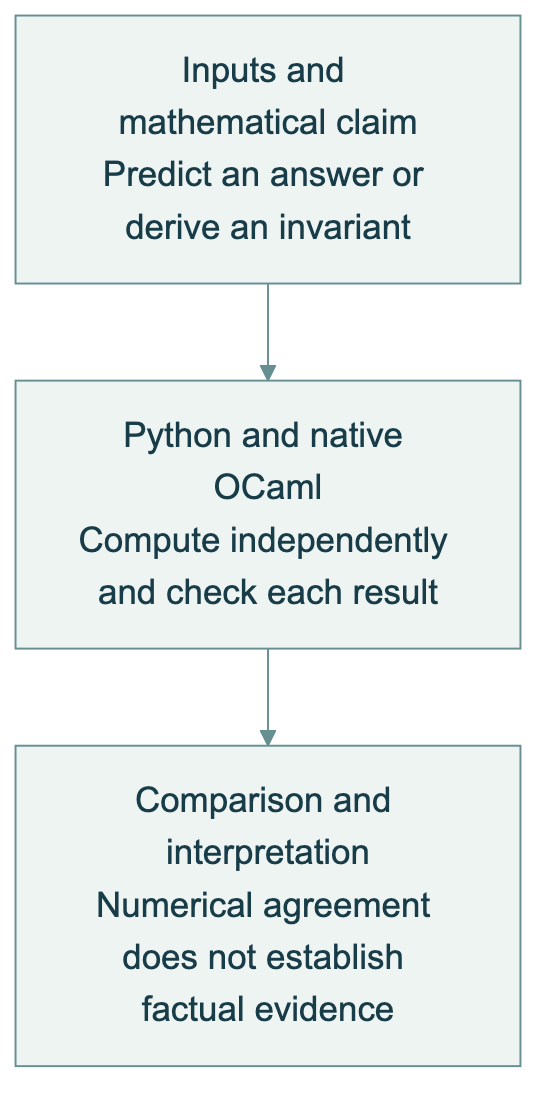

*A calculation needs both an independent mathematical check and a clear boundary on the claim it supports.*

<a id="explaining-results"></a>

### Explain a result before extending it

For any calculation, write down the input, the operation, the output, and the
property that checks it. For a least-squares fit, the input includes both a
design and a response, the operation chooses coefficients minimizing squared
residual length, and the output includes the fitted response as well as those
coefficients. Residual perpendicularity checks optimality, while the
pseudoinverse's coefficient length answers a separate question when solutions
are not unique. Naming all four parts prevents an accurate scalar result from
standing in for an explanation.

For a learned representation, trace the dependencies before editing a parameter.
A change can pass through a score, normalization, weighted combination, pooling,
and loss. The derivative describes local changes along those paths. A notebook
that exposes each intermediate value makes it possible to locate an unexpected
result, rather than treating a changed final score as an unexplained success or
failure. The paired languages provide two implementations of the same declared
experiment; the algebraic identities and reference arithmetic supply checks
that remain meaningful even if both implementations share a misconception.

<a id="transfer-exercises"></a>

## Exercises that join the routes

**A retrieval experiment.** Start with the frozen query lesson. Change the query
while preserving its vocabulary and fitted directions. Compare a direct query
projection with a coordinate rescaled by singular values. Explain which inner
product or distance is being used before calling either result more similar.
Then repeat the comparison after deliberately changing the reference model.
Separate the effect of a changed query from the effect of a changed ruler.

**A concept recommendation.** Use the entropy lesson to select an informative
question, the formal-context lesson to inspect which observed attributes travel
together, and the semantic-rule lesson to state which inferences your rules
actually license. An informative question can be useful even when the answer
does not establish an ontology relation. Write the evidence needed to convert a
numerical suggestion into a maintained factual assertion.

**A representation experiment.** Change one token row in the attention example,
then change the pooling mask. Describe the route through attention weights,
contextual rows, and the final sentence row. Compare the result with a
contrastive objective and explain why a good training loss does not by itself
prove good retrieval on a different domain.

**A probability experiment.** Compare a score's ordering with its calibration.
Use the proper-score and temperature lessons to explain why preserving the
ordering of two examples need not preserve their probability errors. Separate
the data used to choose a temperature from the data used to report its quality.
The grouped Murphy identity is exact for its stated group predictions; it is
not a guarantee that coarse bins diagnose every calibration error.

These are open exercises rather than additional claimed numerical results.
The supplied code computes the fixed examples and exposes editable inputs.
For each extension, state your prediction first, retain checks that still
apply, and explain why any fixed-answer assertion must change. This makes the
notebook a laboratory rather than a transcript to execute without inspection.

<a id="prerequisite-catalog"></a>

# Prerequisite catalog

These are the previously published lessons used by this companion. The linked section opens the existing public reader. Each laboratory title identifies a worked lesson in both frozen notebooks. The study bundle contains those notebooks under `prerequisites/`, with `index.html` linking directly to every exact code cell. These links do not assume a public notebook host.

<a id="prerequisite-notebooks"></a>

## The four prerequisite notebooks

- **Eigen, Python.** `eigentimes-math-python-1.0.0-fe8e8983.ipynb`; edition 1.0.0-fe8e8983; 38 lessons.
- **Eigen, OCAML.** `eigentimes-math-ocaml-1.0.0-fe8e8983.ipynb`; edition 1.0.0-fe8e8983; 38 lessons.
- **Anthropology, Python.** `anthropology-math-python-1.0.0-ac612429.ipynb`; edition 1.0.0-ac612429; 31 lessons.
- **Anthropology, OCAML.** `anthropology-math-ocaml-1.0.0-ac612429.ipynb`; edition 1.0.0-ac612429; 31 lessons.

The SHA-256 file checksums and source revisions are recorded in `research/prerequisites.json`. Copies in the bundle retain their original bytes and saved outputs. A cell is identified by its stable ID, not by a browser line number. Their original numerical examples remain separate from the new examples in this companion.

<a id="prerequisite-routes"></a>

## Where to study an existing technique



**[Counting words](https://firstpair.org/read/eigentimes-math/chapters/chapter-004.html#counting-words)** (Eigen companion).

- Build the exact six-document count table. python: `python-009-3c9c6f21`; ocaml: `ocaml-009-281cca42`.





**[TF‑IDF](https://firstpair.org/read/eigentimes-math/chapters/chapter-004.html#tfidf)** (Eigen companion).

- Damped counts, inverse frequencies, and unit rows. python: `python-012-266676b6`; ocaml: `ocaml-012-9692ef44`.





**[A matrix times a vector](https://firstpair.org/read/eigentimes-math/chapters/chapter-005.html#a-matrix-times-a-vector)** (Eigen companion).

- Rebuild Figure 2. python: `python-022-b5a4f5f9`; ocaml: `ocaml-022-9f6c6b73`.





**[A matrix times a matrix](https://firstpair.org/read/eigentimes-math/chapters/chapter-005.html#a-matrix-times-a-matrix)** (Eigen companion).

- Rebuild Figure 3 and check shapes. python: `python-025-c97f6079`; ocaml: `ocaml-025-4bfd0ce5`.





**[Transpose, symmetry, orthogonality](https://firstpair.org/read/eigentimes-math/chapters/chapter-005.html#transpose-symmetry-orthogonality)** (Eigen companion).

- A projection is not a full rotation. python: `python-028-5c0acc3a`; ocaml: `ocaml-028-624f1c6e`.





**[Centering and covariance](https://firstpair.org/read/eigentimes-math/chapters/chapter-006.html#centering-and-covariance)** (Eigen companion).

- Compute Figure 4 and a weighted covariance two ways. python: `python-032-d484a6f1`; ocaml: `ocaml-032-066421dc`.





**[Sums over blocks](https://firstpair.org/read/eigentimes-math/chapters/chapter-013.html#sums-over-blocks)** (Eigen companion).

- Merge covariance sufficient summaries. python: `python-106-80aca9d5`; ocaml: `ocaml-106-ba6a6f5f`.





**[Eigenvectors: the axes of the cloud](https://firstpair.org/read/eigentimes-math/chapters/chapter-006.html#eigenvectors-the-axes-of-the-cloud)** (Eigen companion).

- Recompute the 300-point illustration. python: `python-035-a0ba2058`; ocaml: `ocaml-035-21a2897f`.





**[How many axes to keep](https://firstpair.org/read/eigentimes-math/chapters/chapter-006.html#how-many-axes-to-keep)** (Eigen companion).

- Variance retention and a noise-model reference. python: `python-038-e6fbb926`; ocaml: `ocaml-038-fb9bc110`.





**[What the SVD is](https://firstpair.org/read/eigentimes-math/chapters/chapter-007.html#what-the-svd-is)** (Eigen companion).

- Thin factors, scores and covariance eigenvalues. python: `python-042-ed38dce5`; ocaml: `ocaml-042-5e9db47b`.





**[Truncation](https://firstpair.org/read/eigentimes-math/chapters/chapter-007.html#truncation)** (Eigen companion).

- Recompute every low-rank error in Figure 7. python: `python-045-2abd3ce6`; ocaml: `ocaml-045-d7817043`.





**[Latent semantic analysis](https://firstpair.org/read/eigentimes-math/chapters/chapter-007.html#latent-semantic-analysis)** (Eigen companion).

- Word lists, implicit centering and randomized range finding. python: `python-048-6a0f53cd`; ocaml: `ocaml-048-2469b260`.





**[Varimax](https://firstpair.org/read/eigentimes-math/chapters/chapter-008.html#varimax)** (Eigen companion).

- Recompute the exact pairwise Givens angle and lexical loadings. python: `python-055-aa42178b`; ocaml: `ocaml-055-3c51fef7`.





**[Projection, reconstruction, residual](https://firstpair.org/read/eigentimes-math/chapters/chapter-009.html#projection-reconstruction-residual)** (Eigen companion).

- A fully computed story measurement. python: `python-059-59c63a4e`; ocaml: `ocaml-059-7103155e`.





**[T² and Q](https://firstpair.org/read/eigentimes-math/chapters/chapter-009.html#t²-and-q)** (Eigen companion).

- Whitening, rotation invariance and means that do not commute. python: `python-062-7269271c`; ocaml: `ocaml-062-3020ef3d`.





**[Dominant axis, spectrum, profile](https://firstpair.org/read/eigentimes-math/chapters/chapter-009.html#dominant-axis-spectrum-profile)** (Eigen companion).

- Signed dominance, attention and the daily mixture. python: `python-065-56ae5aa4`; ocaml: `ocaml-065-580763be`.





**[±2σ on the spectrum](https://firstpair.org/read/eigentimes-math/chapters/chapter-011.html#σ-on-the-spectrum)** (Eigen companion).

- Welford statistics and the multiple-axis caveat. python: `python-083-4e445193`; ocaml: `ocaml-083-70c876ed`.





**[Stories: single linkage on a day’s articles](https://firstpair.org/read/eigentimes-math/chapters/chapter-010.html#stories-single-linkage-on-a-days-articles)** (Eigen companion).

- Compute chaining and audit the archived threshold sweep. python: `python-069-2eadc8bd`; ocaml: `ocaml-069-5956b46f`.
- Recompute the archived histogram presentation. python: `python-071-f64e3672`; ocaml: `ocaml-071-cd4001b5`.





**[Kuhn–Munkres](https://firstpair.org/read/eigentimes-math/chapters/chapter-012.html#kuhnmunkres)** (Eigen companion).

- Solve a global assignment, then compare score correlations. python: `python-096-9d00ff86`; ocaml: `ocaml-096-5744026e`.





**[Why nightly refinement is stable](https://firstpair.org/read/eigentimes-math/chapters/chapter-012.html#why-nightly-refinement-is-stable)** (Eigen companion).

- Check Davis–Kahan and align a rotated subspace. python: `python-099-afe09a1d`; ocaml: `ocaml-099-4a9edd3d`.





**[Aligning maps needs anchors and room to test them](https://firstpair.org/read/anthropology-math/chapters/chapter-012.html#aligning-maps-needs-anchors-and-room-to-test-them)** (Anthropology companion).

- Fit a tiny alignment and compute the rank shortage. python: `python-105-254689a8`; ocaml: `ocaml-105-d281bb97`.





**[Start with associations and keep the background unique](https://firstpair.org/read/anthropology-math/chapters/chapter-005.html#start-with-associations-and-keep-the-background-unique)** (Anthropology companion).

- Expand batches and deduplicate by article identity. python: `python-026-ab58740d`; ocaml: `ocaml-026-7253129f`.





**[Give supported cells equal weight](https://firstpair.org/read/anthropology-math/chapters/chapter-005.html#give-supported-cells-equal-weight)** (Anthropology companion).

- Apply support gates before averaging. python: `python-032-dcd3e6cf`; ocaml: `ocaml-032-f8ecc71b`.





**[Keep direction and report support separately](https://firstpair.org/read/anthropology-math/chapters/chapter-005.html#keep-direction-and-report-support-separately)** (Anthropology companion).

- Normalize only supported, nonzero contrasts. python: `python-035-7fcec816`; ocaml: `ocaml-035-21840e49`.





**[Covariance asks which coordinates move together](https://firstpair.org/read/anthropology-math/chapters/chapter-006.html#covariance-asks-which-coordinates-move-together)** (Anthropology companion).

- Give every person one row and one vote. python: `python-040-f8e223ea`; ocaml: `ocaml-040-e97c7b18`.





**[Keep two patterns in the toy world](https://firstpair.org/read/anthropology-math/chapters/chapter-006.html#keep-two-patterns-in-the-toy-world)** (Anthropology companion).

- Fit directions and measure retained variance. python: `python-043-ddb92c1d`; ocaml: `ocaml-043-9540f874`.





**[Locate a person on the patterns](https://firstpair.org/read/anthropology-math/chapters/chapter-006.html#locate-a-person-on-the-patterns)** (Anthropology companion).

- Compute each person's coordinates. python: `python-046-572ba87d`; ocaml: `ocaml-046-c4ff85bb`.





**[People can be ranked in two distinct ways](https://firstpair.org/read/anthropology-math/chapters/chapter-007.html#people-can-be-ranked-in-two-distinct-ways)** (Anthropology companion).

- Walk one loading table in both directions. python: `python-052-3d3c0f2a`; ocaml: `ocaml-052-a5e3ae77`.
- Check the dated reciprocal-index entry. python: `python-054-356e18a7`; ocaml: `ocaml-054-350b7ced`.





**[The return operation](https://firstpair.org/read/anthropology-math/chapters/chapter-008.html#the-return-operation)** (Anthropology companion).

- Compute the round trip and each person's lost energy. python: `python-058-1bbf0100`; ocaml: `ocaml-058-05bede39`.





**[An even smaller exact example](https://firstpair.org/read/anthropology-math/chapters/chapter-008.html#an-even-smaller-exact-example)** (Anthropology companion).

- Show two different inputs with the same return. python: `python-061-b0bc45da`; ocaml: `ocaml-061-c703ebaa`.





**[Why the singular value decomposition gives two views](https://firstpair.org/read/anthropology-math/chapters/chapter-008.html#why-the-singular-value-decomposition-gives-two-views)** (Anthropology companion).

- Compute SVD, not just its formula. python: `python-065-0162dc38`; ocaml: `ocaml-065-3e5e4db6`.





**[Reuse the ruler](https://firstpair.org/read/anthropology-math/chapters/chapter-010.html#reuse-the-ruler)** (Anthropology companion).






**[Separate movement from a change of mixture](https://firstpair.org/read/anthropology-math/chapters/chapter-010.html#separate-movement-from-a-change-of-mixture)** (Anthropology companion).

- Hold the contrasts fixed and change only the counts. python: `python-076-159139e0`; ocaml: `ocaml-076-28c3e1f4`.





**[Three clocks and a model version](https://firstpair.org/read/anthropology-math/chapters/chapter-010.html#three-clocks-and-a-model-version)** (Anthropology companion).






**[A tag, an axis, and a hierarchy](https://firstpair.org/read/anthropology-math/chapters/chapter-012.html#a-tag-an-axis-and-a-hierarchy)** (Anthropology companion).






**[A small, reviewed bridge comes first](https://firstpair.org/read/anthropology-math/chapters/chapter-012.html#a-small-reviewed-bridge-comes-first)** (Anthropology companion).

- Traverse a synthetic ontology and a reviewed crosswalk. python: `python-093-40c08441`; ocaml: `ocaml-093-bc7d1dbf`.





**[Learning a concept score, one multiplication at a time](https://firstpair.org/read/anthropology-math/chapters/chapter-012.html#learning-a-concept-score-one-multiplication-at-a-time)** (Anthropology companion).

- Fit both ridge targets from the four reviewed rows. python: `python-096-cac2408e`; ocaml: `ocaml-096-60fe0a2f`.





**[A score becomes a probability only after another question](https://firstpair.org/read/anthropology-math/chapters/chapter-012.html#a-score-becomes-a-probability-only-after-another-question)** (Anthropology companion).

- Fit a logistic toy model, then test a reliability bin. python: `python-099-da7456b3`; ocaml: `ocaml-099-3c21f499`.

<a id="glossary"></a>

# Glossary

Definitions here are reminders. The linked lesson introduces each specialized term before its calculation. The notation guide declares the common symbols; a local symbol is defined in its own lesson.

**Attention.** A weighted combination of value rows, with weights determined by query–key compatibility and normalization. [Study](#modern-token-attention).

**Backpropagation.** Application of the chain rule from a loss backward through intermediate computations to obtain parameter derivatives. [Study](#modern-backprop).

**Basis.** An independent list of vectors spanning a space. [Study](#notation).

**Bayesian posterior.** A probability distribution updated from a prior using a stated likelihood and observed evidence. [Study](#modern-entropy).

**Bidiagonal matrix.** A matrix with possible nonzero entries only on the main diagonal and the diagonal immediately above or below it. [Study](#early-bidiagonal).

**Binary64.** A floating-point format using 64 bits per value; it rounds many real numbers and arithmetic results. [Study](#early-bidiagonal).

**Brier score.** Squared probability error; the binary convention used here records one outcome, whereas the original category-summed convention counts both binary outcomes. [Study](#modern-proper-scores).

**Calibration.** Agreement between predicted probabilities and observed frequencies under a stated evaluation grouping or distribution. [Study](#modern-murphy).

**Cancellation.** Loss of significant digits when nearly equal finite-precision quantities are subtracted. [Study](#early-centered-merge).

**Chain rule.** A derivative rule that multiplies local derivatives along a composed path and sums contributions from multiple paths. [Study](#modern-backprop).

**Closure.** An operation that is extensive, monotone, and idempotent: it contains its input, preserves inclusion, and stops changing after one application. [Study](#modern-fca).

**Collinearity.** Linear dependence, or near dependence, among predictor columns; it makes fitted coefficients nonunique or sensitive. [Study](#early-least-squares).

**Compact SVD.** A singular-value decomposition retaining only positive singular values and their corresponding columns. [Study](#early-pseudoinverse).

**Completed square.** A quadratic rewritten as a scaled square plus a constant; when the scale is positive, the constant is its minimum. [Study](#early-least-squares).

**Conclusion.** A statement licensed by an inference rule when its required premises match. [Study](#modern-semantic-rules).

**Condition number.** A measure of worst-case relative output sensitivity to relative input changes for a specified problem and norm. [Study](#early-bidiagonal).

**Conditioning.** The sensitivity of a mathematical problem to changes in its inputs, separate from the rounding behavior of a chosen algorithm. [Study](#early-bidiagonal).

**Contextual representation.** A token representation influenced by surrounding tokens rather than by token identity alone. [Study](#modern-sentence-rows).

**Contrastive loss.** An objective comparing a designated positive pair against alternatives; it is not by itself a probability calibration guarantee. [Study](#modern-sentence-rows).

**Corrected sum of squares.** The sum of squared deviations about a stated mean; a centered summary can preserve it for stable merging. [Study](#early-centered-merge).

**Covariance.** A matrix summarizing how centered coordinate products vary together, under declared weights and normalization. [Study](#notation-series).

**Cross entropy.** Expected negative log probability under a target distribution; for a single observed class it reduces to negative log probability of that class. [Study](#modern-proper-scores).

**Cycle.** A closed graph path with no repeated intermediate vertex; trees contain no cycles. [Study](#early-mst).

**Derivative.** The limiting output change per input change for a scalar function, when that limit exists. [Study](#notation).

**Determinant.** For a square matrix, the signed volume scaling; in two dimensions, ad minus bc for rows (a,b) and (c,d). [Study](#early-bidiagonal).

**Dot product.** The sum of coordinatewise products of two equally sized vectors. [Study](#notation).

**Eigenvalue.** The scalar by which a square matrix multiplies one of its nonzero eigenvector directions. [Study](#notation).

**Eigenvector.** A nonzero direction mapped to a scalar multiple of itself by a square matrix. [Study](#notation).

**Embedding.** A numerical representation placing objects in a common coordinate space for specified computations. [Study](#modern-negative-sampling).

**Entropy.** Expected information content of an outcome under a stated probability distribution and logarithm base. [Study](#modern-entropy).

**Euclidean norm.** The length of a vector: square each coordinate, add, and take a square root. [Study](#notation).

**Expectation.** An average over possible outcomes weighted by their probabilities under a declared distribution. [Study](#modern-proper-scores).

**Expected information gain.** The average reduction in uncertainty from observing an answer, averaging over the possible answers before selecting one. [Study](#modern-entropy).

**Exponential function.** The positive function exp(x)=e raised to x, inverse to the natural logarithm and equal to its own derivative. [Study](#modern-proper-scores).

**Extensiveness.** The property that a closure contains its original input set. [Study](#modern-fca).

**Extent.** The objects belonging to a formal concept in a binary object–attribute context. [Study](#modern-fca).

**Finite precision.** Representation of numbers using finitely many bits, with rounding of many exact mathematical operations. [Study](#teaching-contract).

**Fixed point.** A state unchanged by another application of an operation; rule closure stops when another pass adds no statements. [Study](#modern-semantic-rules).

**Fold-in.** Mapping a new query through a previously fitted lexical representation without refitting its vocabulary or directions. [Study](#early-lsa-query).

**Formal concept.** An extent and intent that determine each other through the incidence relation of a formal context. [Study](#modern-fca).

**Frobenius norm.** The square root of the sum of squares of all matrix entries. [Study](#notation).

**Frozen transform.** A learned transformation whose vocabulary, means, scales, and directions are held fixed while new observations are mapped. [Study](#early-lsa-query).

**Gradient.** The vector of partial derivatives of a scalar objective with respect to its parameters. [Study](#notation).

**Gradient descent.** A parameter update subtracting a positive step size times the loss gradient; its local motivation does not guarantee improvement for every finite step. [Study](#modern-backprop).

**Gram matrix.** A matrix of pairwise inner products; forming it can square a matrix's spectral condition number. [Study](#early-bidiagonal).

**Gram–Schmidt.** Construction of orthonormal columns by subtracting projections onto previously constructed columns and normalizing the remainder. [Study](#early-gram-schmidt).

**Householder reflection.** An orthogonal transformation reflecting across a hyperplane, used to zero selected coordinates without changing lengths. [Study](#early-householder).

**Hyperbolic tangent.** A smooth nonlinear function taking values between minus one and one, with derivative one minus the square of its output. [Study](#modern-backprop).

**Idempotence.** The property that applying an operation twice has the same result as applying it once. [Study](#modern-fca).

**Incidence.** A declared relationship recording which object has which attribute, or which person is associated with which article. [Study](#modern-fca).

**Information content.** The negative logarithm of an event's probability, with the logarithm base determining the unit. [Study](#modern-entropy).

**Intent.** The attributes shared by all objects in a formal concept's extent. [Study](#modern-fca).

**Intercept.** The coefficient of an all-ones predictor column, representing the fitted response when other predictors are zero. [Study](#early-least-squares).

**Invariant.** A property preserved by an operation when its assumptions hold. [Study](#learning-route).

**Jacobi rotation.** A plane rotation chosen to remove an off-diagonal entry of a real symmetric matrix during iterative diagonalization. [Study](#early-jacobi).

**Lattice.** A partially ordered set in which each pair has a greatest lower bound and a least upper bound. [Study](#modern-fca).

**Least squares.** Fitting parameters by minimizing a sum of squared residuals. [Study](#early-least-squares).

**Likelihood.** The probability of observed evidence as a function of a hypothesized state or model. [Study](#modern-entropy).

**Log score.** Negative log probability assigned to the observed outcome, when interpreted as a loss to minimize. [Study](#modern-proper-scores).

**Logarithm.** The inverse of exponentiation; natural logarithms use base e and base-two logarithms measure information in bits. [Study](#notation).

**Logistic sigmoid.** The function mapping a real score to a number between zero and one; its output still needs an appropriate probabilistic model and calibration evidence. [Study](#modern-negative-sampling).

**Logit.** A scalar score supplied to probability normalization; for a binary sigmoid probability, its inverse is the log odds. [Study](#modern-temperature).

**Mask.** A rule excluding selected attention positions before the remaining weights are normalized. [Study](#modern-token-attention).

**Mean squared error.** The average of squared residual entries, obtained by dividing squared residual length by the number of entries. [Study](#notation).

**Minimum spanning tree.** A tree connecting all vertices of a weighted undirected graph with minimum total edge weight. [Study](#early-mst).

**Minimum-norm solution.** Among all solutions with the same best fit, the coefficient vector with the smallest Euclidean length. [Study](#early-pseudoinverse).

**Monotonicity of closure.** Preservation of inclusion: enlarging an input set cannot shrink its closure. [Study](#modern-fca).

**Negative sampling.** A training objective that contrasts an observed pair with sampled alternative pairs; it is distinct from full-vocabulary softmax likelihood. [Study](#modern-negative-sampling).

**Normal equations.** The least-squares stationarity equations obtained by setting the residual's inner products with the design columns to zero. [Study](#early-least-squares).

**Nullspace.** The set of input vectors that a matrix maps to zero. [Study](#notation).

**Numerical stability.** The behavior of a computational procedure under finite-precision rounding, distinct from sensitivity inherent in its mathematical problem. [Study](#early-bidiagonal).

**Odds.** For an event probability strictly between zero and one, its probability divided by the probability of its complement. [Study](#modern-temperature).

**Off-diagonal energy.** The sum of squared entries outside the diagonal of a matrix; Jacobi rotations reduce it for the symmetric diagonalization problem. [Study](#early-jacobi).

**Ontology.** An organized collection of concepts and relations with stated meanings and rules; similarity alone does not establish those relations. [Study](#modern-semantic-rules).

**Open-world assumption.** The absence of a fact does not establish its negation. [Study](#modern-semantic-rules).

**Orthogonal matrix.** A square matrix whose transpose is its inverse; it preserves Euclidean lengths and inner products. [Study](#notation).

**Orthonormal frame.** A list of mutually orthogonal unit vectors, represented here as columns. [Study](#early-gram-schmidt).

**Partial derivative.** A local rate of change with respect to one input while holding the others fixed. [Study](#notation).

**Path.** A sequence of graph edges meeting at successive vertices; existence of a path defines connectivity. [Study](#early-mst).

**Pooling.** Combining token representations into one row, using a declared operation such as a mask-aware mean. [Study](#modern-sentence-rows).

**Premise.** A statement required by an inference rule before that rule licenses a conclusion. [Study](#modern-semantic-rules).

**Principal angles.** Angles between subspaces defined through singular values of the cross-product of their orthonormal frames. [Study](#early-principal-angles).

**Prior.** The probability distribution over hypotheses before incorporating the observation being considered. [Study](#modern-entropy).

**Projection.** Mapping onto a subspace; an orthogonal projection leaves a perpendicular residual. [Study](#early-gram-schmidt).

**Projector distance.** A stated matrix norm of the difference between two orthogonal projection matrices, used to compare subspaces without naming individual axes. [Study](#early-principal-angles).

**Proper scoring rule.** A forecast score whose expected loss is minimized by reporting the true probability distribution. [Study](#modern-proper-scores).

**Provenance.** A record of the source of an assertion or of the supporting premises for a derived conclusion. [Study](#modern-semantic-rules).

**Pseudoinverse.** The Moore–Penrose generalized inverse, yielding the minimum-norm least-squares solution even when a matrix is rank deficient. [Study](#early-pseudoinverse).

**Pythagorean identity.** The squared length of a sum of perpendicular vectors equals the sum of their squared lengths. [Study](#early-gram-schmidt).

**QR factorization.** Representation of a matrix as orthonormal columns times an upper triangular or upper-trapezoidal factor, with dimensions stated for full or thin forms. [Study](#early-householder).

**Quantization.** Mapping a range of real numbers to a finite set of represented levels, usually trading storage or computation against error. [Study](#modern-quantization).

**Radian.** An angle measured as circular arc length divided by radius; pi radians is a half-turn. [Study](#early-jacobi).

**Rank.** The dimension of a matrix's column span, equal to the dimension of its row span. [Study](#notation).

**Reciprocal rule.** The derivative of one divided by a nonzero scalar input is minus one divided by that input squared; a composed denominator also requires the chain rule. [Study](#modern-proper-scores).

**Reconstruction.** An approximation mapped back into the original coordinate system from a compressed representation. [Study](#early-pseudoinverse).

**Reorthogonalization.** Repeating projection subtraction to reduce numerical loss of orthogonality. [Study](#early-gram-schmidt).

**Residual.** The difference between an observed quantity and its fitted or reconstructed value. [Study](#early-least-squares).

**Residual length.** The nonnegative Euclidean length of the vector of observed-minus-fitted discrepancies; it has the units of the response. [Study](#early-least-squares).

**Resolution.** In the Murphy decomposition, the separation of group event frequencies from the overall event frequency. [Study](#modern-murphy).

**Root mean squared error.** The square root of the average squared residual; unlike squared error, it has the response unit. [Study](#notation).

**Rounding error.** Discrepancy caused by finite-precision representation or arithmetic, separate from model approximation or factual error. [Study](#teaching-contract).

**Semantic triple.** A subject–predicate–object assertion, whose interpretation depends on the vocabulary and entailment rules used. [Study](#modern-semantic-rules).

**Sine and cosine.** The vertical and horizontal coordinates, respectively, of a unit-circle point after a specified counterclockwise turn from (1,0). [Study](#early-jacobi).

**Single linkage.** Clustering by connected components after retaining pairwise edges below a distance threshold. [Study](#early-mst).

**Singular value.** A nonnegative scale in the singular-value decomposition of a matrix. [Study](#early-pseudoinverse).

**Slope.** A fitted response change per unit change of a predictor when other predictors are held fixed. [Study](#early-least-squares).

**Softmax.** The transformation of finite scores into positive normalized weights by exponentiating and dividing by their sum. [Study](#modern-token-attention).

**Softplus.** The function ln(1+exp(x)), evaluated with an algebraic rearrangement when needed to avoid overflow. [Study](#modern-negative-sampling).

**Span.** The set of all linear combinations of a list of vectors. [Study](#notation).

**Squared residual length.** The sum of squared residual entries; squaring removes cancellation of opposite signs but changes the physical units. [Study](#early-least-squares).

**Temperature scaling.** Dividing fixed model logits by a positive fitted scalar before probability normalization; fitting needs separate labeled data. [Study](#modern-temperature).

**Token.** A unit produced by a text tokenizer, such as a word, subword, or punctuation unit. [Study](#modern-token-attention).

**Transpose.** The operation exchanging the rows and columns of a matrix. [Study](#notation).

**Uncertainty.** In the Murphy decomposition, the overall binary event variance; elsewhere the term must specify its probability model and measure. [Study](#modern-murphy).

**Union-find.** A data structure maintaining disjoint sets under unions and representative lookup, useful for graph connected components. [Study](#early-mst).

**Unit circle.** The circle of radius one centered at the origin of two perpendicular coordinates, used to define sine and cosine. [Study](#early-jacobi).

<a id="bibliography"></a>

# Bibliography

Original publication dates are given below. A linked title leads to its publisher, institutional archive, author copy, or model card; a separate scan link is supplied when useful. Biographical links identify authors and do not replace primary evidence. The source bundle includes the access and attribution ledger, machine-readable records, and a BibTeX file.

<a id="ref-bjorckgolub1973"></a>
[Åke Björck](https://sv.wikipedia.org/wiki/%C3%85ke_Bj%C3%B6rck); [Gene H. Golub](https://en.wikipedia.org/wiki/Gene_H._Golub). (1973). *[Numerical Methods for Computing Angles Between Linear Subspaces](https://doi.org/10.1090/S0025-5718-1973-0348991-3)*. Mathematics of Computation 27(123), 579–594. [Primary copy](https://www.researchgate.net/publication/230872639_Numerical_Methods_for_Computing_Angles_Between_Linear_Subspaces).


<a id="ref-brier1950"></a>
[Glenn W. Brier](https://en.wikipedia.org/wiki/Glenn_W._Brier). (1950). *[Verification of Forecasts Expressed in Terms of Probability](https://doi.org/10.1175/1520-0493(1950)078<0001:VOFEIT>2.0.CO;2)*. Monthly Weather Review 78(1), 1–3.


<a id="ref-changlevequegolub1983"></a>
[Tony F. Chan](https://en.wikipedia.org/wiki/Tony_F._Chan); [Gene H. Golub](https://en.wikipedia.org/wiki/Gene_H._Golub); [Randall J. LeVeque](https://en.wikipedia.org/wiki/Randall_LeVeque). (1983). *[Algorithms for Computing the Sample Variance: Analysis and Recommendations](https://www.tandfonline.com/doi/abs/10.1080/00031305.1983.10483115)*. The American Statistician 37(3), 242–247. [Primary copy](https://math.pku.edu.cn/teachers/litj/notes/numer_anal/AmerStat_37_242_Chan_Variance.pdf).


<a id="ref-rdf2014"></a>
Richard Cyganiak (editor); David Wood (editor); Markus Lanthaler (editor). (2014). *[RDF 1.1 Concepts and Abstract Syntax](https://www.w3.org/TR/2014/REC-rdf11-concepts-20140225/)*. W3C Recommendation, 25 February 2014.


<a id="ref-deerwester1990"></a>
[Scott Deerwester](https://en.wikipedia.org/wiki/Scott_Deerwester); [Susan T. Dumais](https://en.wikipedia.org/wiki/Susan_Dumais); [George W. Furnas](https://en.wikipedia.org/wiki/George_Furnas); [Thomas K. Landauer](https://en.wikipedia.org/wiki/Thomas_Landauer); [Richard Harshman](https://en.wikipedia.org/wiki/Richard_A._Harshman). (1990). *[Indexing by latent semantic analysis](https://asistdl.onlinelibrary.wiley.com/doi/10.1002/%28SICI%291097-4571%28199009%2941%3A6%3C391%3A%3AAID-ASI1%3E3.0.CO%3B2-9)*. Journal of the American Society for Information Science 41(6), 391–407. [Primary copy](https://www.microsoft.com/en-us/research/publication/indexing-by-latent-semantic-analysis/).


<a id="ref-devlin2019"></a>
Jacob Devlin; Ming-Wei Chang; Kenton Lee; Kristina Toutanova. (2019). *[BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://aclanthology.org/N19-1423/)*. NAACL-HLT 2019, 4171–4186.


<a id="ref-florek1951"></a>
K. Florek; [J. Łukaszewicz](https://pl.wikipedia.org/wiki/J%C3%B3zef_%C5%81ukaszewicz_%28matematyk%29); [J. Perkal](https://pl.wikipedia.org/wiki/Julian_Perkal); [Hugo Steinhaus](https://en.wikipedia.org/wiki/Hugo_Steinhaus); [S. Zubrzycki](https://pl.wikipedia.org/wiki/Stefan_Zubrzycki). (1951). *[Sur la liaison et la division des points d’un ensemble fini](https://doi.org/10.4064/cm-2-3-4-282-285)*. Colloquium Mathematicum 2(3–4), 282–285. [Primary copy](https://www.impan.pl/shop/en/publication/transaction/download/product/93811).


<a id="ref-ganter-wille1999"></a>
[Bernhard Ganter](https://de.wikipedia.org/wiki/Bernhard_Ganter); [Rudolf Wille](https://en.wikipedia.org/wiki/Rudolf_Wille). (1999). *[Formal Concept Analysis: Mathematical Foundations](https://link.springer.com/book/10.1007/978-3-642-59830-2)*. Springer, first English edition.


<a id="ref-gneiting-raftery2007"></a>
Tilmann Gneiting; [Adrian E. Raftery](https://en.wikipedia.org/wiki/Adrian_Raftery). (2007). *[Strictly Proper Scoring Rules, Prediction, and Estimation](https://doi.org/10.1198/016214506000001437)*. Journal of the American Statistical Association 102(477), 359–378.


<a id="ref-golubkahan1965"></a>
[Gene H. Golub](https://en.wikipedia.org/wiki/Gene_H._Golub); [William Kahan](https://en.wikipedia.org/wiki/William_Kahan). (1965). *[Calculating the Singular Values and Pseudo-Inverse of a Matrix](https://epubs.siam.org/doi/10.1137/0702016)*. Journal of the Society for Industrial and Applied Mathematics, Series B: Numerical Analysis 2(2), 205–224.


<a id="ref-golubreinsch1970"></a>
[G. H. Golub](https://en.wikipedia.org/wiki/Gene_H._Golub); [C. Reinsch](https://en.wikipedia.org/wiki/Christian_Reinsch). (1970). *[Singular value decomposition and least squares solutions](https://link.springer.com/article/10.1007/BF02163027)*. Numerische Mathematik 14(5), 403–420. [Primary copy](https://people.duke.edu/~hpgavin/SystemID/References/Golub%2BReinsch-NM-1970.pdf).


<a id="ref-gowerross1969"></a>
J. C. Gower; G. J. S. Ross. (1969). *[Minimum Spanning Trees and Single Linkage Cluster Analysis](https://academic.oup.com/jrsssc/article/18/1/54/6882518)*. Journal of the Royal Statistical Society. Series C (Applied Statistics) 18(1), 54–64.


<a id="ref-gram1883"></a>
[Jørgen Pedersen Gram](https://en.wikipedia.org/wiki/J%C3%B8rgen_Pedersen_Gram). (1883). *[Ueber die Entwickelung reeller Functionen in Reihen mittelst der Methode der kleinsten Quadrate](https://gdz.sub.uni-goettingen.de/dms/resolveppn/?PPN=GDZPPN002158604)*. Journal für die reine und angewandte Mathematik 94, 41–73.


<a id="ref-guo2017"></a>
Chuan Guo; Geoff Pleiss; Yu Sun; Kilian Q. Weinberger. (2017). *[On Calibration of Modern Neural Networks](https://proceedings.mlr.press/v70/guo17a.html)*. ICML 2017, PMLR 70, 1321–1330.


<a id="ref-hoerl-kennard1970"></a>
Arthur E. Hoerl; Robert W. Kennard. (1970). *[Ridge Regression: Biased Estimation for Nonorthogonal Problems](https://www.tandfonline.com/doi/abs/10.1080/00401706.1970.10488634)*. Technometrics 12(1), 55–67. [Primary copy](https://homepages.math.uic.edu/~lreyzin/papers/ridge.pdf).


<a id="ref-jacobi1846"></a>
[Carl Gustav Jacob Jacobi](https://en.wikipedia.org/wiki/Carl_Gustav_Jacob_Jacobi). (1846). *[Über ein leichtes Verfahren die in der Theorie der Säcularstörungen vorkommenden Gleichungen numerisch aufzulösen](https://gdz.sub.uni-goettingen.de/download/pdf/PPN243919689_0030/LOG_0007.pdf)*. Journal für die reine und angewandte Mathematik 30, 51–94.


<a id="ref-legendre1805"></a>
[Adrien-Marie Legendre](https://en.wikipedia.org/wiki/Adrien-Marie_Legendre). (1805). *[Nouvelles méthodes pour la détermination des orbites des comètes](https://www.e-rara.ch/zut/doi/10.3931/e-rara-35115)*. Paris: Firmin Didot, Appendix, 72–80.


<a id="ref-mikolov2013-efficient"></a>
[Tomas Mikolov](https://en.wikipedia.org/wiki/Tom%C3%A1%C5%A1_Mikolov); Kai Chen; [Greg Corrado](https://en.wikipedia.org/wiki/Greg_Corrado); [Jeffrey Dean](https://en.wikipedia.org/wiki/Jeff_Dean). (2013a). *[Efficient Estimation of Word Representations in Vector Space](https://arxiv.org/abs/1301.3781)*. arXiv:1301.3781; submitted 16 January 2013.


<a id="ref-mikolov2013-distributed"></a>
[Tomas Mikolov](https://en.wikipedia.org/wiki/Tom%C3%A1%C5%A1_Mikolov); [Ilya Sutskever](https://en.wikipedia.org/wiki/Ilya_Sutskever); Kai Chen; [Greg S. Corrado](https://en.wikipedia.org/wiki/Greg_Corrado); [Jeff Dean](https://en.wikipedia.org/wiki/Jeff_Dean). (2013b). *[Distributed Representations of Words and Phrases and their Compositionality](https://proceedings.neurips.cc/paper/2013/hash/9aa42b31882ec039965f3c4923ce901b-Abstract.html)*. Advances in Neural Information Processing Systems 26.


<a id="ref-skos2009"></a>
Alistair Miles (editor); Sean Bechhofer (editor). (2009). *[SKOS Simple Knowledge Organization System Reference](https://www.w3.org/TR/2009/REC-skos-reference-20090818/)*. W3C Recommendation, 18 August 2009.


<a id="ref-murphy1973"></a>
Allan H. Murphy. (1973). *[A New Vector Partition of the Probability Score](https://journals.ametsoc.org/abstract/journals/apme/12/4/1520-0450_1973_012_0595_anvpot_2_0_co_2.xml)*. Journal of Applied Meteorology 12(4), 595–600.


<a id="ref-qdrant-bge-onnx"></a>
Qdrant. (n.d.). *[Qdrant/bge-small-en-v1.5-onnx-Q](https://huggingface.co/Qdrant/bge-small-en-v1.5-onnx-Q)*. Official quantized ONNX model card; exact artifact publication date not independently fixed. Model card, accessed 3 October 2026.


<a id="ref-reimers-gurevych2019"></a>
Nils Reimers; [Iryna Gurevych](https://en.wikipedia.org/wiki/Iryna_Gurevych). (2019). *[Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks](https://aclanthology.org/D19-1410/)*. EMNLP-IJCNLP 2019, 3982–3992.


<a id="ref-rumelhart-hinton-williams1986"></a>
[David E. Rumelhart](https://en.wikipedia.org/wiki/David_Rumelhart); [Geoffrey E. Hinton](https://en.wikipedia.org/wiki/Geoffrey_Hinton); [Ronald J. Williams](https://en.wikipedia.org/wiki/Ronald_J._Williams). (1986). *[Learning representations by back-propagating errors](https://www.nature.com/articles/323533a0)*. Nature 323, 533–536.


<a id="ref-saltonwongyang1975"></a>
[G. Salton](https://en.wikipedia.org/wiki/Gerard_Salton); A. Wong; C. S. Yang. (1975). *[A Vector Space Model for Automatic Indexing](https://doi.org/10.1145/361219.361220)*. Communications of the ACM 18(11), 613–620. [Primary copy](https://openlib.org/home/krichel/courses/lis618/readings/salton75.pdf).


<a id="ref-schmidt1907"></a>
[Erhard Schmidt](https://en.wikipedia.org/wiki/Erhard_Schmidt). (1907). *[Zur Theorie der linearen und nichtlinearen Integralgleichungen. I. Teil: Entwicklung willkürlicher Funktionen nach Systemen vorgeschriebener](https://gdz.sub.uni-goettingen.de/dms/resolveppn/?PPN=GDZPPN002261464)*. Mathematische Annalen 63, 433–476.


<a id="ref-shannon1948"></a>
[Claude E. Shannon](https://en.wikipedia.org/wiki/Claude_Shannon). (1948). *[A Mathematical Theory of Communication](https://doi.org/10.1002/j.1538-7305.1948.tb01338.x)*. Bell System Technical Journal 27(3,4), 379–423,623–656. [Primary copy](https://www.princeton.edu/~wbialek/rome/refs/shannon_48.pdf).


<a id="ref-vaswani2017"></a>
[Ashish Vaswani](https://en.wikipedia.org/wiki/Ashish_Vaswani); [Noam Shazeer](https://en.wikipedia.org/wiki/Noam_Shazeer); Niki Parmar; Jakob Uszkoreit; [Llion Jones](https://en.wikipedia.org/wiki/Llion_Jones); [Aidan N. Gomez](https://en.wikipedia.org/wiki/Aidan_Gomez); [Łukasz Kaiser](https://pl.wikipedia.org/wiki/%C5%81ukasz_Kaiser); [Illia Polosukhin](https://en.wikipedia.org/wiki/Illia_Polosukhin). (2017). *[Attention Is All You Need](https://proceedings.neurips.cc/paper/2017/hash/3f5ee243547dee91fbd053c1c4a845aa-Abstract.html)*. Advances in Neural Information Processing Systems 30.


<a id="ref-owl2012"></a>
W3C OWL Working Group. (2012). *[OWL 2 Web Ontology Language Document Overview (Second Edition)](https://www.w3.org/TR/2012/REC-owl2-overview-20121211/)*. W3C Recommendation, 11 December 2012.


<a id="ref-welford1962"></a>
B. P. Welford. (1962). *[Note on a Method for Calculating Corrected Sums of Squares and Products](https://www.tandfonline.com/doi/full/10.1080/00401706.1962.10490022)*. Technometrics 4(3), 419–420.

<a id="index"></a>

# Subject and people index

This index points to substantive definitions and discussions, rather than every occurrence. PDF references are page numbers; digital references are section links. Both are generated from the same index inventory.

<a id="subject-index"></a>

## Subjects



**Attention.** [Token attention is a normalized matrix computation](#modern-token-attention).

**Backpropagation.** [A hidden representation learns through the chain rule](#modern-backprop).

**Basis.** [Notation and prerequisites before calculation](#notation).

**Bayesian posterior.** [Uncertainty and the question worth asking](#modern-entropy).

**Bidiagonal matrix.** [Reduce both sides without squaring the difficult scales](#early-bidiagonal).

**Binary64.** [Reduce both sides without squaring the difficult scales](#early-bidiagonal).

**Brier score.** [Probability forecasts and honest expected scores](#modern-proper-scores).

**Calibration.** [Calibration can be perfect while resolution is absent](#modern-murphy).

**Cancellation.** [Merge centered summaries without losing between-block variation](#early-centered-merge).

**Chain rule.** [A hidden representation learns through the chain rule](#modern-backprop).

**Closure.** [An incidence table can generate a concept lattice](#modern-fca).

**Collinearity.** [Fit an error before trusting a coefficient](#early-least-squares).

**Compact SVD.** [Recover the shortest solution when a fit is not unique](#early-pseudoinverse).

**Completed square.** [Fit an error before trusting a coefficient](#early-least-squares).

**Conclusion.** [A recorded triple and a licensed inference are different](#modern-semantic-rules).

**Condition number.** [Reduce both sides without squaring the difficult scales](#early-bidiagonal).

**Conditioning.** [Reduce both sides without squaring the difficult scales](#early-bidiagonal).

**Contextual representation.** [Contextual token rows become reusable sentence rows](#modern-sentence-rows).

**Contrastive loss.** [Contextual token rows become reusable sentence rows](#modern-sentence-rows).

**Corrected sum of squares.** [Merge centered summaries without losing between-block variation](#early-centered-merge).

**Covariance.** [The shared series convention](#notation-series).

**Cross entropy.** [Probability forecasts and honest expected scores](#modern-proper-scores).

**Cycle.** [Find the same clusters in a tree and a complete graph](#early-mst).

**Derivative.** [Notation and prerequisites before calculation](#notation).

**Determinant.** [Reduce both sides without squaring the difficult scales](#early-bidiagonal).

**Dot product.** [Notation and prerequisites before calculation](#notation).

**Eigenvalue.** [Notation and prerequisites before calculation](#notation).

**Eigenvector.** [Notation and prerequisites before calculation](#notation).

**Embedding.** [A word vector learns by contrasting contexts](#modern-negative-sampling).

**Entropy.** [Uncertainty and the question worth asking](#modern-entropy).

**Euclidean norm.** [Notation and prerequisites before calculation](#notation).

**Expectation.** [Probability forecasts and honest expected scores](#modern-proper-scores).

**Expected information gain.** [Uncertainty and the question worth asking](#modern-entropy).

**Exponential function.** [Probability forecasts and honest expected scores](#modern-proper-scores).

**Extensiveness.** [An incidence table can generate a concept lattice](#modern-fca).

**Extent.** [An incidence table can generate a concept lattice](#modern-fca).

**Finite precision.** [What a teaching computation establishes](#teaching-contract).

**Fixed point.** [A recorded triple and a licensed inference are different](#modern-semantic-rules).

**Fold-in.** [Fold a new query into a frozen lexical model](#early-lsa-query).

**Formal concept.** [An incidence table can generate a concept lattice](#modern-fca).

**Frobenius norm.** [Notation and prerequisites before calculation](#notation).

**Frozen transform.** [Fold a new query into a frozen lexical model](#early-lsa-query).

**Gradient.** [Notation and prerequisites before calculation](#notation).

**Gradient descent.** [A hidden representation learns through the chain rule](#modern-backprop).

**Gram matrix.** [Reduce both sides without squaring the difficult scales](#early-bidiagonal).

**Gram–Schmidt.** [Build an orthogonal frame one subtraction at a time](#early-gram-schmidt).

**Householder reflection.** [Reflect a column and obtain a QR factorization](#early-householder).

**Hyperbolic tangent.** [A hidden representation learns through the chain rule](#modern-backprop).

**Idempotence.** [An incidence table can generate a concept lattice](#modern-fca).

**Incidence.** [An incidence table can generate a concept lattice](#modern-fca).

**Information content.** [Uncertainty and the question worth asking](#modern-entropy).

**Intent.** [An incidence table can generate a concept lattice](#modern-fca).

**Intercept.** [Fit an error before trusting a coefficient](#early-least-squares).

**Invariant.** [A route through the three companions](#learning-route).

**Jacobi rotation.** [Watch Jacobi rotations remove off-diagonal entries](#early-jacobi).

**Lattice.** [An incidence table can generate a concept lattice](#modern-fca).

**Least squares.** [Fit an error before trusting a coefficient](#early-least-squares).

**Likelihood.** [Uncertainty and the question worth asking](#modern-entropy).

**Log score.** [Probability forecasts and honest expected scores](#modern-proper-scores).

**Logarithm.** [Notation and prerequisites before calculation](#notation).

**Logistic sigmoid.** [A word vector learns by contrasting contexts](#modern-negative-sampling).

**Logit.** [A positive temperature changes confidence without changing the decision](#modern-temperature).

**Mask.** [Token attention is a normalized matrix computation](#modern-token-attention).

**Mean squared error.** [Notation and prerequisites before calculation](#notation).

**Minimum spanning tree.** [Find the same clusters in a tree and a complete graph](#early-mst).

**Minimum-norm solution.** [Recover the shortest solution when a fit is not unique](#early-pseudoinverse).

**Monotonicity of closure.** [An incidence table can generate a concept lattice](#modern-fca).

**Negative sampling.** [A word vector learns by contrasting contexts](#modern-negative-sampling).

**Normal equations.** [Fit an error before trusting a coefficient](#early-least-squares).

**Nullspace.** [Notation and prerequisites before calculation](#notation).

**Numerical stability.** [Reduce both sides without squaring the difficult scales](#early-bidiagonal).

**Odds.** [A positive temperature changes confidence without changing the decision](#modern-temperature).

**Off-diagonal energy.** [Watch Jacobi rotations remove off-diagonal entries](#early-jacobi).

**Ontology.** [A recorded triple and a licensed inference are different](#modern-semantic-rules).

**Open-world assumption.** [A recorded triple and a licensed inference are different](#modern-semantic-rules).

**Orthogonal matrix.** [Notation and prerequisites before calculation](#notation).

**Orthonormal frame.** [Build an orthogonal frame one subtraction at a time](#early-gram-schmidt).

**Partial derivative.** [Notation and prerequisites before calculation](#notation).

**Path.** [Find the same clusters in a tree and a complete graph](#early-mst).

**Pooling.** [Contextual token rows become reusable sentence rows](#modern-sentence-rows).

**Premise.** [A recorded triple and a licensed inference are different](#modern-semantic-rules).

**Principal angles.** [Compare whole subspaces with principal angles](#early-principal-angles).

**Prior.** [Uncertainty and the question worth asking](#modern-entropy).

**Projection.** [Build an orthogonal frame one subtraction at a time](#early-gram-schmidt).

**Projector distance.** [Compare whole subspaces with principal angles](#early-principal-angles).

**Proper scoring rule.** [Probability forecasts and honest expected scores](#modern-proper-scores).

**Provenance.** [A recorded triple and a licensed inference are different](#modern-semantic-rules).

**Pseudoinverse.** [Recover the shortest solution when a fit is not unique](#early-pseudoinverse).

**Pythagorean identity.** [Build an orthogonal frame one subtraction at a time](#early-gram-schmidt).

**QR factorization.** [Reflect a column and obtain a QR factorization](#early-householder).

**Quantization.** [Quantization exchanges precision for a storage budget](#modern-quantization).

**Radian.** [Watch Jacobi rotations remove off-diagonal entries](#early-jacobi).

**Rank.** [Notation and prerequisites before calculation](#notation).

**Reciprocal rule.** [Probability forecasts and honest expected scores](#modern-proper-scores).

**Reconstruction.** [Recover the shortest solution when a fit is not unique](#early-pseudoinverse).

**Reorthogonalization.** [Build an orthogonal frame one subtraction at a time](#early-gram-schmidt).

**Residual.** [Fit an error before trusting a coefficient](#early-least-squares).

**Residual length.** [Fit an error before trusting a coefficient](#early-least-squares).

**Resolution.** [Calibration can be perfect while resolution is absent](#modern-murphy).

**Root mean squared error.** [Notation and prerequisites before calculation](#notation).

**Rounding error.** [What a teaching computation establishes](#teaching-contract).

**Semantic triple.** [A recorded triple and a licensed inference are different](#modern-semantic-rules).

**Sine and cosine.** [Watch Jacobi rotations remove off-diagonal entries](#early-jacobi).

**Single linkage.** [Find the same clusters in a tree and a complete graph](#early-mst).

**Singular value.** [Recover the shortest solution when a fit is not unique](#early-pseudoinverse).

**Slope.** [Fit an error before trusting a coefficient](#early-least-squares).

**Softmax.** [Token attention is a normalized matrix computation](#modern-token-attention).

**Softplus.** [A word vector learns by contrasting contexts](#modern-negative-sampling).

**Span.** [Notation and prerequisites before calculation](#notation).

**Squared residual length.** [Fit an error before trusting a coefficient](#early-least-squares).

**Temperature scaling.** [A positive temperature changes confidence without changing the decision](#modern-temperature).

**Token.** [Token attention is a normalized matrix computation](#modern-token-attention).

**Transpose.** [Notation and prerequisites before calculation](#notation).

**Uncertainty.** [Calibration can be perfect while resolution is absent](#modern-murphy).

**Union-find.** [Find the same clusters in a tree and a complete graph](#early-mst).

**Unit circle.** [Watch Jacobi rotations remove off-diagonal entries](#early-jacobi).

<a id="people-index"></a>

## People

Names link to verified Wikipedia biographies where available. Publication references remain in the bibliography.



**Sean Bechhofer.** [publication](#ref-skos2009).

**[Åke Björck](https://sv.wikipedia.org/wiki/%C3%85ke_Bj%C3%B6rck).** [Compare whole subspaces with principal angles](#early-principal-angles), [Bibliography](#bibliography), [publication](#ref-bjorckgolub1973).

**[Glenn W. Brier](https://en.wikipedia.org/wiki/Glenn_W._Brier).** [Bibliography](#bibliography), [publication](#ref-brier1950).

**[Tony F. Chan](https://en.wikipedia.org/wiki/Tony_F._Chan).** [Merge centered summaries without losing between-block variation](#early-centered-merge), [Bibliography](#bibliography), [publication](#ref-changlevequegolub1983).

**Ming-Wei Chang.** [publication](#ref-devlin2019).

**Kai Chen.** [publication](#ref-mikolov2013-efficient), [publication](#ref-mikolov2013-distributed).

**[Greg Corrado](https://en.wikipedia.org/wiki/Greg_Corrado).** [Bibliography](#bibliography), [publication](#ref-mikolov2013-efficient), [publication](#ref-mikolov2013-distributed).

**Richard Cyganiak.** [publication](#ref-rdf2014).

**[Jeff Dean](https://en.wikipedia.org/wiki/Jeff_Dean).** [Bibliography](#bibliography), [publication](#ref-mikolov2013-efficient), [publication](#ref-mikolov2013-distributed).

**[Scott Deerwester](https://en.wikipedia.org/wiki/Scott_Deerwester).** [Bibliography](#bibliography), [publication](#ref-deerwester1990).

**Jacob Devlin.** [publication](#ref-devlin2019).

**[Susan T. Dumais](https://en.wikipedia.org/wiki/Susan_Dumais).** [Bibliography](#bibliography), [publication](#ref-deerwester1990).

**K. Florek.** [publication](#ref-florek1951).

**[George W. Furnas](https://en.wikipedia.org/wiki/George_Furnas).** [Bibliography](#bibliography), [publication](#ref-deerwester1990).

**[Bernhard Ganter](https://de.wikipedia.org/wiki/Bernhard_Ganter).** [Bibliography](#bibliography), [publication](#ref-ganter-wille1999).

**Tilmann Gneiting.** [publication](#ref-gneiting-raftery2007).

**[Gene H. Golub](https://en.wikipedia.org/wiki/Gene_H._Golub).** [Recover the shortest solution when a fit is not unique](#early-pseudoinverse), [Compare whole subspaces with principal angles](#early-principal-angles), [Bibliography](#bibliography), [publication](#ref-golubkahan1965), [publication](#ref-golubreinsch1970), [publication](#ref-bjorckgolub1973), [publication](#ref-changlevequegolub1983).

**[Aidan N. Gomez](https://en.wikipedia.org/wiki/Aidan_Gomez).** [Bibliography](#bibliography), [publication](#ref-vaswani2017).

**J. C. Gower.** [publication](#ref-gowerross1969).

**[Jørgen Pedersen Gram](https://en.wikipedia.org/wiki/J%C3%B8rgen_Pedersen_Gram).** [Build an orthogonal frame one subtraction at a time](#early-gram-schmidt), [Bibliography](#bibliography), [publication](#ref-gram1883).

**Chuan Guo.** [publication](#ref-guo2017).

**[Iryna Gurevych](https://en.wikipedia.org/wiki/Iryna_Gurevych).** [Bibliography](#bibliography), [publication](#ref-reimers-gurevych2019).

**[Richard A. Harshman](https://en.wikipedia.org/wiki/Richard_A._Harshman).** [Bibliography](#bibliography), [publication](#ref-deerwester1990).

**[Geoffrey E. Hinton](https://en.wikipedia.org/wiki/Geoffrey_Hinton).** [Bibliography](#bibliography), [publication](#ref-rumelhart-hinton-williams1986).

**Arthur E. Hoerl.** [publication](#ref-hoerl-kennard1970).

**[Carl Gustav Jacob Jacobi](https://en.wikipedia.org/wiki/Carl_Gustav_Jacob_Jacobi).** [Watch Jacobi rotations remove off-diagonal entries](#early-jacobi), [Bibliography](#bibliography), [publication](#ref-jacobi1846).

**[Llion Jones](https://en.wikipedia.org/wiki/Llion_Jones).** [Bibliography](#bibliography), [publication](#ref-vaswani2017).

**[William Kahan](https://en.wikipedia.org/wiki/William_Kahan).** [Recover the shortest solution when a fit is not unique](#early-pseudoinverse), [Bibliography](#bibliography), [publication](#ref-golubkahan1965).

**[Łukasz Kaiser](https://pl.wikipedia.org/wiki/%C5%81ukasz_Kaiser).** [Bibliography](#bibliography), [publication](#ref-vaswani2017).

**Robert W. Kennard.** [publication](#ref-hoerl-kennard1970).

**[Thomas K. Landauer](https://en.wikipedia.org/wiki/Thomas_Landauer).** [Bibliography](#bibliography), [publication](#ref-deerwester1990).

**Markus Lanthaler.** [publication](#ref-rdf2014).

**Kenton Lee.** [publication](#ref-devlin2019).

**[Adrien-Marie Legendre](https://en.wikipedia.org/wiki/Adrien-Marie_Legendre).** [Fit an error before trusting a coefficient](#early-least-squares), [Bibliography](#bibliography), [publication](#ref-legendre1805).

**[Randall J. LeVeque](https://en.wikipedia.org/wiki/Randall_LeVeque).** [Merge centered summaries without losing between-block variation](#early-centered-merge), [Bibliography](#bibliography), [publication](#ref-changlevequegolub1983).

**[Tomáš Mikolov](https://en.wikipedia.org/wiki/Tom%C3%A1%C5%A1_Mikolov).** [Bibliography](#bibliography), [publication](#ref-mikolov2013-efficient), [publication](#ref-mikolov2013-distributed).

**Alistair Miles.** [publication](#ref-skos2009).

**Allan H. Murphy.** [publication](#ref-murphy1973).

**Niki Parmar.** [publication](#ref-vaswani2017).

**[Julian Perkal](https://pl.wikipedia.org/wiki/Julian_Perkal).** [Bibliography](#bibliography), [publication](#ref-florek1951).

**Geoff Pleiss.** [publication](#ref-guo2017).

**[Illia Polosukhin](https://en.wikipedia.org/wiki/Illia_Polosukhin).** [Bibliography](#bibliography), [publication](#ref-vaswani2017).

**[Adrian E. Raftery](https://en.wikipedia.org/wiki/Adrian_Raftery).** [Bibliography](#bibliography), [publication](#ref-gneiting-raftery2007).

**Nils Reimers.** [publication](#ref-reimers-gurevych2019).

**[Christian Reinsch](https://en.wikipedia.org/wiki/Christian_Reinsch).** [Reflect a column and obtain a QR factorization](#early-householder), [Bibliography](#bibliography), [publication](#ref-golubreinsch1970).

**G. J. S. Ross.** [publication](#ref-gowerross1969).

**[David E. Rumelhart](https://en.wikipedia.org/wiki/David_Rumelhart).** [Bibliography](#bibliography), [publication](#ref-rumelhart-hinton-williams1986).

**[Gerard Salton](https://en.wikipedia.org/wiki/Gerard_Salton).** [Bibliography](#bibliography), [publication](#ref-saltonwongyang1975).

**[Erhard Schmidt](https://en.wikipedia.org/wiki/Erhard_Schmidt).** [Build an orthogonal frame one subtraction at a time](#early-gram-schmidt), [Bibliography](#bibliography), [publication](#ref-schmidt1907).

**[Claude Shannon](https://en.wikipedia.org/wiki/Claude_Shannon).** [Bibliography](#bibliography), [publication](#ref-shannon1948).

**[Noam Shazeer](https://en.wikipedia.org/wiki/Noam_Shazeer).** [Bibliography](#bibliography), [publication](#ref-vaswani2017).

**[Hugo Steinhaus](https://en.wikipedia.org/wiki/Hugo_Steinhaus).** [Bibliography](#bibliography), [publication](#ref-florek1951).

**Yu Sun.** [publication](#ref-guo2017).

**[Ilya Sutskever](https://en.wikipedia.org/wiki/Ilya_Sutskever).** [Bibliography](#bibliography), [publication](#ref-mikolov2013-distributed).

**Kristina Toutanova.** [publication](#ref-devlin2019).

**Jakob Uszkoreit.** [publication](#ref-vaswani2017).

**[Ashish Vaswani](https://en.wikipedia.org/wiki/Ashish_Vaswani).** [Bibliography](#bibliography), [publication](#ref-vaswani2017).

**Kilian Q. Weinberger.** [publication](#ref-guo2017).

**B. P. Welford.** [publication](#ref-welford1962).

**[Rudolf Wille](https://en.wikipedia.org/wiki/Rudolf_Wille).** [Bibliography](#bibliography), [publication](#ref-ganter-wille1999).

**[Ronald J. Williams](https://en.wikipedia.org/wiki/Ronald_J._Williams).** [Bibliography](#bibliography), [publication](#ref-rumelhart-hinton-williams1986).

**A. Wong.** [publication](#ref-saltonwongyang1975).

**David Wood.** [publication](#ref-rdf2014).

**C. S. Yang.** [publication](#ref-saltonwongyang1975).

**[Stefan Zubrzycki](https://pl.wikipedia.org/wiki/Stefan_Zubrzycki).** [Bibliography](#bibliography), [publication](#ref-florek1951).

**[Józef Łukaszewicz](https://pl.wikipedia.org/wiki/J%C3%B3zef_%C5%81ukaszewicz_%28matematyk%29).** [Bibliography](#bibliography), [publication](#ref-florek1951).

## Execution receipt

The final cell requires exactly the declared finite numerical results. The source-owned parity checker compares this receipt with the other language edition.

In [23]:
let expected_result_keys = ["early_between_block_m2"; "early_bidiagonal_energy"; "early_centered_merge_m2"; "early_condition_scaled"; "early_constant_loss"; "early_gram_remainder_squared"; "early_householder_matrix_energy"; "early_jacobi_initial_off_energy"; "early_jacobi_leading"; "early_jacobi_trace"; "early_large_offset_m2"; "early_line_intercept"; "early_line_residual_squared"; "early_mst_components_at_two"; "early_mst_total_cost"; "early_ols_coefficient_change"; "early_pinv_norm_squared"; "early_pinv_residual_squared"; "early_principal_max_degrees"; "early_projector_separation_squared"; "early_qr_first_coefficient"; "early_query_lexical_first"; "early_query_metric_change"; "early_query_rank3_first"; "early_query_repetition_change"; "early_reflected_first"; "early_ridge_coefficient_change"; "early_rounded_gram_minimum"; "early_sample_variance"; "early_small_singular_scaled"; "modern_attention_first_weight"; "modern_attention_masked_output"; "modern_attention_second_value"; "modern_binary_brier"; "modern_constant_resolution"; "modern_contrastive_loss"; "modern_entropy_skew"; "modern_fca_bottom_size"; "modern_fca_concepts"; "modern_fca_singleton_closure"; "modern_information_gain_noisy"; "modern_information_gain_rare"; "modern_masked_token_loss"; "modern_negative_sampling_gradient_first"; "modern_negative_sampling_loss"; "modern_negative_sampling_updated_loss"; "modern_network_gradient_first"; "modern_network_loss"; "modern_network_updated_loss"; "modern_proper_brier_min"; "modern_proper_log_min"; "modern_quantization_output_error"; "modern_quantization_storage_bytes"; "modern_quantization_weight_error"; "modern_resolved_brier"; "modern_semantic_assertions"; "modern_semantic_derivations"; "modern_sentence_cross_cosine"; "modern_temperature_calibration_brier"; "modern_temperature_fitted"; "modern_temperature_shifted_test_brier"; "modern_underconfident_reliability"; "steps_attention_denominator"; "steps_constant_residual_length"; "steps_direct_centered_sum"; "steps_first_group_brier"; "steps_gram_removed_energy"; "steps_line_mse"; "steps_line_residual_length"; "steps_network_error"; "steps_network_hidden_derivative"; "steps_pinv_best_coefficient_sum"; "steps_quantized_first_numerator"; "steps_reflection_denominator"; "steps_sentence_mean_squared_length"; "steps_yes_joint_mass"];;
let actual_result_keys = Hashtbl.fold (fun key _ acc -> key::acc) results [] |> List.sort String.compare;;
if actual_result_keys <> expected_result_keys then failwith "Missing or extra declared result keys";;
Hashtbl.iter (fun key value -> if not (Float.is_finite value) then failwith ("Nonfinite result: " ^ key)) results;;
"RESULT_JSON:" ^ result_json ();;

val expected_result_keys : string list =
  ["early_between_block_m2"; "early_bidiagonal_energy";
   "early_centered_merge_m2"; "early_condition_scaled";
   "early_constant_loss"; "early_gram_remainder_squared";
   "early_householder_matrix_energy"; "early_jacobi_initial_off_energy";
   "early_jacobi_leading"; "early_jacobi_trace"; "early_large_offset_m2";
   "early_line_intercept"; "early_line_residual_squared";
   "early_mst_components_at_two"; "early_mst_total_cost";
   "early_ols_coefficient_change"; "early_pinv_norm_squared";
   "early_pinv_residual_squared"; "early_principal_max_degrees";
   "early_projector_separation_squared"; "early_qr_first_coefficient";
   "early_query_lexical_first"; "early_query_metric_change";
   "early_query_rank3_first"; "early_query_repetition_change";
   "early_reflected_first"; "early_ridge_coefficient_change";
   "early_rounded_gram_minimum"; "early_sample_variance";
   "early_small_singular_scaled"; "modern_attention_first_weight";
   "modern_attent

val actual_result_keys : String.t list =
  ["early_between_block_m2"; "early_bidiagonal_energy";
   "early_centered_merge_m2"; "early_condition_scaled";
   "early_constant_loss"; "early_gram_remainder_squared";
   "early_householder_matrix_energy"; "early_jacobi_initial_off_energy";
   "early_jacobi_leading"; "early_jacobi_trace"; "early_large_offset_m2";
   "early_line_intercept"; "early_line_residual_squared";
   "early_mst_components_at_two"; "early_mst_total_cost";
   "early_ols_coefficient_change"; "early_pinv_norm_squared";
   "early_pinv_residual_squared"; "early_principal_max_degrees";
   "early_projector_separation_squared"; "early_qr_first_coefficient";
   "early_query_lexical_first"; "early_query_metric_change";
   "early_query_rank3_first"; "early_query_repetition_change";
   "early_reflected_first"; "early_ridge_coefficient_change";
   "early_rounded_gram_minimum"; "early_sample_variance";
   "early_small_singular_scaled"; "modern_attention_first_weight";
   "modern_attent

- : unit = ()


- : unit = ()


- : string =
"RESULT_JSON:{\"early_between_block_m2\":13.5,\"early_bidiagonal_energy\":43,\"early_centered_merge_m2\":14,\"early_condition_scaled\":2,\"early_constant_loss\":2,\"early_gram_remainder_squared\":1.5,\"early_householder_matrix_energy\":43,\"early_jacobi_initial_off_energy\":10,\"early_jacobi_leading\":5.52891795729436,\"early_jacobi_trace\":9,\"early_large_offset_m2\":14,\"early_line_intercept\":1.16666666666667,\"early_line_residual_squared\":0.166666666666667,\"early_mst_components_at_two\":2,\"early_mst_total_cost\":7,\"early_ols_coefficient_change\":1.4142135623731,\"early_pinv_norm_squared\":0.5,\"early_pinv_residual_squared\":0.2,\"early_principal_max_degrees\":30,\"early_projector_separation_squared\":0.5,\"early_qr_first_coefficient\":0.666666666666667,\"early_query_lexical_first\":0.456156304435701,\"early_query_metric_change\":0.357097654423758,\"early_query_rank3_first\":1,\"early_query_repetition_change\":0.251241628937817,\"early_reflected_first\":-5,\"early_r